#Unsupervised Learning



##Imports and Setup

In [1]:
!pip install umap-learn -q  #install UMAP library


In [2]:
import pandas as pd  #data manipulation and dataframes
import numpy as np  #numerical arrays and math operations
import matplotlib.pyplot as plt  #plotting and figure creation
import seaborn as sns  #statistical visualisation (built on matplotlib)
import hashlib, time, warnings, datetime, os  # hashing (SHA-256), timing, warnings, timestamps, OS utils
from pathlib import Path  # cross-platform file path handling
from dataclasses import dataclass  # lightweight immutable data containers (used by iK-Means)
from numpy.typing import NDArray  # type hint for numpy arrays
from scipy.stats import spearmanr  # Spearman rank correlation (anomaly stability check)
import scipy.cluster.hierarchy as sch  # Ward linkage and dendrogram functions

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder  # feature scaling and OHE
from sklearn.compose import ColumnTransformer  # apply different transforms to different feature blocks
from sklearn.pipeline import Pipeline  # chain multiple preprocessing steps
from sklearn.impute import SimpleImputer  # fill missing values (median for numerical, mode for categorical)
from sklearn.cluster import KMeans, AgglomerativeClustering  # K-Means and Ward hierarchical clustering
from sklearn.mixture import GaussianMixture  # GMM probabilistic clustering
from sklearn.neighbors import kneighbors_graph  # k-NN affinity graph for spectral clustering
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,  # internal clustering quality metrics
                             davies_bouldin_score, adjusted_rand_score)  # ARI for partition comparison
from sklearn.metrics.pairwise import pairwise_distances_argmin  # nearest-centroid assignment (Ward/Spectral full-dataset labels)
from sklearn.decomposition import PCA  # linear dimensionality reduction (baseline before UMAP)
from sklearn.manifold import TSNE, trustworthiness  # t-SNE visualisation and trustworthiness metric
import umap  # nonlinear dimensionality reduction (UMAP-20D preprocessing + 2D visualisation)

warnings.filterwarnings('ignore')  # suppress convergence and deprecation warnings to keep output clean
GLOBAL_SEED = 42  # master random seed — all models and subsamples use this for reproducibility
SEEDS = [42, 7, 13, 99, 2025, 2024, 2004, 2005, 2020, 100, 21 ]  # seeds for stability analysis across 11 runs
K_RANGE = range(2, 9)  # k values to sweep: k=2..8 for all methods
np.random.seed(GLOBAL_SEED)  # set global numpy random state
sns.set_theme(style='whitegrid', palette='tab10')  # consistent plot theme throughout the notebook

for folder in ['figures', 'tables']:  # create output directories if they don't exist
    Path(folder).mkdir(exist_ok=True)  # exist_ok=True avoids error if folder already exists


## 1. Dataset Documentation

Loading the CSV of hotel reservations (119,390 rows × 32 columns).
SHA-256 calculated before reading to ensure data integrity and reproducibility.

In [3]:
DATA_PATH = '/content/hotel_bookings_course_release_v1.csv'  # path to raw dataset in Colab environment
#DATA_PATH = './content/hotel_bookings_course_release_v1.csv'  # path to raw dataset in Colab environment

with open(DATA_PATH, 'rb') as f:  #open in binary mode for exact byte-level hashing
    sha256 = hashlib.sha256(f.read()).hexdigest()  #compute SHA-256 fingerprint before any modification
print(f'SHA-256: {sha256}')  #print fingerprint for reproducibility audit

df=pd.read_csv(DATA_PATH)  #load dataset into a df
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')  #confirm dimensions


SHA-256: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
Shape: 119,390 rows x 32 columns


## 2. Exploratory Data Analysis

In [4]:
display(df.head(3))  #show first 3 rows to inspect raw column names and data types
display(df.describe().round(2))  #summary statistics like count, mean, std, min, quartiles, max for all numeric columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [5]:
#Missingness report
numeric_raw = df.select_dtypes(include=['int64','float64']).columns.tolist()  #identify numerical columns
categ_raw = df.select_dtypes(include=['object']).columns.tolist()  #identify categorical columns
miss = df.isnull().sum()  #count null values per column
miss_pct = (miss/len(df)*100).round(2)  #convert to percentage of total rows
miss_df = pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct,  #assemble summary table
                          'dtype': df.dtypes,  #include data type for each column
                          'type': ['num' if c in numeric_raw else 'cat' for c in df.columns]})  #label as num/cat
miss_df=miss_df[miss_df.missing_n > 0].sort_values('missing_%', ascending=False)  #keep only columns with missing values, sort worst first
display(miss_df)  #show missingness table


,missing_n,missing_%,dtype,type
company,112593,94.31,float64,num
agent,16340,13.69,float64,num
country,488,0.41,object,cat
children,4,0.00,float64,num


,mean,50%,max,IQR,upper_fence,outlier_%
lead_time,104.01,69.00,737.0,142.00,373.00,2.52
stays_in_week_nights,2.50,2.00,50.0,2.00,6.00,2.81
stays_in_weekend_nights,0.93,1.00,19.0,2.00,5.00,0.22
adults,1.86,2.00,55.0,0.00,2.00,5.26
children,0.10,0.00,10.0,0.00,0.00,7.19
babies,0.01,0.00,10.0,0.00,0.00,0.77
previous_cancellations,0.09,0.00,26.0,0.00,0.00,5.43
previous_bookings_not_canceled,0.14,0.00,72.0,0.00,0.00,3.03
total_of_special_requests,0.57,0.00,5.0,1.00,2.50,2.41
required_car_parking_spaces,0.06,0.00,8.0,0.00,0.00,6.21


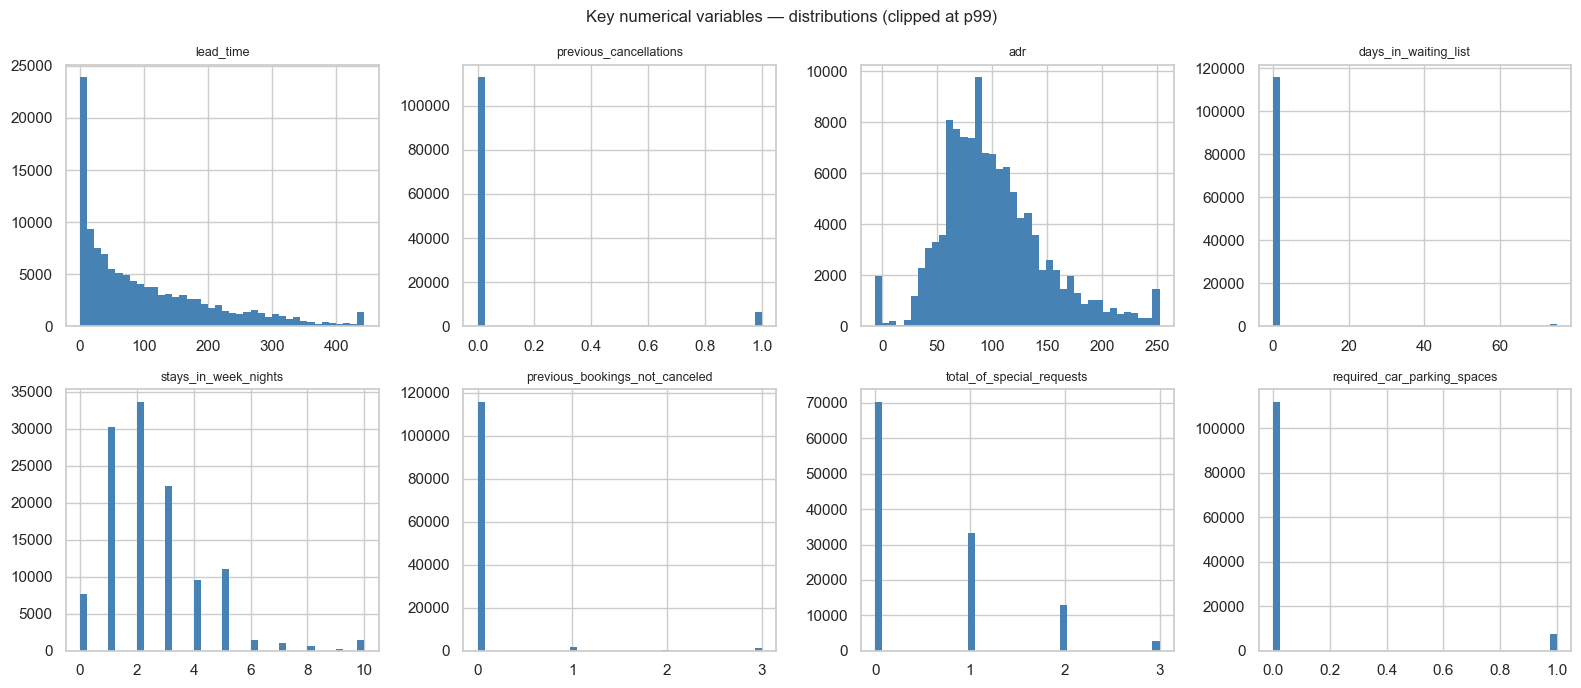

In [6]:
#Outlier report & distribution plots
#previous_cancellations and previous_bookings_not_canceled both show
#heavy right tails (p99 >> 0, max > 20).
#Strategy is log1p transformation consistent with lead_time, preserves ordinal ranking without arbitrary capping.

key_num = ['lead_time','stays_in_week_nights','stays_in_weekend_nights',  #key numerical columns to inspect
           'adults','children','babies','previous_cancellations',
           'previous_bookings_not_canceled','total_of_special_requests',
           'required_car_parking_spaces','adr']
stats = df[key_num].describe(percentiles=[.25,.75,.95,.99]).T  #compute percentiles including p95 and p99
stats['IQR'] = stats['75%']-stats['25%']  #interquartile range
stats['upper_fence'] = stats['75%'] + 1.5 * stats['IQR']  #Tukey upper fence, values above this are outliers
stats['outlier_%'] = [round((df[c] > stats.loc[c,'upper_fence']).mean()*100,2) for c in key_num]  #% of rows above fence per column
display(stats[['mean','50%','max','IQR','upper_fence','outlier_%']].round(2))  #show outlier summary table

skewed = ['lead_time','previous_cancellations','adr','days_in_waiting_list',  #columns with known heavy tails
          'stays_in_week_nights','previous_bookings_not_canceled',
          'total_of_special_requests','required_car_parking_spaces']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, skewed):  #loop over subplot axes and column names together
    ax.hist(df[col].clip(upper=df[col].quantile(0.99)), bins=40, color='steelblue', edgecolor='none')  #clip at p99 to avoid extreme outliers compressing the x-axis
    ax.set_title(col, fontsize=9)  #set subplot title to column name
plt.suptitle('Key numerical variables — distributions (clipped at p99)', fontsize=12)  #overall figure title
plt.tight_layout()  #prevent subplot overlap
plt.savefig('figures/eda_distributions.png', dpi=120, bbox_inches='tight')  #save figure
plt.show()


## 3. Feature Selection and Preprocessing Pipeline

**Segmentation index time:** immediately after the initial booking is created.
ADR is treated as **post-hoc only** (leakage if used to form clusters, it is not included in the feature matrix).

**Two representations are built:**
- **R0** (primary): StandardScaler on numerical features
- **R1** (robustness check): RobustScaler on numerical features — used in Section 5c sensitivity analysis


In [7]:
df2 = df.copy()  #work on a copy to preserve the original raw dataframe
no_guests = (df2['adults'] + df2['children'].fillna(0) + df2['babies']) == 0  #flag rows with zero guests (invalid bookings)
print(f'Rows with 0 guests removed: {no_guests.sum()}')
df2 = df2[~no_guests].reset_index(drop=True)  #drop zero-guest rows and reset integer index

df2['children']=df2['children'].fillna(0)  #fill 4 missing children values with 0 (no children)
df2['country']=df2['country'].fillna('Unknown')  #fill missing country with placeholder
df2['total_nights']= df2['stays_in_weekend_nights'] + df2['stays_in_week_nights']  #total length of stay
df2['party_size'] = df2['adults'] + df2['children'] + df2['babies']  #total guests per booking
df2['has_children'] = ((df2['children'] + df2['babies']) > 0).astype(int)  #binary: 1 if booking includes children or babies
df2['has_agent'] = (df2['agent'].notna() & (df2['agent'] != 0)).astype(int)  #binary: 1 if booking was made through a travel agent
df2['has_company'] =(df2['company'].notna() & (df2['company'] != 0)).astype(int)  #binary: 1 if booking is associated with a company
df2['has_parking'] = (df2['required_car_parking_spaces'] >= 1).astype(int)  # «binary: 1 if parking was requested
df2['meal_clean'] = df2['meal'].replace({'Undefined': 'SC'})  #recode 'Undefined' meal to 'SC' (no meal plan) for consistency
df2['special_req_capped']= df2['total_of_special_requests'].clip(upper=4)  #cap at 4 (p99) to reduce skew without log transform
df2['lead_time_log'] = np.log1p(df2['lead_time'])  #log1p(x) = log(1+x): compresses heavy right tail of lead_time

#previous_cancellations and previous_bookings_not_canceled:
#EDA shows both are heavily right-skewed (p99=1 and p99=3 respectively, max >20).
#Consistent log1p transformation — same rationale as lead_time.
#log1p compresses heavy tails while preserving ordinal structure (no arbitrary cap needed).
p99_cancel = df2['previous_cancellations'].quantile(0.99)  #confirm p99 value before transformation
p99_notcancel = df2['previous_bookings_not_canceled'].quantile(0.99)  #confirm p99 value before transformation
print(f'previous_cancellations  p99={p99_cancel:.1f} ')  #confirm p99 before transformation
print(f'previous_bookings_not_canceled p99={p99_notcancel:.1f} ')  #confirm p99 before transformation
df2['prev_cancel_log'] = np.log1p(df2['previous_cancellations'])  #log1p transform: handles zeros and heavy tail
df2['prev_not_cancel_log']= np.log1p(df2['previous_bookings_not_canceled'])  #same transform for consistency

top_n = 15  #keep top 15 countries by booking count; rest grouped as 'Other'
top_countries = df2['country'].value_counts().head(top_n).index.tolist()  #identify top-15 countries
df2['country_grouped'] = df2['country'].apply(lambda x: x if x in top_countries else 'Other')  #group rare countries
print(f'Clean dataset: {df2.shape[0]:,} rows x {df2.shape[1]} columns')  #confirm final shape after cleaning


Rows with 0 guests removed: 180
previous_cancellations  p99=1.0 
previous_bookings_not_canceled p99=3.0 
Clean dataset: 119,210 rows x 44 columns


In [8]:
NUMERICAL_FEATURES = ['lead_time_log', 'total_nights', 'party_size',  # 6 numerical features (log-transformed where needed)
                       'prev_cancel_log', 'prev_not_cancel_log', 'special_req_capped']
BINARY_FEATURES = ['has_children', 'has_agent', 'has_company', 'has_parking']  # 4 binary flags (0/1, passed through without scaling)
CATEGORICAL_FEATURES = ['hotel', 'meal_clean', 'market_segment', 'distribution_channel',  # 9 categorical features (OHE encoded)
                        'deposit_type', 'customer_type', 'reserved_room_type',
                        'arrival_date_month', 'country_grouped']
ALL_INPUT = NUMERICAL_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES  # full input feature list (19 raw → 73 after OHE)
print(f'Input: {len(NUMERICAL_FEATURES)} numerical + {len(BINARY_FEATURES)} binary + '  # report total column counts per block
      f'{len(CATEGORICAL_FEATURES)} categorical = {len(ALL_INPUT)} raw columns')  # continuation of print f-string

def build_preprocessor(scaler_type='standard'):  # factory: returns ColumnTransformer for R0 (standard) or R1 (robust)
    sc = StandardScaler() if scaler_type == 'standard' else RobustScaler()  # R0: StandardScaler; R1: RobustScaler
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', sc)])  # median imputation + scaling for numerical block
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),  # mode imputation for categoricals
                         ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])  # OHE: unseen categories zero vector
    return ColumnTransformer([  # apply each pipeline to its feature block
        ('num', num_pipe, NUMERICAL_FEATURES),  # numerical block
        ('bin', 'passthrough', BINARY_FEATURES),  # binary block: no transformation needed
        ('cat', cat_pipe, CATEGORICAL_FEATURES),  # categorical block
    ])  # close ColumnTransformer list

X_raw = df2[ALL_INPUT]  # extract input features from cleaned dataframe
prep_R0 = build_preprocessor('standard')  # build R0 preprocessor (StandardScaler)
X_R0 = prep_R0.fit_transform(X_raw)  # R0 — primary representation: fit and transform
prep_R1 = build_preprocessor('robust')  # build R1 preprocessor (RobustScaler)
X_R1 = prep_R1.fit_transform(X_raw)  # R1 — sensitivity check only

ohe_names = prep_R0.named_transformers_['cat']['ohe'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()  # get OHE column names after encoding
FEATURE_NAMES = NUMERICAL_FEATURES + BINARY_FEATURES + ohe_names  # full list of 73 feature names



Input: 6 numerical + 4 binary + 9 categorical = 19 raw columns


In [9]:
# Feature block distance contribution check
np.random.seed(GLOBAL_SEED)  # fix seed for reproducibility of subsample
s_idx = np.random.choice(len(X_R0), size=2000, replace=False)  # draw 2000 random row indices
X_samp = X_R0[s_idx]  # subsample for pairwise distance computation (full dataset too slow)
i1 = np.random.choice(len(X_samp), 500); i2 = np.random.choice(len(X_samp), 500)  # random pairs of rows
dsq = (X_samp[i1] - X_samp[i2])**2  # squared element-wise differences for each pair
n_num = len(NUMERICAL_FEATURES); n_bin = len(BINARY_FEATURES)  # block boundary indices
contrib = {  # dict mapping block name → mean squared distance contribution
    'Numerical':dsq[:, :n_num].sum(axis=1).mean(),  # mean squared distance from numerical block
    'Binary':dsq[:, n_num:n_num+n_bin].sum(axis=1).mean(),  # mean squared distance from binary block
    'Categorical (one-hot)': dsq[:, n_num+n_bin:].sum(axis=1).mean(),  # mean squared distance from OHE block
}
total = sum(contrib.values())  # total mean squared distance across all blocks
for k, v in contrib.items():  # print each block's % contribution to total pairwise distance
    print(f'  {k:30s}: {v:.3f}  ({v/total*100:.1f}%)')  # print contribution % for each block


  Numerical                     : 14.437  (59.6%)
  Binary                        : 0.652  (2.7%)
  Categorical (one-hot)         : 9.128  (37.7%)


## 4. Task 1 — K-Means Baseline + iK-Means

### 4a. K-Means k-sweep (k = 2..8)

In [10]:
results_km = []  # list to collect metrics for each k
for k in K_RANGE:  # iterate k=2..8
    t0 = time.time()  # start timer
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # k-means++ init: smarter starting centroids, n_init=10: run 10 times pick best
    lbl = km.fit_predict(X_R0)  # fit on full R0 dataset and return cluster labels
    rt = time.time() - t0  # elapsed time in seconds
    sil = silhouette_score(X_R0, lbl, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette on 5k sample (full too slow); higher=better
    ch = calinski_harabasz_score(X_R0, lbl)  # Calinski-Harabász: ratio of between/within cluster variance; higher=better
    db = davies_bouldin_score(X_R0, lbl)  # Davies-Bouldin: mean cluster similarity; lower=better
    results_km.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil,  # store all metrics for this k
                        'calinski_harabasz': ch, 'davies_bouldin': db, 'runtime_s': rt})

df_km = pd.DataFrame(results_km)  # convert list of dicts to dataframe
display(df_km.round(4))  # show sweep results table
BEST_K = int(df_km.loc[df_km.silhouette.idxmax(), 'k'])  # select k with highest Silhouette score
print(f'\nSelected k = {BEST_K} (highest Silhouette)')  # print selected k


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,runtime_s
0,2,1.177895e+06,0.0916,12238.4076,2.8761,0.5736
1,3,1.073093e+06,0.1024,12537.9185,2.2379,0.6984
2,4,9.848724e+05,0.1117,12666.5553,2.0401,0.7586
3,5,9.074123e+05,0.1254,12854.7264,1.8844,0.6715
4,6,8.488830e+05,0.1264,12636.5265,1.8076,0.6633
5,7,8.076342e+05,0.1333,12082.8667,1.7578,0.7273
6,8,7.775884e+05,0.1125,11414.8239,1.9284,0.8786



Selected k = 7 (highest Silhouette)


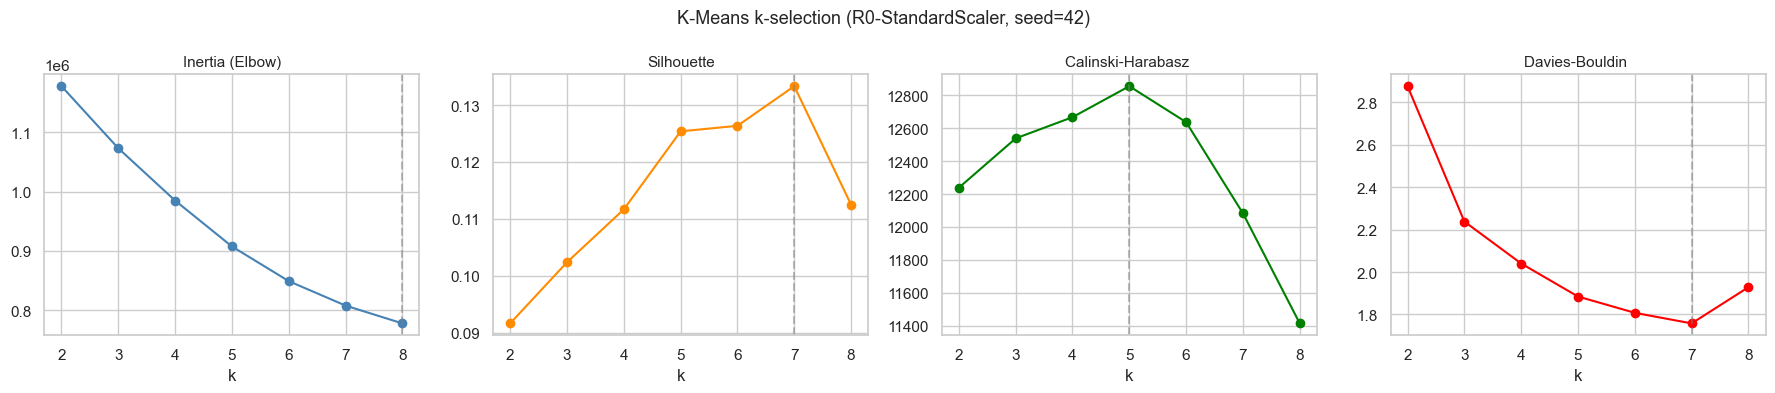

Cluster sizes: {0: 12953, 1: 20096, 2: 2021, 3: 5847, 4: 39997, 5: 10052, 6: 28244}


In [11]:
# k-selection plots
fig, axes = plt.subplots(1, 4, figsize=(18, 4))  # 1 row × 4 panels: one per metric
for ax, (col, title, color) in zip(axes, [  # loop over metric/title/color triples
    ('inertia','Inertia (Elbow)','steelblue'),  # inertia — elbow method
    ('silhouette','Silhouette','darkorange'),  # Silhouette — higher is better
    ('calinski_harabasz', 'Calinski-Harabasz ','green'),  # Calinski-Harabász — higher is better
    ('davies_bouldin','Davies-Bouldin ','red')]):  # Davies-Bouldin — lower is better
    ax.plot(df_km.k, df_km[col], 'o-', color=color)  # plot metric vs k
    ax.set_title(title, fontsize=11); ax.set_xlabel('k')  # set axis labels for each panel
    best = df_km.k[df_km[col].idxmax() if col != 'inertia' and col != 'davies_bouldin'  # for ↑ metrics: take max; for ↓ metrics: take min
                   else df_km[col].idxmin()]  # idxmin for ↓ metrics; mark best k with dashed line
    ax.axvline(best, ls='--', color='grey', alpha=0.5)  # vertical dashed line at selected k
plt.suptitle(f'K-Means k-selection (R0-StandardScaler, seed={GLOBAL_SEED})', fontsize=13)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/kmeans_k_selection.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

km_final = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # refit best model
labels_km = km_final.fit_predict(X_R0)  # final cluster labels for all 119,210 bookings
sizes_km = pd.Series(labels_km).value_counts().sort_index()  # count bookings per cluster
print(f'Cluster sizes: {sizes_km.to_dict()}')  # print size of each cluster



### 4b. iK-Means — Anomalous Cluster Extraction

iK-Means determines k automatically by extracting anomalous clusters iteratively.
The resulting `k_ikm` is used **consistently** throughout all tables, experiments.csv, and the report.
Note that k_ikm may differ from BEST_K — this is expected and reflects a different structural criterion.


In [12]:
#mwe try to improve some things of second milestone implementation

In [13]:
FloatArray = NDArray[np.float64]  # type alias for numpy float64 arrays

@dataclass(frozen=True)  # immutable dataclass: fields cannot be changed after creation
class APCluster:
    indices:      list        # row indices of the original dataset belonging to this cluster
    centroid_raw: FloatArray  # centroid in original feature space: c
    centroid_std: FloatArray  # standardised centroid: z = (c - µ) / r
    size:         int         # number of points in the cluster: |S|
    scatter_pct:  float       # % of total scatter removed: 100·|S|·‖z‖²/D

def compute_feature_statistics(X: FloatArray, use_unit_ranges: bool = False) -> tuple[FloatArray, FloatArray, float]:
    X = np.asarray(X, dtype=np.float64)  # cast to float64 for numerical stability
    mean = X.mean(axis=0)  # µ: global mean per feature (d-dimensional vector)
    if use_unit_ranges:
        scales = np.ones(X.shape[1], dtype=np.float64)  # unit scales: all features equally weighted
    else:
        ranges = X.max(axis=0) - X.min(axis=0)  # r: per-feature range (max - min)
        scales = np.where(ranges == 0, 1.0, ranges).astype(np.float64)  # replace zero ranges with 1 to avoid division by zero
    D = float(np.sum(((X - mean) / scales) ** 2))  # D: total normalised scatter = Σ‖(xi-µ)/r‖²
    return mean, scales, D  # return grand mean µ, scales r, total scatter D

def normalized_squared_distances(X: FloatArray, indices: list, scales: FloatArray, reference: FloatArray) -> FloatArray:
    Xs = np.asarray(X, dtype=np.float64)[indices]  # subset of rows indexed by indices
    diff = (Xs - reference) / scales  # normalised difference: (xi - ref) / r
    return np.sum(diff ** 2, axis=1)  # δr(xi, ref) = Σ((xi-ref)/r)² per row

def cluster_centroid(X: FloatArray, indices: list) -> FloatArray:
    return np.asarray(X, dtype=np.float64)[indices].mean(axis=0)  # component-wise mean of rows in indices

def separate_cluster(X: FloatArray, indices: list, scales: FloatArray, a: FloatArray, b: FloatArray) -> list:
    X = np.asarray(X, dtype=np.float64)
    da = normalized_squared_distances(X, indices, scales, a)  # δr(xi, a): distance to candidate centroid
    db = normalized_squared_distances(X, indices, scales, b)  # δr(xi, b): distance to reference point µ
    return [idx for idx, d_a, d_b in zip(indices, da, db) if d_a < d_b]  # strict <: ties stay with reference µ

def extract_anomalous_cluster(X: FloatArray, indices: list, scales: FloatArray, mean: FloatArray,
                               initial_centroid: FloatArray, seed_index: int,
                               tol: float = 1e-12, max_iter: int = 10_000) -> tuple[list, FloatArray]:
    X = np.asarray(X, dtype=np.float64)
    mean = np.asarray(mean, dtype=np.float64)
    c = np.asarray(initial_centroid, dtype=np.float64).copy()  # starting centroid = farthest point from µ
    S = separate_cluster(X, indices, scales, c, mean)  # initial assignment: points closer to c than to µ
    if len(S) == 0:
        return [], c  # empty cluster: extraction failed
    for _ in range(max_iter):  # iterate until convergence
        c_new = cluster_centroid(X, S)  # update centroid as mean of current cluster
        S_new = separate_cluster(X, indices, scales, c_new, mean)  # reassign points with updated centroid
        if len(S_new) == 0:
            break  # empty reassignment: stop
        if np.max(np.abs(c_new - c)) < tol and set(S_new) == set(S):  # convergence: centroid stable AND membership unchanged
            c = c_new; S = S_new; break
        c = c_new; S = S_new  # update centroid and membership for next iteration
    return S, c  # return final cluster indices and centroid

def ikmeans_initialize(X: FloatArray, min_cluster_size: int, tol: float = 1e-12,
                        max_iter: int = 10_000, use_unit_ranges: bool = False) -> tuple[list, FloatArray]:
    X = np.asarray(X, dtype=np.float64)
    n, d = X.shape
    mean_global, scales, D_total = compute_feature_statistics(X, use_unit_ranges)  # global statistics computed once
    residual = list(range(n))  # all row indices start in the residual set
    ap_clusters = []  # list to collect extracted clusters
    iteration = 0
    while True:
        if len(residual) < min_cluster_size:
            break  # stop if residual too small to form a valid cluster
        mu = cluster_centroid(X, residual)  # mean of remaining points (reference point for this iteration)
        dists_from_mu = normalized_squared_distances(X, residual, scales, mu)  # distance of each residual point from µ
        seed_pos = int(np.argmax(dists_from_mu))  # position of farthest point within residual list
        seed_idx = residual[seed_pos]  # actual row index in X of the seed
        c_init = X[seed_idx].copy()  # seed centroid: farthest point from µ
        S, c_final = extract_anomalous_cluster(X, residual, scales, mu, c_init, seed_idx, tol, max_iter)  # extract one anomalous cluster
        if len(S) < min_cluster_size:
            break  # extracted cluster too small: stop
        z = (c_final - mean_global) / scales  # standardised centroid: z = (c - µ) / r
        scatter_pct = float(np.sum(((X[S] - c_final) / scales)**2)) / D_total * 100
        ap_clusters.append(APCluster(indices=S, centroid_raw=c_final, centroid_std=z, size=len(S), scatter_pct=scatter_pct))
        S_set = set(S); residual = [i for i in residual if i not in S_set]  # remove extracted cluster from residual
        iteration += 1
        print(f'iK-Means iter {iteration}: extracted cluster size={len(S)}, scatter_pct={scatter_pct:.2f}%, residual={len(residual)}')
        if len(residual) < min_cluster_size:
            break  # residual exhausted: stop
    if len(ap_clusters) == 0:
        init_centroids = mean_global.reshape(1, -1)  # fallback if no clusters extracted
    else:
        init_centroids = np.array([c.centroid_std for c in ap_clusters], dtype=np.float64)  # spec step 25: use centroid_std
    print(f'iK-Means: {len(ap_clusters)} anomalous clusters found → init_centroids shape = {init_centroids.shape}')
    return ap_clusters, init_centroids  # return all clusters and standardised seed centroids



iK-Means iter 1: extracted cluster size=3531, scatter_pct=17.83%, residual=16469
iK-Means iter 2: extracted cluster size=3320, scatter_pct=11.77%, residual=13149
iK-Means iter 3: extracted cluster size=2046, scatter_pct=4.13%, residual=11103
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
iK-Means: k = 3 anomalous clusters extracted | runtime = 0.4s
iK-Means (k=3) → Sil=0.1021  CH=12214  DB=2.4358


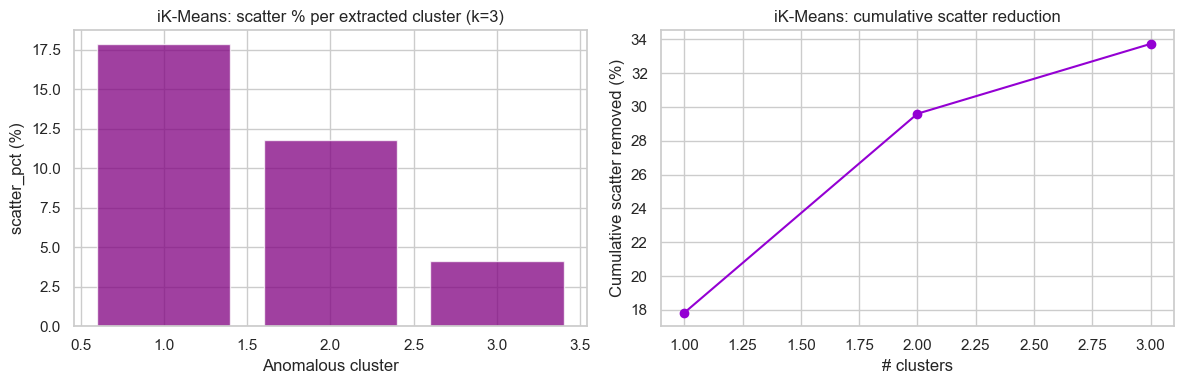

In [14]:
SUBSAMPLE_IKM= 20_000  # subsample size for iK-Means (full dataset too slow for iterative extraction)
MIN_CLUSTER_SIZE = 10  # minimum points for a valid anomalous cluster

np.random.seed(GLOBAL_SEED)  # reproducible subsample
ikm_idx = np.random.choice(len(X_R0), size=SUBSAMPLE_IKM, replace=False)  # random indices without replacement
X_ikm = X_R0[ikm_idx].astype(np.float64)  # extract subsample, cast to float64 for iK-Means

t0 = time.time()  # start timer
ap_clusters, init_centroids = ikmeans_initialize(X_ikm, min_cluster_size=MIN_CLUSTER_SIZE)  # run iK-Means extraction
ikm_rt = time.time() - t0  # total runtime
k_ikm = len(ap_clusters)  # number of anomalous clusters found automatically

if k_ikm < 2:  # fallback: at least 2 clusters required for meaningful clustering
    print(f'WARNING: iK-Means extracted {k_ikm} cluster(s) — falling back to k=2')  # warn if fewer than 2 clusters found
    k_ikm = 2  # fallback: force k=2 so downstream code always has at least 2 clusters
    km_ikm = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # standard K-Means fallback
else:  # normal case: iK-Means found ≥2 clusters — use warm-start K-Means
    km_ikm = KMeans(n_clusters=k_ikm, init=init_centroids, n_init=1,  # warm-start K-Means from iK-Means centroids
                    max_iter=300, random_state=GLOBAL_SEED)  # n_init=1 because centroids are already good

# k_ikm is the authoritative value for iK-Means throughout this notebook.
# It is determined solely by the anomalous-cluster extraction algorithm (seed=42).
print(f'iK-Means: k = {k_ikm} anomalous clusters extracted | runtime = {ikm_rt:.1f}s')  # report final k and runtime

km_ikm.fit(X_ikm)  # fit K-Means on the subsample using iK-Means centroids
labels_ikm = pairwise_distances_argmin(X_R0, km_ikm.cluster_centers_)  # extend labels to full dataset: nearest centroid rule

sil_ikm = silhouette_score(X_R0, labels_ikm, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette on full labels
ch_ikm = calinski_harabasz_score(X_R0, labels_ikm)  # Calinski-Harabász on full labels
db_ikm = davies_bouldin_score(X_R0, labels_ikm)  # Davies-Bouldin on full labels
print(f'iK-Means (k={k_ikm}) → Sil={sil_ikm:.4f}  CH={ch_ikm:.0f}  DB={db_ikm:.4f}')  # print final quality metrics

pcts = [cl.scatter_pct for cl in ap_clusters]  # extract scatter % per extracted cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # two-panel figure: scatter % and cumulative scatter
axes[0].bar(range(1, len(pcts)+1), pcts, color='purple', alpha=0.75)  # bar chart: scatter removed per cluster
axes[0].set_xlabel('Anomalous cluster'); axes[0].set_ylabel('scatter_pct (%)')  # label axes for scatter % panel
axes[0].set_title(f'iK-Means: scatter % per extracted cluster (k={k_ikm})')  # title for scatter % panel
axes[1].plot(range(1, len(pcts)+1), np.cumsum(pcts), 'o-', color='darkviolet')  # line chart: cumulative scatter removed
axes[1].set_xlabel('# clusters'); axes[1].set_ylabel('Cumulative scatter removed (%)')
axes[1].set_title('iK-Means: cumulative scatter reduction')  # title for cumulative scatter panel
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/ikmeans_scatter.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline


## 5. Task 3 — Evaluation, Stability & Sensitivity

### 5a. K-Means vs iK-Means — Direct Comparison

Both methods use R0 (StandardScaler). K-Means uses k selected by Silhouette; iK-Means determines k automatically.
These are two distinct algorithmic families: K-Means minimises inertia iteratively; iK-Means identifies anomalous clusters sequentially.


In [15]:
sil_km_val = silhouette_score(X_R0, labels_km, sample_size=5000, random_state=GLOBAL_SEED)  # recompute Silhouette on final K-Means labels
ch_km_val = calinski_harabasz_score(X_R0, labels_km)  # Calinski-Harabász on final labels
db_km_val = davies_bouldin_score(X_R0, labels_km)  # Davies-Bouldin on final labels

compare_t1 = pd.DataFrame([  # build side-by-side comparison table
    {'method': f'K-Means (k={BEST_K})','k': BEST_K,'silhouette': sil_km_val,  # K-Means row: method name, k, quality metrics
     'calinski_harabasz': ch_km_val,'davies_bouldin': db_km_val},
    {'method': f'iK-Means (k={k_ikm})', 'k': k_ikm,'silhouette': sil_ikm,  # iK-Means row: method name, k, quality metrics
     'calinski_harabasz': ch_ikm,'davies_bouldin': db_ikm},
])  # close DataFrame constructor list
display(compare_t1.round(4))  # show comparison table
compare_t1.to_csv('tables/task1_comparison.csv', index=False)  # save to CSV for report


,method,k,silhouette,calinski_harabasz,davies_bouldin
0,K-Means (k=7),7,0.1333,12082.8667,1.7578
1,iK-Means (k=3),3,0.1021,12214.2172,2.4358


### 5b. Stability — 5 seeds (K-Means & iK-Means)

In [16]:
# K-Means stability across 5 seeds
km_stab_rows, km_stab_labels = [], []  # collect metrics and labels per seed
for seed in SEEDS:  # iterate over 11 seeds
    km_s = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=seed)  # refit with this seed
    lbl = km_s.fit_predict(X_R0)  # get labels
    sil = silhouette_score(X_R0, lbl, sample_size=5000, random_state=seed)  # Silhouette for this seed
    ch = calinski_harabasz_score(X_R0, lbl)  # CH for this seed
    db = davies_bouldin_score(X_R0, lbl)  # DB for this seed
    km_stab_rows.append({'seed': seed, 'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db})  # store metrics
    km_stab_labels.append(lbl)  # store labels for ARI computation

df_km_stab = pd.DataFrame(km_stab_rows)  # assemble stability table
display(df_km_stab.round(4))  # show per-seed metrics
print(df_km_stab[['silhouette','calinski_harabasz','davies_bouldin']].agg(['mean','std']).round(4))  # mean and std across seeds
ari_km = [adjusted_rand_score(km_stab_labels[i], km_stab_labels[i+1]) for i in range(len(SEEDS)-1)]  # ARI between consecutive seed pairs
print(f'K-Means mean ARI (consecutive seeds) = {np.mean(ari_km):.4f}')  # mean ARI: close to 1 = stable partition


,seed,silhouette,calinski_harabasz,davies_bouldin
0,42,0.1333,12082.8667,1.7578
1,7,0.1404,12082.8669,1.7578
2,13,0.1385,12082.8728,1.7581
3,99,0.1362,12082.8598,1.7582
4,2025,0.1346,12082.8598,1.7582
5,2024,0.1350,12082.8725,1.7581
6,2004,0.1159,11868.2998,1.9514
7,2005,0.1163,11868.2944,1.9517
8,2020,0.1393,12082.8730,1.7581
9,100,0.1164,11868.2917,1.9517


      silhouette  calinski_harabasz  davies_bouldin
mean      0.1311         12024.3480          1.8108
std       0.0098           100.2267          0.0904
K-Means mean ARI (consecutive seeds) = 0.8229


In [17]:
# iK-Means stability — k varies across seeds (expected behaviour)
# iK-Means is sensitive to the random subsample: different seeds may extract different numbers
# of anomalous clusters. This instability is a known limitation of the method and is
# reported honestly (not masked by fixing k externally).
ikm_stab_rows, ikm_labels_all = [], []  # collect results per seed
for seed in SEEDS:  # iterate over all seeds
    np.random.seed(seed)  # fix seed for this subsample
    idx_s = np.random.choice(len(X_R0), size=SUBSAMPLE_IKM, replace=False)  # different subsample per seed
    X_s = X_R0[idx_s].astype(np.float64)  # extract and cast subsample
    ap_s, init_s = ikmeans_initialize(X_s, min_cluster_size=MIN_CLUSTER_SIZE)  # run iK-Means on this seed's subsample
    k_s = len(ap_s) if len(ap_s) >= 2 else 2  # k is determined automatically; fallback to 2 if fewer than 2 found
    km_s2 = KMeans(n_clusters=k_s, init=init_s if len(ap_s)>=2 else 'k-means++',  # warm-start if clusters found, else default init
                   n_init=1 if len(ap_s)>=2 else 10, max_iter=300, random_state=seed)  # n_init=1 with warm start
    km_s2.fit(X_s)  # fit on subsample
    lbl_s = pairwise_distances_argmin(X_R0, km_s2.cluster_centers_)  # extend to full dataset
    sil_s = silhouette_score(X_R0, lbl_s, sample_size=5000, random_state=seed)  # Silhouette
    ch_s = calinski_harabasz_score(X_R0, lbl_s)  # CH
    db_s = davies_bouldin_score(X_R0, lbl_s)  # DB
    ikm_stab_rows.append({'seed': seed, 'k': k_s, 'silhouette': sil_s,  # store seed result: k found, Silhouette, CH, DB
                           'calinski_harabasz': ch_s, 'davies_bouldin': db_s})  # store result for this seed
    ikm_labels_all.append(lbl_s)  # store labels for ARI
    print(f'seed={seed}  k={k_s}  Sil={sil_s:.4f}')  # report k found by each seed

df_ikm_stab = pd.DataFrame(ikm_stab_rows)  # assemble stability table
display(df_ikm_stab)  # render table in notebook output
ari_ikm = [adjusted_rand_score(ikm_labels_all[i], ikm_labels_all[i+1]) for i in range(len(SEEDS)-1)]  # ARI between consecutive seed pairs
print(f'\niK-Means mean ARI (consecutive seeds) = {np.mean(ari_ikm):.4f}')  # print stability summary: mean ARI across consecutive seed pairs
# reference solution is seed=42  w k=3


iK-Means iter 1: extracted cluster size=3531, scatter_pct=17.83%, residual=16469
iK-Means iter 2: extracted cluster size=3320, scatter_pct=11.77%, residual=13149
iK-Means iter 3: extracted cluster size=2046, scatter_pct=4.13%, residual=11103
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
seed=42  k=3  Sil=0.1021
iK-Means iter 1: extracted cluster size=3546, scatter_pct=17.95%, residual=16454
iK-Means iter 2: extracted cluster size=3314, scatter_pct=11.67%, residual=13140
iK-Means iter 3: extracted cluster size=2004, scatter_pct=4.02%, residual=11136
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
seed=7  k=3  Sil=0.1095
iK-Means iter 1: extracted cluster size=3540, scatter_pct=17.80%, residual=16460
iK-Means iter 2: extracted cluster size=3354, scatter_pct=11.99%, residual=13106
iK-Means iter 3: extracted cluster size=2003, scatter_pct=4.06%, residual=11103
iK-Means iter 4: extracted cluster size=1589, scatter_pct=6.31%, residual=9514
iK-Mea

,seed,k,silhouette,calinski_harabasz,davies_bouldin
0,42,3,0.102066,12214.217239,2.435840
1,7,3,0.109521,12212.003534,2.439859
2,13,4,0.095721,10718.051799,2.466296
3,99,7,0.110763,10786.987705,2.038720
4,2025,8,0.105264,10414.787022,2.006728
5,2024,7,0.101986,10663.385600,2.061663
6,2004,3,0.102079,12212.732323,2.433250
7,2005,5,0.089986,10273.072825,2.277008
8,2020,10,0.089300,8742.072576,2.192334
9,100,2,0.150230,11966.912948,2.543425



iK-Means mean ARI (consecutive seeds) = 0.5733


In [18]:
# ARI: K-Means vs iK-Means — how similar are the two baseline partitions?
ari_km_ikm = adjusted_rand_score(labels_km, labels_ikm)
print(f'ARI(K-Means k={BEST_K} vs iK-Means k={k_ikm}) = {ari_km_ikm:.4f}')
if ari_km_ikm > 0.8:
    print('High overlap — iK-Means confirms K-Means partition.')
elif ari_km_ikm > 0.5:
    print('Moderate overlap — similar broad structure, different granularity.')
else:
    print('Low overlap — iK-Means reveals a substantially different partition.')

ARI(K-Means k=7 vs iK-Means k=3) = 0.5459
Moderate overlap — similar broad structure, different granularity.


### 5c. Sensitivity Analysis — Controlled Preprocessing Variants

Two controlled variants are tested:
1. **Scaler:** StandardScaler (R0) vs RobustScaler (R1)
2. **Feature inclusion:** with vs without `hotel` variable

**Interpretation protocol:**
- ARI > 0.8 → robust to the variant
- ARI 0.5–0.8 → moderately sensitive — report as limitation
- ARI < 0.5 → substantially sensitive — treat as key limitation, not a strength


In [19]:
# Variant 1: Scaler sensitivity — R0 vs R1
sens_rows, lbl_dict = [], {}  # collect sensitivity results and labels per representation
for rep_id, X_rep, scaler_name in [('R0-standard', X_R0, 'StandardScaler'),  # R0: standard scaler (primary)
                                     ('R1-robust',   X_R1, 'RobustScaler')]:  # R1: robust scaler
    km_s = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # same k, same seed, different input matrix
    lbl = km_s.fit_predict(X_rep)  # fit and get labels
    sil = silhouette_score(X_rep, lbl, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette in each representation's own space
    ch = calinski_harabasz_score(X_rep, lbl)  # CH
    db = davies_bouldin_score(X_rep, lbl)  # DB
    sens_rows.append({'representation_id': rep_id, 'scaler': scaler_name,  # store scaler sensitivity result for this representation
                      'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db})  # store result
    lbl_dict[rep_id] = lbl  # store labels for ARI comparison

df_sens = pd.DataFrame(sens_rows)  # assemble sensitivity table
display(df_sens.round(4))  # render table in notebook output
ari_scale = adjusted_rand_score(lbl_dict['R0-standard'], lbl_dict['R1-robust'])  # ARI between R0 and R1 partitions
print(f'ARI(R0 vs R1) = {ari_scale:.4f}')  # key result: how much does the scaler change the partition?
#ARI < 0.5  partition is substantially sensitive to scaler choice.
#Conclusions from R0 clusters may not transfer to R1. R0 is adopted as primary.
#This is a key limitation to acknowledge in the report.

,representation_id,scaler,silhouette,calinski_harabasz,davies_bouldin
0,R0-standard,StandardScaler,0.1333,12082.8667,1.7578
1,R1-robust,RobustScaler,0.1103,10577.1397,2.1589


ARI(R0 vs R1) = 0.2835


R0 (StandardScaler) cluster profiles — mean values:


,lead_time,total_nights,party_size,total_of_special_requests,previous_cancellations,is_canceled
cluster_km,,,,,,
0,139.47,8.45,1.98,0.51,0.00,0.33
1,5.71,1.87,1.61,0.31,0.00,0.13
2,14.58,1.71,1.21,0.74,0.59,0.06
3,213.64,2.73,1.84,0.12,1.56,0.99
4,147.95,2.83,1.80,0.08,0.00,0.51
5,88.25,3.59,3.45,0.59,0.00,0.41
6,85.20,3.28,2.01,1.55,0.00,0.24



R1 (RobustScaler) cluster profiles — mean values:


,lead_time,total_nights,party_size,total_of_special_requests,previous_cancellations,is_canceled
cluster_r1,,,,,,
0,8.84,1.59,1.58,0.34,0.07,0.12
1,217.14,2.60,1.82,0.00,0.43,0.99
2,146.08,14.78,1.98,0.65,0.02,0.36
3,146.42,2.64,1.72,0.20,0.08,0.26
4,83.31,3.10,2.24,2.23,0.02,0.21
5,129.96,6.86,2.18,0.61,0.06,0.34
6,77.70,2.91,2.16,0.49,0.01,0.37



Hotel type under R1:


hotel,City Hotel,Resort Hotel
cluster_r1,,
0,45.0,55.0
1,91.0,9.0
2,20.2,79.8
3,78.3,21.7
4,71.5,28.5
5,23.5,76.5
6,81.8,18.2



Market segment under R1:


market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
cluster_r1,,,,,,,,
0,1.1,3.5,23.6,39.9,2.9,8.1,21.0,0.0
1,0.0,0.0,0.9,0.1,63.1,35.8,0.1,0.0
2,1.1,0.1,2.9,11.5,7.4,39.5,37.4,0.0
3,0.0,0.1,3.8,1.9,47.3,40.7,6.1,0.0
4,0.0,0.6,0.3,8.4,0.4,3.0,87.3,0.0
5,0.0,0.1,1.0,13.5,7.1,28.1,50.2,0.0
6,0.0,0.0,0.0,4.3,0.1,11.0,84.5,0.0



Deposit type under R1:


deposit_type,No Deposit,Non Refund,Refundable
cluster_r1,,,
0,98.5,1.4,0.1
1,2.4,97.6,0.0
2,97.1,2.8,0.2
3,98.3,1.1,0.6
4,100.0,0.0,0.0
5,98.3,1.6,0.1
6,100.0,0.0,0.0


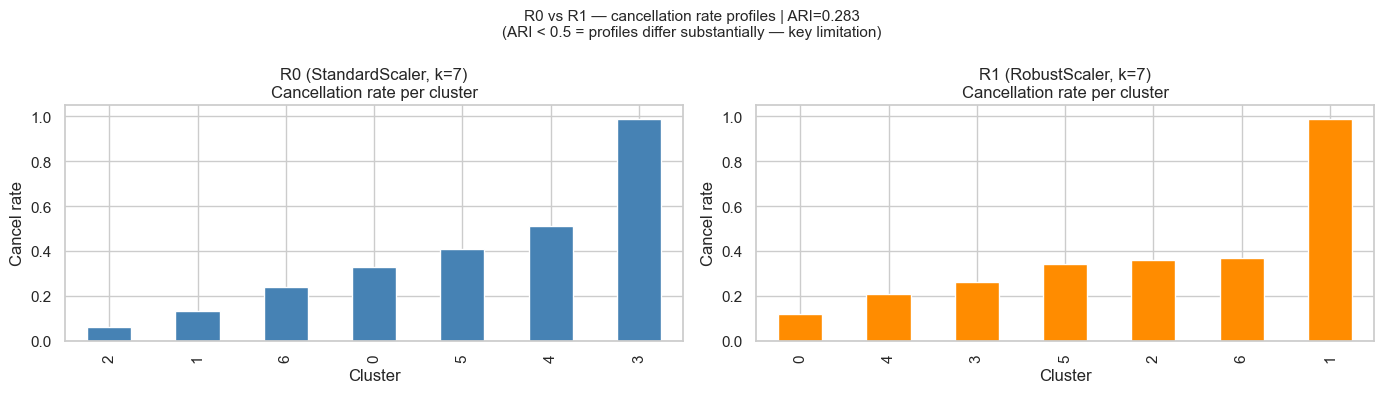

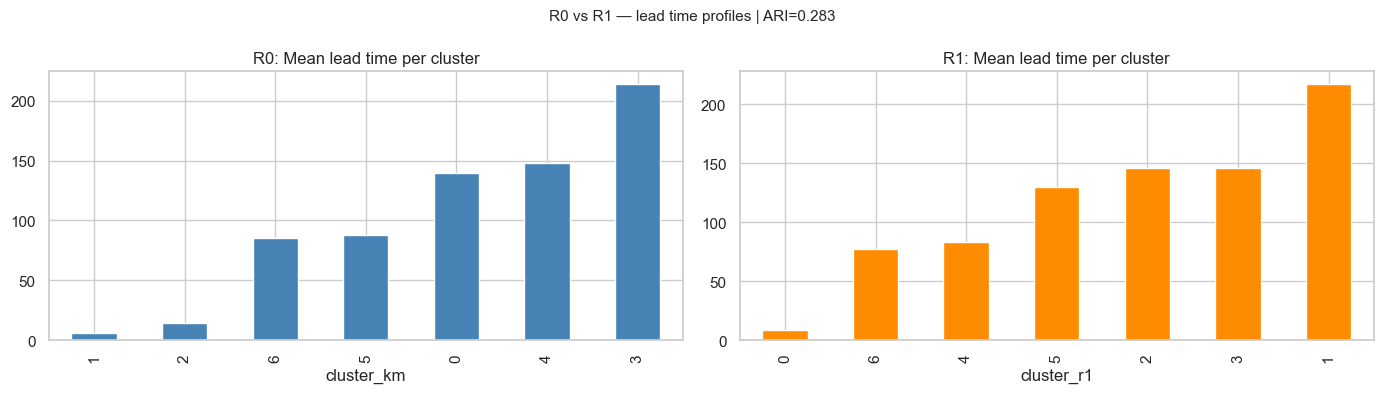

In [20]:
# R0 vs R1 — Full cluster profile comparison
# The guidance asks whether quality, stability, and booking-profile interpretation change.
df_prof = df2.copy()  # working copy of cleaned data for profiling
df_prof['cluster_km'] = labels_km  # attach R0 K-Means cluster labels
df_prof['cluster_r1'] = lbl_dict['R1-robust']  # attach R1 K-Means cluster labels

NUM_COLS = ['lead_time','total_nights','party_size',  # numerical columns to profile (pre-clustering features)
            'total_of_special_requests','previous_cancellations']

prof_r0 = df_prof.groupby('cluster_km')[NUM_COLS + ['is_canceled']].mean().round(2)  # mean profile per R0 cluster (is_canceled is post-hoc)
prof_r1 = df_prof.groupby('cluster_r1')[NUM_COLS + ['is_canceled']].mean().round(2)  # mean profile per R1 cluster

print('R0 (StandardScaler) cluster profiles — mean values:')  # section header for R0 profile table
display(prof_r0)  # show R0 profiles
print()  # blank line separator in output
print('R1 (RobustScaler) cluster profiles — mean values:')  # section header for R1 profile table
display(prof_r1)  # show R1 profiles

# Categorical profiles under R1
print('\nHotel type under R1:')  # section header: hotel type cross-tab under R1
display((pd.crosstab(df_prof['cluster_r1'], df_prof['hotel'], normalize='index')*100).round(1))  # % hotel type per R1 cluster
print('\nMarket segment under R1:')  # section header: market segment cross-tab under R1
display((pd.crosstab(df_prof['cluster_r1'], df_prof['market_segment'], normalize='index')*100).round(1))  # % market segment per R1 cluster
print('\nDeposit type under R1:')  # section header: deposit type cross-tab under R1
display((pd.crosstab(df_prof['cluster_r1'], df_prof['deposit_type'], normalize='index')*100).round(1))  # % deposit type per R1 cluster

# Side-by-side cancellation rate
fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # two-panel figure: R0 vs R1 cancellation rates
prof_r0['is_canceled'].sort_values().plot(kind='bar', ax=axes[0], color='steelblue',  # R0 cancellation rate bar chart
    title=f'R0 (StandardScaler, k={BEST_K})\nCancellation rate per cluster')  # R0 bar chart title with k and scaler
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Cancel rate'); axes[0].set_xlabel('Cluster')  # set y-axis limits and labels for R0 panel
prof_r1['is_canceled'].sort_values().plot(kind='bar', ax=axes[1], color='darkorange',  # R1 cancellation rate bar chart
    title=f'R1 (RobustScaler, k={BEST_K})\nCancellation rate per cluster')  # R1 bar chart title with k and scaler
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('Cancel rate'); axes[1].set_xlabel('Cluster')  # set y-axis limits and labels for R1 panel
plt.suptitle(f'R0 vs R1 — cancellation rate profiles | ARI={ari_scale:.3f}\n'  # overall figure title
             f'(ARI < 0.5 = profiles differ substantially — key limitation)', fontsize=11)  # subtitle noting ARI limitation threshold
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/r0_vs_r1_profiles.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

# Lead time comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # two-panel figure: R0 vs R1 cancellation rates
prof_r0['lead_time'].sort_values().plot(kind='bar', ax=axes[0], color='steelblue',  # R0 lead time bar chart
    title='R0: Mean lead time per cluster')  # lead time comparison: do the clusters capture the same booking horizons?
prof_r1['lead_time'].sort_values().plot(kind='bar', ax=axes[1], color='darkorange',  # R1 lead time bar chart
    title='R1: Mean lead time per cluster')  # title for R1 lead time bar chart
plt.suptitle(f'R0 vs R1 — lead time profiles | ARI={ari_scale:.3f}', fontsize=11)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/r0_vs_r1_leadtime.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

prof_r0.to_csv('tables/profile_r0_standard.csv')  # save R0 profile
prof_r1.to_csv('tables/profile_r1_robust.csv')  # save R1 profile
#this ARI means the two scalers produce substantially different partitions. Under R1, cluster meanings shift — e.g., cancellation rates
#and segment compositions differ. R0 is the primary representation; R1 is a
#robustness check that exposes sensitivity to outlier handling as a limitation


In [21]:
# Variant 2: Feature sensitivity — with vs without hotel
CATEG_NO_HOTEL = [c for c in CATEGORICAL_FEATURES if c != 'hotel']  # remove hotel from categorical features list
prep_nh = ColumnTransformer([  # preprocessor without hotel variable
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),('sc', StandardScaler())]), NUMERICAL_FEATURES),  # same numerical pipeline
    ('bin', 'passthrough', BINARY_FEATURES),  # same binary passthrough
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),  # categorical block: mode impute + OHE, without hotel variable
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEG_NO_HOTEL),  # OHE without hotel
])  # close ColumnTransformer list
X_nohotel = prep_nh.fit_transform(df2[NUMERICAL_FEATURES + BINARY_FEATURES + CATEG_NO_HOTEL])  # transformed matrix without hotel
km_nh     = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # same K-Means setup
lbl_nh    = km_nh.fit_predict(X_nohotel)  # cluster without hotel variable
sil_nh    = silhouette_score(X_nohotel, lbl_nh, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette without hotel
ari_hotel = adjusted_rand_score(labels_km, lbl_nh)  # ARI: how much does removing hotel change the partition?
print(f'With hotel   : Sil={sil_km_val:.4f}')  # reference Silhouette (with hotel)
print(f'Without hotel: Sil={sil_nh:.4f}')  # Silhouette without hotel
print(f'ARI(with vs without hotel) = {ari_hotel:.4f}')  # key result
if ari_hotel > 0.8:  # high ARI: removing hotel barely changes partition → hotel not dominant
    print('Partition is robust to removal of hotel variable.')  # hotel does not dominate structure
else:  # low ARI: removing hotel substantially changes partition → hotel structures clusters
    print('Partition changes substantially without hotel — hotel is a structuring variable.')  # hotel drives cluster separation


With hotel   : Sil=0.1333
Without hotel: Sil=0.1374
ARI(with vs without hotel) = 0.9113
Partition is robust to removal of hotel variable.


## 6. Task 2 — Ward Hierarchical Clustering (Distinct Family)

Ward linkage is **fundamentally different** from K-Means and iK-Means:

| Aspect | K-Means / iK-Means | Ward Hierarchical |
|---|---|---|
| Approach | Iterative partition | Agglomerative bottom-up |
| Objective | Minimise inertia (Euclidean) | Minimise within-cluster variance at each merge |
| k selection | External (Silhouette) | Dendrogram cut + Silhouette sweep |
| Deterministic | No (seed-dependent) | **Yes** |
| Output | Flat partition | Hierarchy of nested partitions |

**Note on k selection:** the dendrogram acceleration heuristic provides an initial suggestion;
the Silhouette sweep over k=2..8 is the primary criterion for consistency with other methods.
Both results are reported — if they disagree, both are discussed.

**Computational note:** O(n² log n). Fixed subsample of 10,000 rows (seed=42);
labels extended to full dataset via nearest centroid.


Building dendrogram on 10,000 rows...
Dendrogram acceleration heuristic suggests k ≈ 6


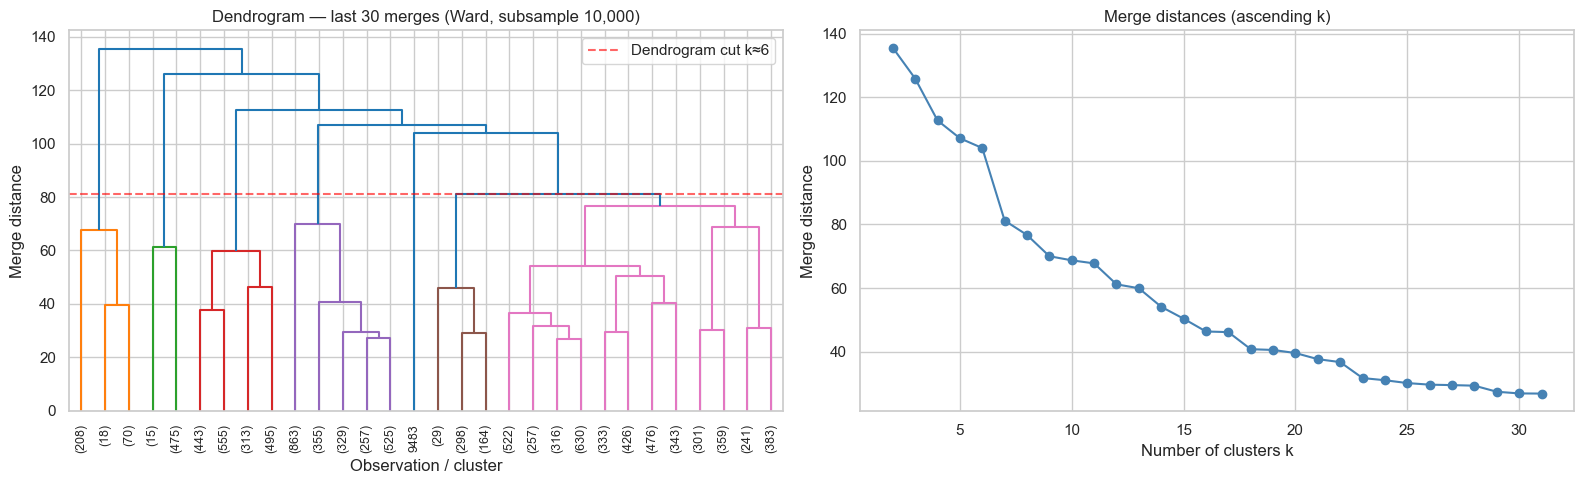

In [22]:
# Ward dendrogram
SUBSAMPLE_HIER = 10000  # subsample size: full linkage matrix is O(n²) memory — 10k is feasible
np.random.seed(GLOBAL_SEED)  # reproducible subsample
hier_idx = np.random.choice(len(X_R0), size=SUBSAMPLE_HIER, replace=False)  # random subsample indices
X_hier = X_R0[hier_idx]  # Ward subsample

print(f'Building dendrogram on {SUBSAMPLE_HIER:,} rows...')  # progress message before slow linkage computation
Z = sch.linkage(X_hier, method='ward', metric='euclidean')  # Ward linkage matrix: each row = [cluster_a, cluster_b, distance, size]

last30 = Z[-30:, 2]  # merge distances of the last 30 merges (largest distances, near root)
acceleration = np.diff(last30, 2)  # second derivative of merge distances: detects sharp jumps
k_dend = acceleration[::-1].argmax() + 2  # position of largest jump + 2 = suggested k (reversed because we count from top)
print(f'Dendrogram acceleration heuristic suggests k ≈ {k_dend}')  # data-driven k estimate from dendrogram

fig, axes = plt.subplots(1, 2, figsize=(16, 5))  # two-panel: dendrogram + merge distance curve
import scipy.cluster.hierarchy as sch  # local import in case not imported at top level
sch.dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=30,  # show last 30 merges (truncated for readability)
               leaf_rotation=90, leaf_font_size=9,  # rotate leaf labels for readability
               color_threshold=Z[-k_dend, 2])  # colour threshold at the suggested cut point
axes[0].set_title(f'Dendrogram — last 30 merges (Ward, subsample {SUBSAMPLE_HIER:,})')  # set dendrogram panel title
axes[0].set_xlabel('Observation / cluster'); axes[0].set_ylabel('Merge distance')  # label axes for dendrogram panel
axes[0].axhline(Z[-k_dend, 2], ls='--', color='red', alpha=0.6, label=f'Dendrogram cut k≈{k_dend}')  # horizontal cut line
axes[0].legend()  # show cut-line legend
axes[1].plot(range(2, 32), Z[-30:, 2][::-1], 'o-', color='steelblue')  # merge distances vs k (ascending)
axes[1].set_title('Merge distances (ascending k)')  # title for merge distance curve panel
axes[1].set_xlabel('Number of clusters k'); axes[1].set_ylabel('Merge distance')  # large jump = natural boundary between k values
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/ward_dendrogram.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline


In [23]:
# Ward k-sweep — Silhouette is the primary selection criterion
results_ward = []  # collect metrics per k
for k in K_RANGE:  # sweep k=2..8
    t0 = time.time()  # start timer
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')  # Ward hierarchical model
    lbl_sub = ward.fit_predict(X_hier)  # fit on subsample (agglomerative cannot scale to full dataset)
    rt = time.time() - t0  # elapsed time in seconds
    centroids_w = np.array([X_hier[lbl_sub == c].mean(axis=0) for c in range(k)])  # compute centroid of each Ward cluster
    lbl_full = pairwise_distances_argmin(X_R0, centroids_w)  # assign full dataset to nearest Ward centroid
    sil = silhouette_score(X_R0, lbl_full, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette on full-dataset labels
    ch = calinski_harabasz_score(X_R0, lbl_full)  # CH on full-dataset labels
    db = davies_bouldin_score(X_R0, lbl_full)  # DB on full-dataset labels
    results_ward.append({'k': k, 'silhouette': sil, 'calinski_harabasz': ch,  # store Ward metrics for this k
                          'davies_bouldin': db, 'runtime_s': rt})  # store metrics
    print(f'k={k}  Sil={sil:.4f}  CH={ch:.0f}  DB={db:.4f}  t={rt:.1f}s')  # print progress line for each k

df_ward = pd.DataFrame(results_ward)  # assemble Ward sweep results into dataframe
display(df_ward.round(4))  # render table in notebook output
BEST_K_HIER = int(df_ward.loc[df_ward.silhouette.idxmax(), 'k'])  # select k with highest Silhouette
print(f'\nWard best k (Silhouette) = {BEST_K_HIER}')  # print Silhouette-selected k
print(f'Dendrogram suggested k = {k_dend}')  # print dendrogram-suggested k for comparison
  # conflict between Silhouette and dendrogram
  #Using k of Silhouette for consistency with other methods.
   # high Silhouette at k=2 may reflect a compact minority cluster rather than
   #rich segmentation. k of dendrogram is discussed as an alternative in the report.



k=2  Sil=0.4496  CH=11088  DB=1.1888  t=2.2s
k=3  Sil=0.2733  CH=11159  DB=1.2424  t=2.2s
k=4  Sil=0.1344  CH=11913  DB=1.8434  t=2.3s
k=5  Sil=0.1122  CH=12318  DB=1.9041  t=2.2s
k=6  Sil=0.1122  CH=10312  DB=1.6166  t=2.2s
k=7  Sil=0.1181  CH=10436  DB=1.6342  t=2.1s
k=8  Sil=0.1030  CH=10052  DB=1.8277  t=2.1s


,k,silhouette,calinski_harabasz,davies_bouldin,runtime_s
0,2,0.4496,11088.2645,1.1888,2.2042
1,3,0.2733,11158.5942,1.2424,2.2329
2,4,0.1344,11913.3629,1.8434,2.2586
3,5,0.1122,12318.1507,1.9041,2.2166
4,6,0.1122,10311.8891,1.6166,2.2201
5,7,0.1181,10435.6546,1.6342,2.1441
6,8,0.1030,10051.7999,1.8277,2.1157



Ward best k (Silhouette) = 2
Dendrogram suggested k = 6


In [24]:
# Final Ward model
ward_final = AgglomerativeClustering(n_clusters=BEST_K_HIER, linkage='ward')  # final Ward at selected k
lbl_hier_sub = ward_final.fit_predict(X_hier)  # fit on subsample
centroids_hier = np.array([X_hier[lbl_hier_sub == c].mean(axis=0) for c in range(BEST_K_HIER)])  # cluster centroids from subsample
labels_hier = pairwise_distances_argmin(X_R0, centroids_hier)  # extend labels to full dataset via nearest centroid

sizes_hier = pd.Series(labels_hier).value_counts().sort_index()  # count bookings per cluster
print(f'Cluster sizes: {sizes_hier.to_dict()}')  # show number of bookings per Ward cluster
sil_hier = silhouette_score(X_R0, labels_hier, sample_size=5000, random_state=GLOBAL_SEED)  # final Silhouette
ch_hier = calinski_harabasz_score(X_R0, labels_hier)  # final CH
db_hier = davies_bouldin_score(X_R0, labels_hier)  # final DB
print(f'Sil={sil_hier:.4f}  CH={ch_hier:.0f}  DB={db_hier:.4f}')  # print final Ward quality metrics
ari_km_hier = adjusted_rand_score(labels_km, labels_hier)  # ARI: how similar are K-Means and Ward partitions?
print(f'ARI(K-Means k={BEST_K} vs Ward k={BEST_K_HIER}) = {ari_km_hier:.4f}')  # print cross-method ARI: how similar are K-Means and Ward partitions

# Bootstrap stability
print('\nWard stability via bootstrap resampling (5 resamples):')  # section header for bootstrap stability analysis
ward_boot_rows = []  # collect bootstrap stability results
for seed in SEEDS[:5]:  # only 5 seeds for speed (Ward is slower than K-Means)
    np.random.seed(seed)  # fix random seed for reproducibility
    boot_idx = np.random.choice(len(X_R0), size=SUBSAMPLE_HIER, replace=True)  # bootstrap resample WITH replacement
    X_boot = X_R0[boot_idx]  # bootstrap dataset
    wb = AgglomerativeClustering(n_clusters=BEST_K_HIER, linkage='ward')  # Ward on bootstrap
    lbl_b_sub = wb.fit_predict(X_boot)  # cluster the bootstrap sample
    cents_b = np.array([X_boot[lbl_b_sub==c].mean(axis=0) for c in range(BEST_K_HIER)])  # bootstrap centroids
    lbl_b = pairwise_distances_argmin(X_R0, cents_b)  # extend to full dataset
    sil_b = silhouette_score(X_R0, lbl_b, sample_size=5000, random_state=seed)  # Silhouette on full labels
    ari_b = adjusted_rand_score(labels_hier, lbl_b)  # ARI vs reference Ward partition
    ward_boot_rows.append({'seed': seed, 'silhouette': sil_b, 'ARI_vs_ref': ari_b})  # store bootstrap result: seed, Silhouette, ARI vs reference
    print(f'  seed={seed}  Sil={sil_b:.4f}  ARI={ari_b:.4f}')  # print bootstrap result for this seed

df_ward_boot = pd.DataFrame(ward_boot_rows)  # assemble Ward bootstrap stability table
print('\nWard bootstrap summary:')  # section header for bootstrap stability summary
print(df_ward_boot[['silhouette','ARI_vs_ref']].agg(['mean','std']).round(4))  # mean and std across bootstrap resamples


Cluster sizes: {0: 116021, 1: 3189}
Sil=0.4496  CH=11088  DB=1.1888
ARI(K-Means k=7 vs Ward k=2) = 0.0222

Ward stability via bootstrap resampling (5 resamples):
  seed=42  Sil=0.4506  ARI=0.9949
  seed=7  Sil=0.1010  ARI=0.0054
  seed=13  Sil=0.3256  ARI=0.2104
  seed=99  Sil=0.4543  ARI=0.9963
  seed=2025  Sil=0.4769  ARI=0.9717

Ward bootstrap summary:
      silhouette  ARI_vs_ref
mean      0.3617      0.6357
std       0.1574      0.4874


## 7. Task 2 — GMM: Probabilistic Clustering Family

GMM adds a **third distinct family** (probabilistic / model-based):

| Aspect | K-Means | Ward | GMM |
|---|---|---|---|
| Assignment | Hard | Hard | **Soft (probabilities)** |
| Shape | Spherical | Any (Euclidean) | **Flexible covariance** |
| k selection | Silhouette | Dendrogram + Silhouette | **BIC / Silhouette** |
| Algorithm | Lloyd | Agglomerative | **EM** |

**Protocol:** k-sweep on subsample 20k (seed=42); final model fit on full dataset.


### 7a. GMM k-sweep

In [25]:
GMM_SWEEP_N = 20_000  # GMM subsample size: EM is O(n·k·d^2) — 20k is feasible
np.random.seed(GLOBAL_SEED)  # fix random seed for reproducibility
sweep_idx = np.random.choice(len(X_R0), GMM_SWEEP_N, replace=False)  # subsample indices
X_sweep = X_R0[sweep_idx]  # GMM sweep dataset

gmm_sweep_rows = []  # collect GMM k-sweep results
print(f"GMM k-sweep: seed={GLOBAL_SEED}, n_init=5, subsample n={GMM_SWEEP_N:,}")  # print sweep header line
print(f"{'k':>3}  {'BIC':>13}  {'AIC':>13}  {'Sil':>8}  {'CH':>10}  {'DB':>8}  {'t(s)':>6}")  # print column header for sweep table

for k in K_RANGE:  # sweep k=2..8
    t0 = time.time()  # start timer
    gmm = GaussianMixture(n_components=k, covariance_type='full',  # full covariance: each cluster has its own ellipsoid shape
                          n_init=5, random_state=GLOBAL_SEED, max_iter=200)  # n_init=5: run EM 5 times pick best log-likelihood
    gmm.fit(X_sweep)  # fit GMM on subsample
    lbl = gmm.predict(X_sweep)  # hard labels (argmax of posterior)
    rt = time.time() - t0  # elapsed time in seconds
    bic = gmm.bic(X_sweep); aic = gmm.aic(X_sweep)  # BIC and AIC: penalised log-likelihood (lower = better fit vs complexity tradeoff)
    sil = silhouette_score(X_sweep, lbl, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette on hard labels
    ch = calinski_harabasz_score(X_sweep, lbl)  # CH on subsample
    db = davies_bouldin_score(X_sweep, lbl)  # DB on subsample
    gmm_sweep_rows.append({'k': k, 'bic': bic, 'aic': aic, 'silhouette': sil,  # store GMM metrics for this k
                            'calinski_harabasz': ch, 'davies_bouldin': db,
                            'converged': gmm.converged_, 'runtime_s': rt})  # store all metrics
    print(f"{k:>3}  {bic:>13.1f}  {aic:>13.1f}  {sil:>8.4f}  {ch:>10.1f}  {db:>8.4f}  {rt:>6.1f}")  # print column header for sweep table

df_gmm_sweep = pd.DataFrame(gmm_sweep_rows)  # assemble GMM sweep results into dataframe
display(df_gmm_sweep.round(4))  # render table in notebook output
df_gmm_sweep.to_csv('tables/gmm_k_sweep.csv', index=False)  # save sweep table for report

BEST_K_GMM = int(df_gmm_sweep.loc[df_gmm_sweep.silhouette.idxmax(), 'k'])  # k selected by Silhouette (primary, for consistency)
BEST_K_GMM_BIC = int(df_gmm_sweep.loc[df_gmm_sweep.bic.idxmin(), 'k'])  # k selected by BIC (probabilistic criterion)
print(f"\nBest k by Silhouette : {BEST_K_GMM}")  # print column header for sweep table
print(f"Best k by BIC: {BEST_K_GMM_BIC}")  # print column header for sweep table
 # conflict between criteria — expected and should be discussed best k of gmm and bic one
#Conflict — using Silhouette k of best gmm for consistency with K-Means/Ward criterion
#BIC favours  more components fitting the data better probabilistically




GMM k-sweep: seed=42, n_init=5, subsample n=20,000
  k            BIC            AIC       Sil          CH        DB    t(s)
  2     -5112648.3     -5156504.8    0.1884       845.7    3.3898     0.8
  3     -6726016.1     -6791804.7    0.0441       825.9    3.8488     1.2
  4     -7162172.8     -7249893.6    0.0309       782.9    3.9840     2.9
  5     -7616131.7     -7725784.7    0.0068       502.4    4.4165     3.2
  6     -7755344.9     -7886930.1   -0.0161       372.2    5.4182     3.0
  7     -7902938.2     -8056455.6   -0.0203       346.3    5.0824     3.8
  8     -8017179.0     -8192628.5    0.0165       495.6    4.3468     5.4


,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,converged,runtime_s
0,2,-5.112648e+06,-5.156505e+06,0.1884,845.7162,3.3898,True,0.8145
1,3,-6.726016e+06,-6.791805e+06,0.0441,825.8940,3.8488,True,1.2167
2,4,-7.162173e+06,-7.249894e+06,0.0309,782.9090,3.9840,True,2.9356
3,5,-7.616132e+06,-7.725785e+06,0.0068,502.3647,4.4165,True,3.1953
4,6,-7.755345e+06,-7.886930e+06,-0.0161,372.2461,5.4182,True,3.0111
5,7,-7.902938e+06,-8.056456e+06,-0.0203,346.3381,5.0824,True,3.7803
6,8,-8.017179e+06,-8.192628e+06,0.0165,495.5676,4.3468,True,5.3614



Best k by Silhouette : 2
Best k by BIC: 8


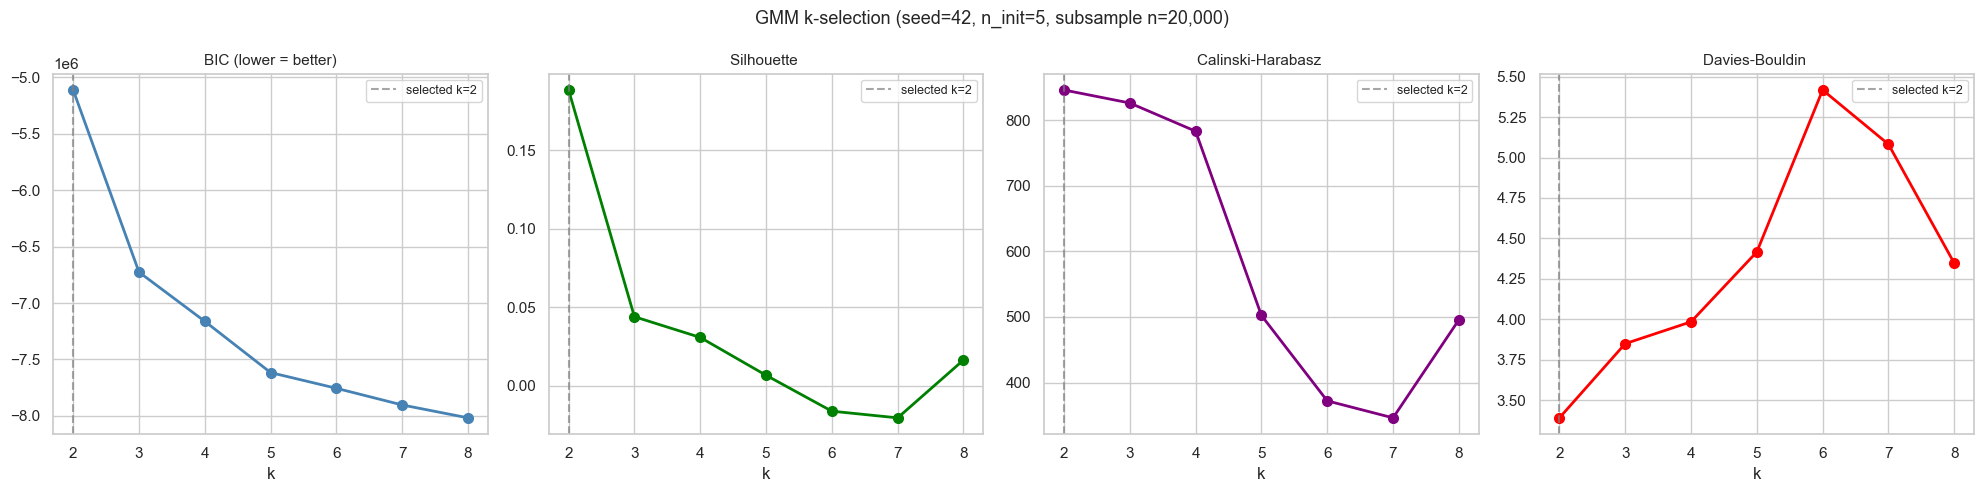

In [26]:
# GMM k-selection plots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 4 panels: BIC, Silhouette, CH, DB
for ax, (col, title, color) in zip(axes, [  # loop: one panel per metric
    ('bic','BIC (lower = better)','steelblue'),  # BIC panel — lower is better
    ('silhouette','Silhouette ','green'),  # Silhouette panel — higher is better
    ('calinski_harabasz','Calinski-Harabasz ','purple'),  # Calinski-Harabász panel — higher is better
    ('davies_bouldin','Davies-Bouldin ','red'),  # Davies-Bouldin panel — lower is better
]):  # end of metric list; begin plot loop body
    ax.plot(df_gmm_sweep.k, df_gmm_sweep[col], 'o-', color=color, linewidth=2, markersize=7)  # plot metric vs k
    ax.axvline(BEST_K_GMM, ls='--', color='grey', alpha=0.7, label=f'selected k={BEST_K_GMM}')  # mark selected k
    ax.set_title(title, fontsize=11); ax.set_xlabel('k'); ax.legend(fontsize=9)  # set axis labels and legend for each panel
plt.suptitle(f"GMM k-selection (seed={GLOBAL_SEED}, n_init=5, subsample n={GMM_SWEEP_N:,})", fontsize=13)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/gmm_k_selection.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline


In [27]:
# Final GMM on full dataset
gmm_final = GaussianMixture(n_components=BEST_K_GMM, covariance_type='full',  # refit at selected k on full data
                             n_init=5, random_state=GLOBAL_SEED, max_iter=200)  # n_init=5 run EM 5 times pick best; max_iter=200 convergence limit
gmm_final.fit(X_R0)  # fit EM on full 119,210 × 73 matrix
labels_gmm = gmm_final.predict(X_R0)  # hard labels: argmax of posterior probability
probs_gmm = gmm_final.predict_proba(X_R0)  # soft probabilities: k-dimensional vector per booking
max_prob_gmm = probs_gmm.max(axis=1)  # max probability per booking = assignment confidence

sil_gmm = silhouette_score(X_R0, labels_gmm, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette on hard labels
ch_gmm = calinski_harabasz_score(X_R0, labels_gmm)  # CH on hard labels
db_gmm = davies_bouldin_score(X_R0, labels_gmm)  # DB on hard labels
print(f'GMM (k={BEST_K_GMM}) → Sil={sil_gmm:.4f}  CH={ch_gmm:.1f}  DB={db_gmm:.4f}')  # print final GMM quality metrics
print(f'Converged: {gmm_final.converged_}  n_iter: {gmm_final.n_iter_}')  # confirm EM converged


GMM (k=2) → Sil=0.0257  CH=2630.9  DB=6.2215
Converged: True  n_iter: 9


In [28]:
# GMM stability across 5 seeds
gmm_stab_rows, gmm_stab_labels = [], []  # collect metrics and labels per seed
for seed in SEEDS:  # iterate over all seeds
    g = GaussianMixture(n_components=BEST_K_GMM, covariance_type='full', n_init=5,  # GMM with same settings, different seed for stability test
                        random_state=seed, max_iter=200)  # same settings, different seed
    g.fit(X_R0); lbl_s = g.predict(X_R0)  # fit and get hard labels
    sil_s = silhouette_score(X_R0, lbl_s, sample_size=5000, random_state=seed)  # Silhouette for this seed
    gmm_stab_rows.append({'seed': seed, 'silhouette': sil_s,  # store stability result for this seed
                           'calinski_harabasz': calinski_harabasz_score(X_R0, lbl_s),  # CH for this seed
                           'davies_bouldin': davies_bouldin_score(X_R0, lbl_s)})  # DB for this seed
    gmm_stab_labels.append(lbl_s)  # store labels for ARI
df_gmm_stab = pd.DataFrame(gmm_stab_rows)  # assemble GMM stability table
ari_gmm = [adjusted_rand_score(gmm_stab_labels[i], gmm_stab_labels[i+1]) for i in range(len(SEEDS)-1)]  # ARI between consecutive seeds
print(f'GMM mean ARI (consecutive seeds) = {np.mean(ari_gmm):.4f}')  # stability measure
print(df_gmm_stab[['silhouette','calinski_harabasz','davies_bouldin']].agg(['mean','std']).round(4))  # std across seeds


GMM mean ARI (consecutive seeds) = 0.4210
      silhouette  calinski_harabasz  davies_bouldin
mean      0.1292          4579.3901          4.2980
std       0.0993          1622.1020          1.5369


## 8. Full Method Comparison & Cluster Profiling

To organize, we made in the following order:

- **8a** — Full method comparison table
- **8b** — K-Means profiling (numerical, categorical, post-hoc)
- **8c** — Ward profiling
- **8d** — GMM profiling (including soft-assignment confidence)
- **8e** — Cross-method business metrics comparison


,method,k,silhouette,calinski_harabasz,davies_bouldin
0,K-Means,7,0.1333,12082.87,1.7578
1,iK-Means,3,0.1021,12214.22,2.4358
2,Ward,2,0.4496,11088.26,1.1888
3,GMM,2,0.0257,2630.92,6.2215


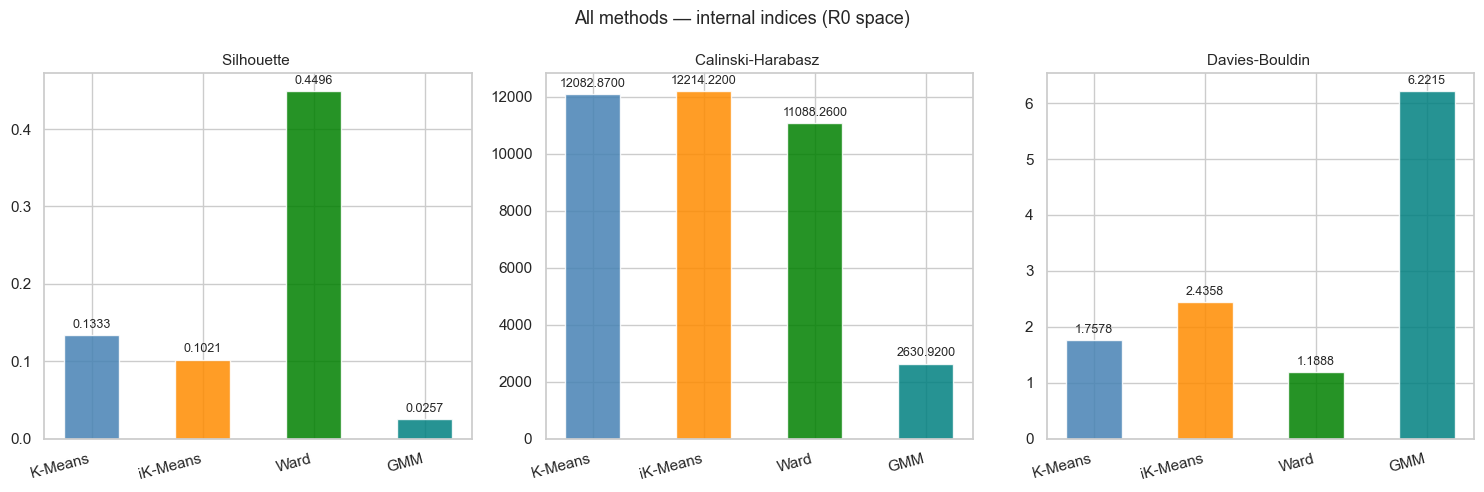

In [29]:
# Complete comparison: K-Means, iK-Means, Ward, GMM
full_compare = []  # collect final metrics for all methods
for method, lbl, k in [  # loop over all four methods
    ('K-Means', labels_km ,BEST_K),  # K-Means method: labels, k
    ('iK-Means', labels_ikm, k_ikm),  # iK-Means method: labels, k
    ('Ward', labels_hier, BEST_K_HIER),  # Ward method: labels, k
    ('GMM', labels_gmm, BEST_K_GMM),  # GMM method: labels, k
]:  # end of method list; begin comparison loop body
    sil = silhouette_score(X_R0, lbl, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette (same space for all)
    ch = calinski_harabasz_score(X_R0, lbl)  # CH
    db = davies_bouldin_score(X_R0, lbl)  # DB
    full_compare.append({'method': method, 'k': k, 'silhouette': round(sil,4),  # store cross-method comparison metrics
                          'calinski_harabasz': round(ch,2), 'davies_bouldin': round(db,4)})  # store

df_full_compare = pd.DataFrame(full_compare)  # assemble full comparison table
display(df_full_compare)  # unified comparison table
df_full_compare.to_csv('tables/full_method_comparison.csv', index=False)  # save

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 3 panels: one per metric
colors = ['steelblue','darkorange','green','teal']  # consistent colour per method
for ax, (col, title) in zip(axes, [  # loop: one bar chart panel per metric
    ('silhouette','Silhouette '), ('calinski_harabasz','Calinski-Harabasz '),  # metrics to plot: Silhouette, CH, DB
    ('davies_bouldin','Davies-Bouldin ')]):  # end of metric list
    bars = ax.bar(df_full_compare.method, df_full_compare[col], color=colors, alpha=0.85, width=0.5)  # draw bars for this metric
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)  # print values above bars
    ax.set_title(title, fontsize=11)  # set panel title
    ax.set_xticklabels(df_full_compare.method, rotation=15, ha='right')  # set method name labels rotated for readability
plt.suptitle('All methods — internal indices (R0 space)', fontsize=13)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/all_methods_comparison.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline


### 8b. K-Means Cluster Profiling

In [30]:
df_prof['cluster_km'] = labels_km  # attach K-Means labels to profiling dataframe
df_prof['cluster_ward'] = labels_hier  # attach Ward labels
df_prof['cluster_gmm'] = labels_gmm  # attach GMM labels
CL = 'cluster_km'  # active column for K-Means profiling

print(f'Cluster sizes ({CL}):')  # print number of bookings per cluster
display(df_prof[CL].value_counts().sort_index().rename('n'))  # number of bookings per K-Means cluster

num_prof_cols = ['lead_time','total_nights','party_size','previous_cancellations',  # numerical features used in clustering
                 'previous_bookings_not_canceled','total_of_special_requests',
                 'required_car_parking_spaces']
prof_num = df_prof.groupby(CL)[num_prof_cols].agg(['mean','median']).round(2)  # mean and median per cluster
display(prof_num)  # show numerical profile table
prof_num.to_csv('tables/profile_numerical.csv')  # save to tables


Cluster sizes (cluster_km):


cluster_km
0    12953
1    20096
2     2021
3     5847
4    39997
5    10052
6    28244
Name: n, dtype: int64

lead_time        total_nights        party_size         \
                mean median         mean median       mean median   
cluster_km                                                          
0             139.47  128.0         8.45    7.0       1.98    2.0   
1               5.71    3.0         1.87    1.0       1.61    2.0   
2              14.58    3.0         1.71    1.0       1.21    1.0   
3             213.64  257.0         2.73    2.0       1.84    2.0   
4             147.95  113.0         2.83    3.0       1.80    2.0   
5              88.25   66.0         3.59    3.0       3.45    3.0   
6              85.20   61.0         3.28    3.0       2.01    2.0   

           previous_cancellations        previous_bookings_not_canceled  \
                             mean median                           mean   
cluster_km                                                                
0                            0.00    0.0                           0.01   
1                            0.00    0.0                           0.05   
2                            0.59    0.0                           7.26   
3                            1.56    1.0                           0.02   
4                            0.00    0.0                           0.00   
5                            0.00    0.0                           0.00   
6                            0.00    0.0                           0.01   

                  total_of_special_requests         \
           median                      mean median   
cluster_km                                           
0             0.0                      0.51    0.0   
1             0.0                      0.31    0.0   
2             4.0                      0.74    0.0   
3             0.0                      0.12    0.0   
4             0.0                      0.08    0.0   
5             0.0                      0.59    0.0   
6             0.0                      1.55    1.0   

           required_car_parking_spaces         
                                  mean median  
cluster_km                                     
0                                 0.07    0.0  
1                                 0.13    0.0  
2                                 0.22    0.0  
3                                 0.00    0.0  
4                                 0.02    0.0  
5                                 0.10    0.0  
6                                 0.07    0.0

In [31]:
cat_prof_cols = ['hotel','market_segment','distribution_channel',  # categorical variables to profile
                 'deposit_type','customer_type','meal_clean','reserved_room_type','country_grouped']
for col in cat_prof_cols:  # iterate over each categorical variable
    ct = pd.crosstab(df_prof[CL], df_prof[col], normalize='index') * 100  # % of each category WITHIN each cluster (row-normalised)
    print(f'\n{col} (% within cluster)')  # section header for each categorical variable cross-tab
    display(ct.round(1))  # show category distribution per cluster



hotel (% within cluster)


hotel,City Hotel,Resort Hotel
cluster_km,,
0,16.9,83.1
1,51.9,48.1
2,49.7,50.3
3,85.1,14.9
4,83.3,16.7
5,67.0,33.0
6,72.6,27.4



market_segment (% within cluster)


market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
cluster_km,,,,,,,,
0,0.2,0.1,1.6,11.9,9.2,35.5,41.6,0.0
1,0.9,2.1,13.7,30.4,5.4,11.1,36.5,0.0
2,1.0,7.8,61.5,15.6,1.2,3.6,9.3,0.0
3,0.1,0.2,3.0,2.1,56.8,28.3,9.5,0.0
4,0.0,0.1,2.1,3.7,34.9,34.6,24.7,0.0
5,0.0,0.3,0.5,15.1,0.8,7.7,75.5,0.0
6,0.0,0.2,0.1,5.3,0.4,3.6,90.2,0.0



distribution_channel (% within cluster)


...

meal_clean,BB,FB,HB,SC
cluster_km,,,,
0,65.0,1.4,28.7,4.9
1,84.1,0.2,5.1,10.5
2,96.4,0.1,2.2,1.3
3,82.1,1.7,14.6,1.7
4,76.0,1.0,14.1,8.8
5,86.0,0.5,11.8,1.7
6,74.8,0.0,7.0,18.2



reserved_room_type (% within cluster)


reserved_room_type,A,B,C,D,E,F,G,H,L
cluster_km,,,,,,,,,
0,49.6,0.5,0.9,29.4,15.1,2.9,1.3,0.3,0.0
1,76.4,0.7,0.4,12.9,6.0,2.2,1.1,0.2,0.0
2,84.0,0.5,0.2,7.3,5.1,1.4,1.3,0.0,0.0
3,95.3,0.8,0.1,2.6,0.9,0.2,0.1,0.0,0.0
4,88.4,0.8,0.1,8.2,2.1,0.3,0.1,0.0,0.0
5,22.7,1.0,6.3,28.3,6.3,15.7,14.7,5.0,0.0
6,67.9,1.5,0.2,22.4,6.2,1.1,0.5,0.1,0.0



country_grouped (% within cluster)


country_grouped,AUT,BEL,BRA,CHE,CN,DEU,ESP,FRA,GBR,IRL,ITA,NLD,Other,PRT,SWE,USA
cluster_km,,,,,,,,,,,,,,,,
0,0.9,1.5,1.2,1.3,1.2,5.4,4.5,5.5,28.0,8.7,1.4,1.8,8.8,28.1,1.0,0.7
1,0.7,1.3,1.4,0.9,0.7,3.1,9.8,6.2,5.7,1.2,2.5,1.7,9.8,52.2,0.6,2.2
2,0.2,0.2,0.1,0.0,0.0,0.1,1.1,1.7,1.4,0.1,0.2,0.3,7.5,86.9,0.0,0.0
3,0.0,0.3,0.1,0.0,0.0,0.1,0.6,0.1,1.7,1.1,0.0,0.0,0.4,95.5,0.1,0.0
4,1.2,1.4,1.3,1.1,1.1,8.3,5.0,8.9,6.7,1.5,3.3,1.1,7.5,49.4,0.8,1.3
5,1.2,2.8,3.5,2.2,1.1,4.9,12.1,10.8,10.1,2.6,5.2,2.2,13.9,23.4,1.3,2.8
6,1.4,3.6,3.3,2.5,1.5,7.6,9.6,13.3,12.5,3.9,4.3,3.0,12.4,17.4,1.1,2.8


is_canceled             adr         booking_changes       
                  mean median     mean  median            mean median
cluster_km                                                           
0                0.328    0.0  101.384   88.00           0.317    0.0
1                0.131    0.0   86.876   80.25           0.221    0.0
2                0.056    0.0   61.455   65.00           0.279    0.0
3                0.990    1.0   77.530   69.00           0.028    0.0
4                0.512    1.0   93.183   90.00           0.181    0.0
5                0.411    0.0  162.259  157.50           0.323    0.0
6                0.241    0.0  111.920  107.10           0.223    0.0


Cancellation rate per cluster:


cluster_km
0    0.328
1    0.131
2    0.056
3    0.990
4    0.512
5    0.411
6    0.241
Name: cancel_rate, dtype: float64

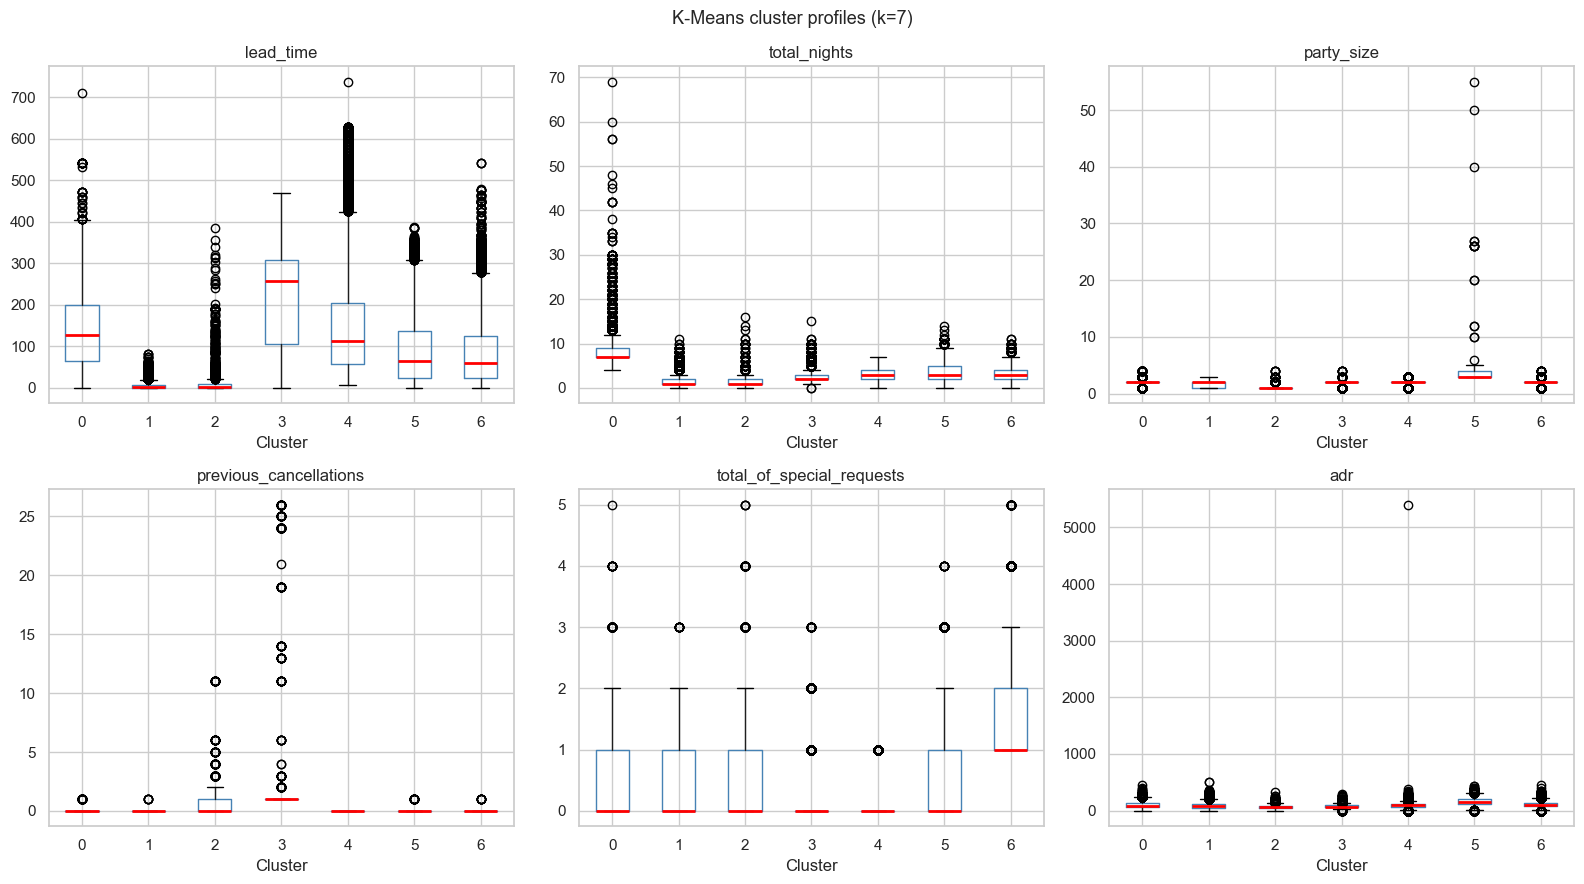

In [32]:
# Post-hoc variables (NOT used to form clusters — leakage check)
posthoc = ['is_canceled','adr','booking_changes']  # variables excluded from clustering to avoid target leakage
display(df_prof.groupby(CL)[posthoc].agg(['mean','median']).round(3))  # mean and median of post-hoc vars per cluster
print('\nCancellation rate per cluster:')  # section header for cancellation rate table
display(df_prof.groupby(CL)['is_canceled'].mean().rename('cancel_rate').round(3))  # cancel rate per cluster (key business metric)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))  # 2×3 grid of boxplots
for ax, col in zip(axes.flat, ['lead_time','total_nights','party_size',  # loop: one boxplot per variable
                                'previous_cancellations','total_of_special_requests','adr']):
    df_prof.boxplot(column=col, by=CL, ax=ax,  # box per cluster showing distribution spread
                    boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))  # K-Means cluster boxplots styling
    ax.set_title(col); ax.set_xlabel('Cluster')  # set subplot title and x-axis label
plt.suptitle(f'K-Means cluster profiles (k={BEST_K})', fontsize=13)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/profiles_boxplots.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline


### 8c. Ward Cluster Profiling

In [33]:
CL_W = 'cluster_ward'  # column name for Ward cluster labels
print('Ward cluster sizes:')  # print size of each Ward cluster
display(df_prof[CL_W].value_counts().sort_index())  # number of bookings per Ward cluster
prof_ward = df_prof.groupby(CL_W)[['lead_time','total_nights','party_size',  # numerical profile for Ward clusters
    'adr','total_of_special_requests','previous_cancellations']].agg(['mean','median']).round(2)
display(prof_ward)  # render table in notebook output
print('\nWard cancellation rate:')  # section header for Ward cancellation rates
display(df_prof.groupby(CL_W)['is_canceled'].mean().rename('cancel_rate').round(3))  # post-hoc: cancel rate per Ward cluster
print('\nHotel type (% within Ward cluster):')  # section header for hotel type cross-tab within Ward clusters
display((pd.crosstab(df_prof[CL_W], df_prof['hotel'], normalize='index')*100).round(1))  # hotel type distribution within each Ward cluster
prof_ward.to_csv('tables/profile_ward.csv')  # save Ward profile


Ward cluster sizes:


cluster_ward
0    116021
1      3189
Name: count, dtype: int64

lead_time        total_nights        party_size            adr  \
                  mean median         mean median       mean median    mean   
cluster_ward                                                                  
0               106.60   72.0         3.47    3.0       1.99    2.0  103.06   
1                13.63    3.0         1.76    1.0       1.24    1.0   62.32   

                    total_of_special_requests        previous_cancellations  \
             median                      mean median                   mean   
cluster_ward                                                                  
0              95.0                      0.57    0.0                   0.08   
1              65.0                      0.66    0.0                   0.48   

                     
             median  
cluster_ward         
0               0.0  
1               0.0


Ward cancellation rate:


cluster_ward
0    0.379
1    0.060
Name: cancel_rate, dtype: float64


Hotel type (% within Ward cluster):


hotel,City Hotel,Resort Hotel
cluster_ward,,
0,67.0,33.0
1,44.4,55.6


### 8d. GMM Cluster Profiling

GMM produces **soft assignments** — each booking has a probability vector over clusters.
We profile using hard labels (argmax) and inspect assignment confidence per cluster.


In [34]:
CL_G = 'cluster_gmm'  # column name for GMM cluster labels
print(f'GMM (k={BEST_K_GMM}) cluster sizes:')  # print size of each GMM cluster
display(df_prof[CL_G].value_counts().sort_index().rename('n'))  # bookings per GMM cluster
print(f'Ratio max/min: {df_prof[CL_G].value_counts().max() / df_prof[CL_G].value_counts().min():.2f}')  # imbalance check

num_prof_cols_g = ['lead_time','total_nights','party_size','previous_cancellations',  # numerical features for GMM profile
                   'previous_bookings_not_canceled','total_of_special_requests',
                   'required_car_parking_spaces']
prof_num_gmm = df_prof.groupby(CL_G)[num_prof_cols_g].agg(['mean','median']).round(2)  # mean and median per GMM cluster
display(prof_num_gmm)  # render table in notebook output
prof_num_gmm.to_csv('tables/profile_gmm_numerical.csv')  # save

for col in ['hotel','market_segment','deposit_type','customer_type']:  # categorical profile for GMM
    ct = pd.crosstab(df_prof[CL_G], df_prof[col], normalize='index') * 100  # % within each GMM cluster
    print(f'\n  {col} (% within GMM cluster)')  # section header for each categorical cross-tab
    display(ct.round(1))  # render table in notebook output

posthoc = ['is_canceled','adr','booking_changes']  # post-hoc variables (excluded from clustering)
display(df_prof.groupby(CL_G)[posthoc].agg(['mean','median']).round(3))  # post-hoc profile per GMM cluster
print('\nCancellation rate per GMM cluster:')  # section header for GMM cancellation rates
display(df_prof.groupby(CL_G)['is_canceled'].mean().rename('cancel_rate').round(3))  # cancel rate per GMM cluster


GMM (k=2) cluster sizes:


cluster_gmm
0    54189
1    65021
Name: n, dtype: int64

Ratio max/min: 1.20


lead_time        total_nights        party_size         \
                 mean median         mean median       mean median   
cluster_gmm                                                          
0              133.00  103.0         3.59    3.0       2.15    2.0   
1               80.03   46.0         3.29    3.0       1.82    2.0   

            previous_cancellations        previous_bookings_not_canceled  \
                              mean median                           mean   
cluster_gmm                                                                
0                             0.13    0.0                           0.01   
1                             0.05    0.0                           0.24   

                   total_of_special_requests         \
            median                      mean median   
cluster_gmm                                           
0              0.0                      0.55    0.0   
1              0.0                      0.59    0.0   

            required_car_parking_spaces         
                                   mean median  
cluster_gmm                                     
0                                  0.05    0.0  
1                                  0.08    0.0


  hotel (% within GMM cluster)


...


  customer_type (% within GMM cluster)


customer_type,Contract,Group,Transient,Transient-Party
cluster_gmm,,,,
0,7.5,0.3,77.3,14.9
1,0.0,0.6,73.2,26.2


is_canceled             adr        booking_changes       
                   mean median     mean median            mean median
cluster_gmm                                                          
0                 0.457    0.0  108.858  100.0           0.206    0.0
1                 0.299    0.0   96.228   89.1           0.229    0.0


Cancellation rate per GMM cluster:


cluster_gmm
0    0.457
1    0.299
Name: cancel_rate, dtype: float64

GMM assignment confidence per cluster (mean):


,mean,median,min
cluster_gmm,,,
0,1.0,1.0,0.998
1,1.0,1.0,1.000


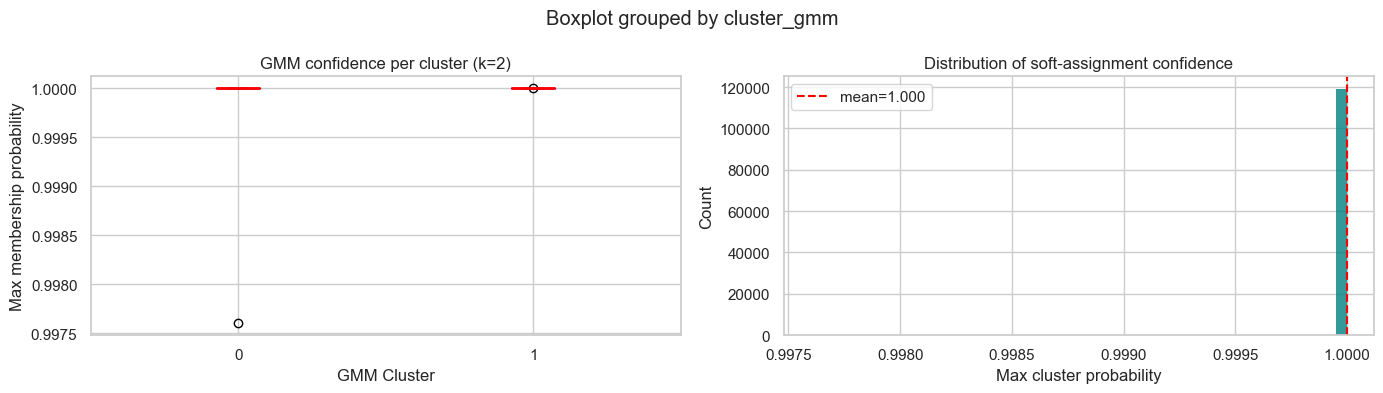

In [35]:
# GMM soft-assignment confidence
df_prof['gmm_confidence'] = max_prob_gmm  # attach max posterior probability per booking
print('GMM assignment confidence per cluster (mean):')  # section header for confidence analysis
display(df_prof.groupby(CL_G)['gmm_confidence'].agg(['mean','median','min']).round(3))  # min shows if any bookings are ambiguous

fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # two-panel: boxplot per cluster + histogram of max prob
df_prof.boxplot(column='gmm_confidence', by=CL_G, ax=axes[0],  # box per cluster: spread of confidence scores
                boxprops=dict(color='purple'), medianprops=dict(color='red', linewidth=2))  # GMM cluster boxplots styling
axes[0].set_xlabel('GMM Cluster'); axes[0].set_ylabel('Max membership probability')  # label axes for confidence boxplot panel
plt.sca(axes[0]); plt.title(f'GMM confidence per cluster (k={BEST_K_GMM})')  # set title for confidence boxplot panel
axes[1].hist(max_prob_gmm, bins=50, color='teal', edgecolor='none', alpha=0.8)  # histogram of all booking confidences
axes[1].axvline(max_prob_gmm.mean(), color='red', ls='--',  # vertical line at mean confidence across all bookings
                label=f'mean={max_prob_gmm.mean():.3f}')  # legend label for mean confidence line
axes[1].set_xlabel('Max cluster probability'); axes[1].set_ylabel('Count')  # label axes for confidence histogram panel
axes[1].set_title('Distribution of soft-assignment confidence')  # title for confidence histogram panel
axes[1].legend()  # show mean confidence line legend
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/gmm_confidence_per_cluster.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline
# high confidence(max-prob-gmm) = well-separated clusters
# low confidence(max-prob-gmm) = ambiguous bookings


### 8e. Cross-method Business Metrics Comparison

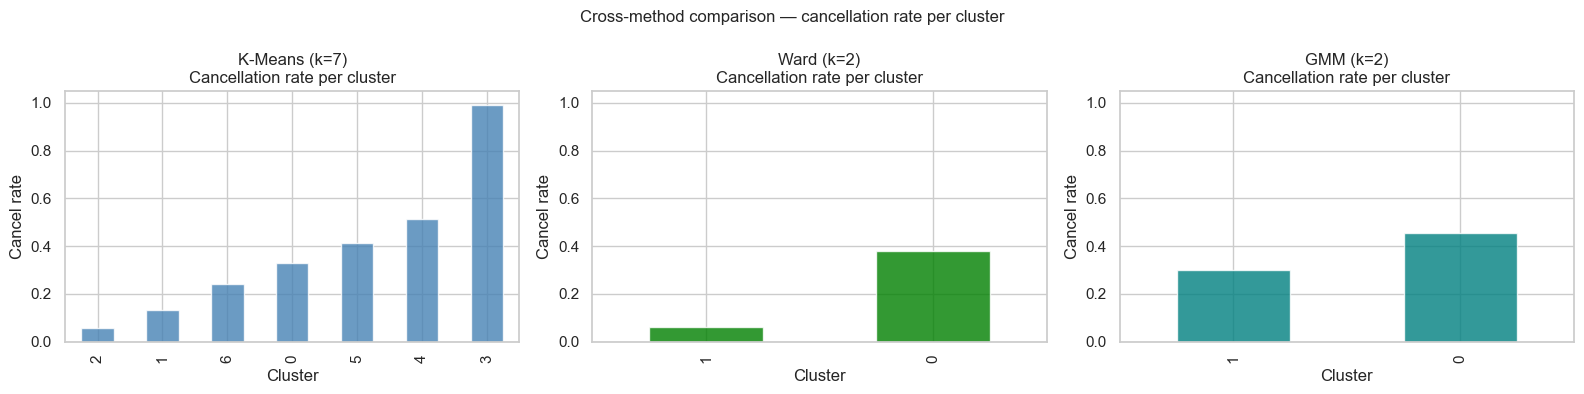

,method,cancel_rate_range,lead_time_range,adr_range (post-hoc)
0,K-Means k=7,0.06 – 0.99,6 – 214,61 – 162
1,Ward k=2,0.06 – 0.38,14 – 107,62 – 103
2,GMM k=2,0.30 – 0.46,80 – 133,96 – 109


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 3 panels: one per method
for ax, (cl_col, title, color) in zip(axes, [  # loop: one bar chart per clustering method
    ('cluster_km',f'K-Means (k={BEST_K})', 'steelblue'),  # K-Means panel
    ('cluster_ward', f'Ward (k={BEST_K_HIER})', 'green'),  # Ward panel
    ('cluster_gmm', f'GMM (k={BEST_K_GMM})', 'teal'),  # GMM panel
]):  # end of method list; begin plot loop body
    cancel_rates = df_prof.groupby(cl_col)['is_canceled'].mean().sort_values()  # cancel rate per cluster, sorted ascending
    cancel_rates.plot(kind='bar', ax=ax, color=color, alpha=0.8)  # draw cancellation rate bar chart for this method
    ax.set_title(f'{title}\nCancellation rate per cluster')  # set panel title with method name
    ax.set_ylim(0, 1.05); ax.set_ylabel('Cancel rate'); ax.set_xlabel('Cluster')  # set y-axis limits and labels
plt.suptitle('Cross-method comparison — cancellation rate per cluster', fontsize=12)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/crossmethod_cancel_rate.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

summary_methods = []  # business-level summary: range of key metrics per method
for cl_col, method in [('cluster_km', f'K-Means k={BEST_K}'),  # K-Means panel
                        ('cluster_ward', f'Ward k={BEST_K_HIER}'),  # Ward panel
                        ('cluster_gmm', f'GMM k={BEST_K_GMM}')]:  # GMM panel
    cr = df_prof.groupby(cl_col)['is_canceled'].mean()  # cancel rate per cluster
    lt = df_prof.groupby(cl_col)['lead_time'].mean()  # lead time per cluster
    adr_m = df_prof.groupby(cl_col)['adr'].mean()  # ADR per cluster (post-hoc)
    summary_methods.append({  # store business metric summary for this method
        'method': method,
        'cancel_rate_range': f'{cr.min():.2f} – {cr.max():.2f}',  # range from lowest to highest cluster
        'lead_time_range': f'{lt.min():.0f} – {lt.max():.0f}',
        'adr_range (post-hoc)': f'{adr_m.min():.0f} – {adr_m.max():.0f}',
    })  # close summary dict
display(pd.DataFrame(summary_methods))  # show business-level comparison table


## 9. Extension A — Cluster-Aware Anomaly Detection

after forming clusters, identify bookings anomalous relative to their cluster prototype.

**Score:** normalised distance to assigned K-Means centroid.
A score > 1 means the point is farther than average from its cluster centre.
ADR is included here as a post-hoc descriptor of anomalies, not as a clustering input.


Anomaly score summary:
 Mean: 1.000
 Median: 0.962
 P95: 1.339
 P99: 1.703
 Max: 27.215


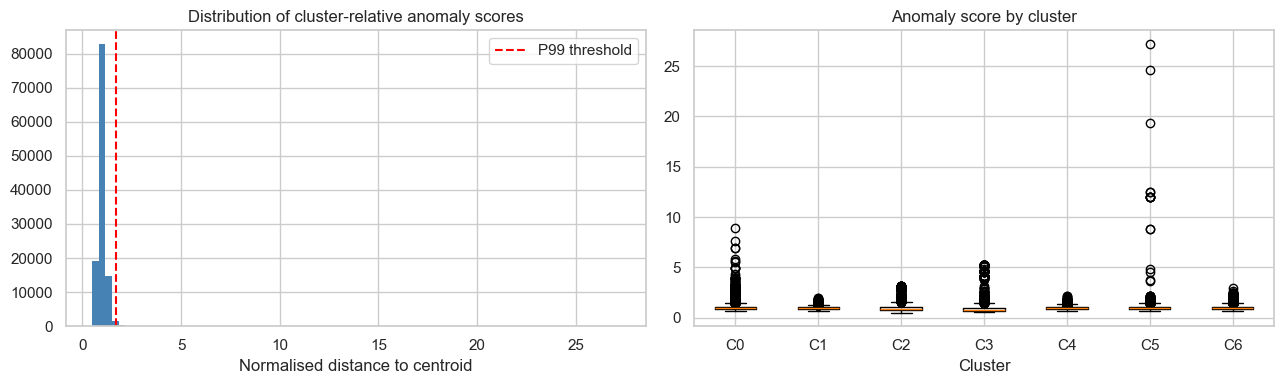

In [37]:
centroids_km  = km_final.cluster_centers_  # K-Means centroid matrix: shape (BEST_K, 73)
dist_to_centroid = np.linalg.norm(X_R0 - centroids_km[labels_km], axis=1)  # Euclidean distance from each booking to its assigned centroid
cluster_mean_dist= np.array([dist_to_centroid[labels_km == c].mean() for c in range(BEST_K)])  # mean distance within each cluster (normalisation factor)
anomaly_score = dist_to_centroid / (cluster_mean_dist[labels_km] + 1e-12)  # normalised score: >1 means farther than cluster average; 1e-12 avoids division by zero

print('Anomaly score summary:')  # section header for anomaly score statistics
print(f' Mean: {anomaly_score.mean():.3f}')  # expected ~1.0 by construction
print(f' Median: {np.median(anomaly_score):.3f}')  # median < mean indicates right-skewed distribution
print(f' P95: {np.percentile(anomaly_score, 95):.3f}')  # 95th percentile
print(f' P99: {np.percentile(anomaly_score, 99):.3f}')  # P99 threshold used to flag anomalies
print(f' Max: {anomaly_score.max():.3f}')  # most extreme booking in the dataset

fig, axes = plt.subplots(1, 2, figsize=(13, 4))  # two-panel: score histogram + boxplot per cluster
axes[0].hist(anomaly_score, bins=80, color='steelblue', edgecolor='none')  # distribution of all anomaly scores
axes[0].axvline(np.percentile(anomaly_score, 99), color='red', ls='--', label='P99 threshold')  # vertical line at detection threshold
axes[0].set_title('Distribution of cluster-relative anomaly scores')  # set title for score distribution panel
axes[0].set_xlabel('Normalised distance to centroid'); axes[0].legend()  # label x-axis for score histogram
axes[1].boxplot([anomaly_score[labels_km == c] for c in range(BEST_K)],  # one box per cluster
                labels=[f'C{c}' for c in range(BEST_K)])  # one box per cluster labelled C0, C1, …
axes[1].set_title('Anomaly score by cluster'); axes[1].set_xlabel('Cluster')  # shows which clusters have most anomalies
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/anomaly_score_dist.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline


In [38]:
TOP_K_ANOM = 20  # number of top anomalies to inspect
top20_idx = np.argsort(anomaly_score)[::-1][:TOP_K_ANOM]  # indices of 20 bookings with highest anomaly score
key_cols = ['hotel','lead_time','total_nights','party_size','previous_cancellations',  # columns to display for each anomaly
               'previous_bookings_not_canceled','adr','market_segment','deposit_type',
               'customer_type','is_canceled','reservation_status']
df_anom = df_prof.iloc[top20_idx][key_cols].copy()  # subset top-20 rows
df_anom.insert(0,'anomaly_rank', range(1, TOP_K_ANOM+1))  # add rank column (1=most anomalous)
df_anom.insert(1,'anomaly_score', np.round(anomaly_score[top20_idx], 3))  # add score
df_anom.insert(2,'cluster_km', labels_km[top20_idx])  # add cluster assignment

def classify_anomaly(row):  # rule-based classifier: assign semantic label to each anomaly
    if row['party_size'] == 0: return 'data-quality: 0 guests'  # should have been removed — data quality issue
    if row['lead_time'] > 600: return 'rare: extreme lead time'  # booking >600 days in advance
    if row['adr'] > 1000: return 'rare: extreme price'  # ADR > 1000€ per night
    if row['previous_cancellations'] > 15: return 'rare: many cancellations'  # serial canceller
    if row['deposit_type'] == 'Non Refund' and row['is_canceled'] == 0:  # interesting: non-refundable deposit but booking not cancelled
                                             return 'interesting: paid but showed'  # non-refundable deposit but didn't cancel
    return 'rare booking pattern'  # catch-all for other anomalous combinations

df_anom['anomaly_type'] = df_anom.apply(classify_anomaly, axis=1)  # apply classifier row by row
display(df_anom[['anomaly_rank','anomaly_score','cluster_km','anomaly_type',  # render table in notebook output
                  'hotel','lead_time','adr','deposit_type','is_canceled']].round(2))
df_anom.to_csv('tables/top20_anomalies.csv', index=False)  # save top-20 anomaly table


,anomaly_rank,anomaly_score,cluster_km,anomaly_type,hotel,lead_time,adr,deposit_type,is_canceled
2173,1,27.22,5,rare booking pattern,Resort Hotel,338,0.00,No Deposit,1
1643,2,24.58,5,rare booking pattern,Resort Hotel,336,0.00,No Deposit,1
1539,3,19.31,5,rare booking pattern,Resort Hotel,304,0.00,No Deposit,1
1962,4,12.49,5,rare booking pattern,Resort Hotel,352,0.00,No Deposit,1
1917,5,12.49,5,rare booking pattern,Resort Hotel,349,0.00,No Deposit,1
2164,6,11.96,5,rare booking pattern,Resort Hotel,361,0.00,No Deposit,1
2003,7,11.96,5,rare booking pattern,Resort Hotel,354,0.00,No Deposit,1
1884,8,11.96,5,rare booking pattern,Resort Hotel,347,0.00,No Deposit,1
1752,9,11.96,5,rare booking pattern,Resort Hotel,340,0.00,No Deposit,1
1587,10,11.96,5,rare booking pattern,Resort Hotel,333,0.00,No Deposit,1


In [39]:
# Anomaly stability: R0 vs R1
km_r1_anom = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # refit K-Means on R1
labels_km_r1_anom = km_r1_anom.fit_predict(X_R1)  # R1 labels
cents_r1 = km_r1_anom.cluster_centers_  # R1 centroids
dist_r1 = np.linalg.norm(X_R1 - cents_r1[labels_km_r1_anom], axis=1)  # distances in R1 space
cmean_r1 = np.array([dist_r1[labels_km_r1_anom==c].mean() for c in range(BEST_K)])  # per-cluster mean distance in R1
anom_r1 = dist_r1 / (cmean_r1[labels_km_r1_anom] + 1e-12)  # normalised anomaly score in R1 space

top20_r1 = set(np.argsort(anom_r1)[::-1][:TOP_K_ANOM])  # top-20 anomaly indices under R1
top20_r0 = set(top20_idx)  # top-20 anomaly indices under R0
overlap = len(top20_r0 & top20_r1)  # number of bookings in both top-20 sets
print(f'Top-{TOP_K_ANOM} anomaly overlap (R0 vs R1): {overlap}/{TOP_K_ANOM}')  # print overlap count and stability verdict
#stable if overlap > 14
print(f'Jaccard: {overlap / len(top20_r0 | top20_r1):.3f}')  # Jaccard = |intersection| / |union|: 0=no overlap, 1=identical
rho, pval = spearmanr(pd.Series(anomaly_score).rank(ascending=False),  # rank-correlation of anomaly rankings
                       pd.Series(anom_r1).rank(ascending=False))  # rank R1 anomaly scores (descending) for Spearman correlation
print(f'Spearman rank correlation (R0 vs R1): corr={rho:.4f}  corr={pval:.2e}')  # high corr = same books are anomalous in both representations


Top-20 anomaly overlap (R0 vs R1): 19/20
Jaccard: 0.905
Spearman rank correlation (R0 vs R1): corr=0.6213  corr=0.00e+00


## 10. Extension B — Spectral Clustering

Spectral clustering operates on the **graph structure** of the data, not Euclidean distances.

**Pipeline:**
1. Build k-NN affinity graph with RBF weights
2. Compute normalised Laplacian L_sym = I − D^{−½} W D^{−½}
3. Embed in space of first k eigenvectors (Ng-Jordan-Weiss)
4. Apply K-Means in embedding space

The **eigengap heuristic** suggests the number of clusters independently of Silhouette.
If eigengap and Silhouette disagree, both are reported.


In [40]:
def build_knn_affinity(X, n_neighbors=10):
    from sklearn.metrics import pairwise_distances
    dist_full  = pairwise_distances(X, metric='euclidean')
    dist2_full = dist_full ** 2
    tri= dist2_full[np.triu_indices_from(dist2_full, k=1)]
    tri= tri[tri > 0]
    sigma = float(np.sqrt(np.median(tri))) if len(tri) > 0 else 1.0
    n = dist2_full.shape[0]
    work = dist2_full.copy()
    np.fill_diagonal(work, np.inf)
    knn_idx = np.argsort(work, axis=1)[:, :n_neighbors]
    W = np.zeros((n, n), dtype=float)
    for i in range(n):
        js = knn_idx[i]
        W[i, js] = np.exp(-dist2_full[i, js] / (2.0 * sigma**2))
    W = np.maximum(W, W.T)
    np.fill_diagonal(W, 0.0)
    return W, sigma

def normalised_laplacian(W): # compute normalised graph Laplacian L_sym = I - D^{-1/2} W D^{-1/2}
    degrees = W.sum(axis=1)  # degree of each node: sum of edge weights
    D_inv_sqrt= np.diag(1.0 / np.sqrt(np.where(degrees > 0, degrees, 1.0)))  # D^{-1/2}: inverse square root of degree matrix
    L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt  # normalised Laplacian: eigenvalues in [0,2]
    return L, degrees  # return Laplacian and degree vector

def spectral_embed(L, k):  # embed data in space of k smallest eigenvectors of L
    evals, evecs = np.linalg.eigh(L)  # eigendecomposition: eigh for symmetric matrices
    idx = np.argsort(evals); U = evecs[:, idx[:k]]  # take k eigenvectors with smallest eigenvalues
    norms = np.linalg.norm(U, axis=1, keepdims=True); norms[norms == 0] = 1.0  # row-normalise (Ng-Jordan-Weiss step)
    return evals[idx], U / norms  # return sorted eigenvalues and row-normalised embedding matrix



Spectral: subsample=5000, n_neighbors=10
Graph built  sigma=4.1253  mean_degree=12.60
First 10 eigenvalues: [0.     0.0021 0.0081 0.0134 0.0253 0.0282 0.0327 0.0359 0.0401 0.0413]
Eigengaps: [0.0021 0.006  0.0053 0.0118 0.0029 0.0045 0.0032 0.0042 0.0012]
Largest gap at position: 4 → K_SPEC = 4
(K-Means uses k=7 — methods may differ, compared via ARI)


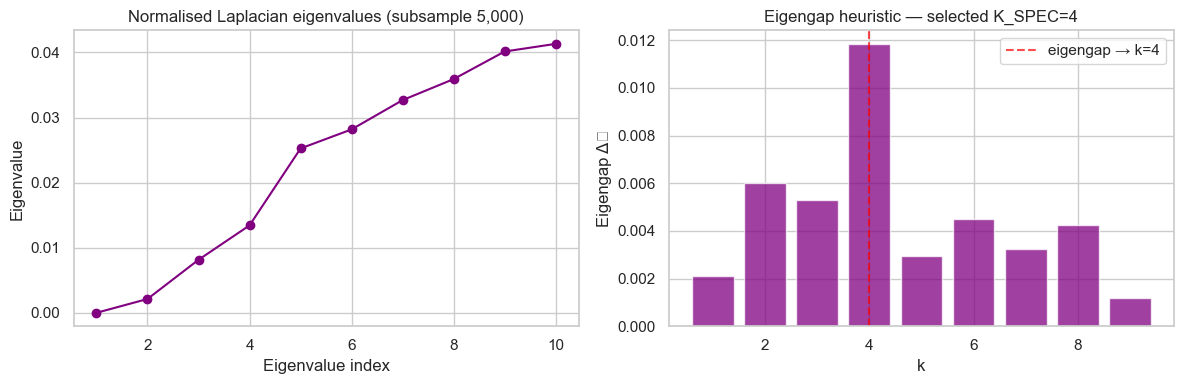

In [41]:
SUBSAMPLE_SPEC = 5_000; N_KNN = 10
np.random.seed(GLOBAL_SEED)
spec_idx = np.random.choice(len(X_R0), size=SUBSAMPLE_SPEC, replace=False)
X_spec= X_R0[spec_idx].astype(np.float64)

print(f'Spectral: subsample={SUBSAMPLE_SPEC}, n_neighbors={N_KNN}')
t0 = time.time()
W_spec, sigma_spec = build_knn_affinity(X_spec, n_neighbors=N_KNN)
L_spec, degrees_spec = normalised_laplacian(W_spec)
print(f'Graph built  sigma={sigma_spec:.4f}  mean_degree={degrees_spec.mean():.2f}')

# Primeiro calculamos eigenvalues com janela generosa para detectar o eigengap
K_SEARCH = max(BEST_K + 3, 9)
evals_search, _ = spectral_embed(L_spec, k=K_SEARCH)
gaps= np.diff(evals_search[:K_SEARCH])
k_eigengap = int(gaps.argmax()) + 1
k_eigengap = max(2, k_eigengap)
K_SPEC = k_eigengap  # k natural do Spectral — não força BEST_K

print(f'First {K_SEARCH} eigenvalues: {np.round(evals_search[:K_SEARCH], 4)}')
print(f'Eigengaps: {np.round(gaps, 4)}')
print(f'Largest gap at position: {k_eigengap} → K_SPEC = {K_SPEC}')
print(f'(K-Means uses k={BEST_K} — methods may differ, compared via ARI)')

# Re-embed com k final
evals_spec, T_spec = spectral_embed(L_spec, k=K_SPEC)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, K_SEARCH+1), evals_search[:K_SEARCH], 'o-', color='purple')
axes[0].set_xlabel('Eigenvalue index'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'Normalised Laplacian eigenvalues (subsample {SUBSAMPLE_SPEC:,})')
axes[1].bar(np.arange(1, K_SEARCH), gaps, color='purple', alpha=0.75)
axes[1].axvline(k_eigengap, ls='--', color='red', alpha=0.7, label=f'eigengap → k={k_eigengap}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Eigengap Δₖ')
axes[1].set_title(f'Eigengap heuristic — selected K_SPEC={K_SPEC}')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/spectral_eigengap.png', dpi=120, bbox_inches='tight')
plt.show()


In [42]:
km_spec = KMeans(n_clusters=K_SPEC, init='k-means++', n_init=10, random_state=GLOBAL_SEED)
labels_spec_sub = km_spec.fit_predict(T_spec)
spec_rt = time.time() - t0
spec_centroids_R0 = np.array([X_spec[labels_spec_sub==c].mean(axis=0) for c in range(K_SPEC)])
labels_spec = pairwise_distances_argmin(X_R0, spec_centroids_R0)

sil_spec = silhouette_score(X_R0, labels_spec, sample_size=5000, random_state=GLOBAL_SEED)
ch_spec= calinski_harabasz_score(X_R0, labels_spec)
db_spec= davies_bouldin_score(X_R0, labels_spec)
print(f'Spectral (k={K_SPEC}, eigengap) → Sil={sil_spec:.4f}  CH={ch_spec:.0f}  DB={db_spec:.4f}  t={spec_rt:.1f}s')
ari_km_spec = adjusted_rand_score(labels_km, labels_spec)
print(f'ARI(K-Means k={BEST_K} vs Spectral k={K_SPEC}) = {ari_km_spec:.4f}')
if ari_km_spec < 0.5:
    print('Partitions differ substantially — Spectral reveals different structure.')
elif ari_km_spec < 0.8:
    print('Moderate overlap — similar broad segments, different fine-grained structure.')
else:
    print('High overlap — Spectral confirms K-Means partition.')

print('\nSensitivity to n_neighbors:')
spec_sens_rows = []
for nn in [5, 10, 15, 20]:
    W_nn, _ = build_knn_affinity(X_spec, n_neighbors=nn)
    L_nn, _ = normalised_laplacian(W_nn)
    _, T_nn = spectral_embed(L_nn, k=K_SPEC)
    km_nn = KMeans(n_clusters=K_SPEC, init='k-means++', n_init=5, random_state=GLOBAL_SEED)
    lbl_nn = km_nn.fit_predict(T_nn)
    cents_nn= np.array([X_spec[lbl_nn==c].mean(0) for c in range(K_SPEC)])
    lbl_full_nn = pairwise_distances_argmin(X_R0, cents_nn)
    sil_nn= silhouette_score(X_R0, lbl_full_nn, sample_size=5000, random_state=GLOBAL_SEED)
    ari_nn= adjusted_rand_score(labels_spec, lbl_full_nn)
    spec_sens_rows.append({'n_neighbors': nn, 'silhouette': round(sil_nn,4), 'ARI_vs_ref': round(ari_nn,4)})
    print(f'n_neighbors={nn}  Sil={sil_nn:.4f}  ARI={ari_nn:.4f}')

df_spec_sens = pd.DataFrame(spec_sens_rows)
display(df_spec_sens)
df_spec_sens.to_csv('tables/spectral_sensitivity_knn.csv', index=False)


Spectral (k=4, eigengap) → Sil=0.0495  CH=9972  DB=1.7032  t=52.4s
ARI(K-Means k=7 vs Spectral k=4) = 0.0604
Partitions differ substantially — Spectral reveals different structure.

Sensitivity to n_neighbors:
n_neighbors=5  Sil=-0.0106  ARI=0.7785
n_neighbors=10  Sil=0.0495  ARI=1.0000
n_neighbors=15  Sil=0.0499  ARI=0.9952
n_neighbors=20  Sil=0.0502  ARI=0.9922


,n_neighbors,silhouette,ARI_vs_ref
0,5,-0.0106,0.7785
1,10,0.0495,1.0000
2,15,0.0499,0.9952
3,20,0.0502,0.9922


## 11. Extension C — UMAP-20D as Preprocessing + t-SNE/UMAP Visualisation


**scale/impute, PCA baseline, UMAP 20D (higher-dimensional reduced space) ,cluster, t-SNE/UMAP to inspect**


Key design decisions:
- **PCA** is computed first as a linear baseline (slide 6 pipeline requirement)
- **UMAP-20D** is used as nonlinear preprocessing — not for 2D visualisation
- **K-Means** and **Spectral** are the two methods applied in UMAP-20D space
  - K-Means: compares directly with the 73D primary solution via ARI
  - Spectral: benefits most from UMAP's dense local geometry; eigengap gives
    an independent k estimate from graph structure
- **t-SNE and UMAP-2D are used only for visual inspection** of cluster structure
- Silhouette in UMAP-20D space is **not directly comparable** to 73D values

> "Do not cluster the 2D map blindly. Cluster in the original feature space,
> in a well-chosen representation, or in a higher-dimensional reduced space;
> then use t-SNE/UMAP to inspect the result." — T11 slide 26

PCA variance explained:
 2  components: 28.2%  ← too low for clustering
 20 components: 86.8%
 30 components: 93.8%
 50 components: 99.4%
 Components to reach 80%: 14
 Components to reach 90%: 24


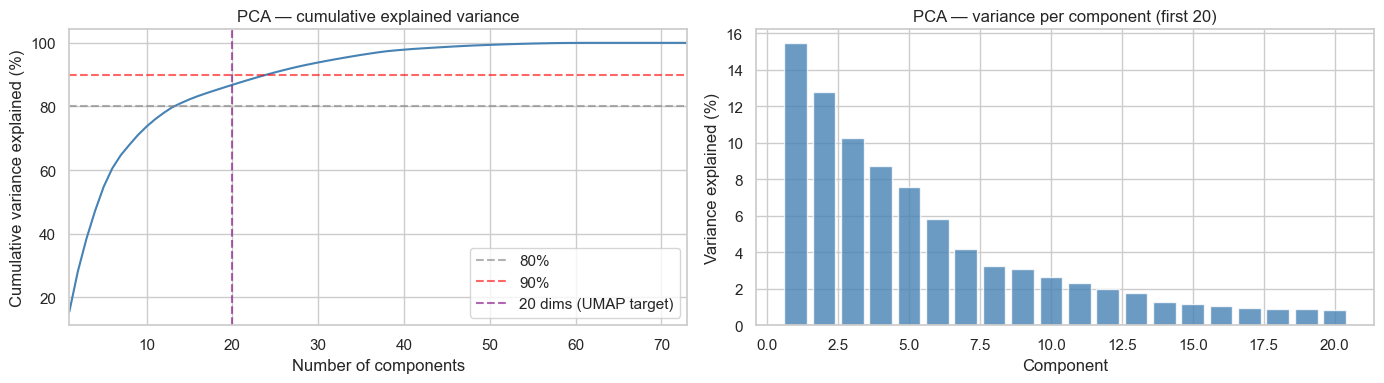


Conclusion: 2D PCA explains only 28.2% — linear projection


In [43]:
# PCA baseline
# Provides linear reference before UMAP; motivates nonlinear reduction
pca_full = PCA(random_state=GLOBAL_SEED)  # full PCA (keep all components)
pca_full.fit(X_R0)  # fit PCA on full 73D matrix (no transform needed — we only need explained_variance_ratio_)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)  # cumulative variance explained by first n components

print('PCA variance explained:')  # section header for variance explanation table
print(f' 2  components: {cumvar[1]*100:.1f}%  ← too low for clustering')  # 2D is insufficient for clustering
print(f' 20 components: {cumvar[19]*100:.1f}%')  # variance captured by UMAP-20D target
print(f' 30 components: {cumvar[29]*100:.1f}%')  # variance at 30 components
print(f' 50 components: {cumvar[49]*100:.1f}%')  # variance at 50 components
print(f' Components to reach 80%: {int(np.searchsorted(cumvar, 0.80))+1}')  # how many components for 80% variance
print(f' Components to reach 90%: {int(np.searchsorted(cumvar, 0.90))+1}')  # how many for 90%

fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # two-panel: cumulative variance curve + scree plot
axes[0].plot(range(1, len(cumvar)+1), cumvar*100, color='steelblue')  # cumulative variance curve
axes[0].axhline(80, ls='--', color='grey', alpha=0.6, label='80%')  # horizontal reference line at 80% explained variance
axes[0].axhline(90, ls='--', color='red', alpha=0.6, label='90%')  # horizontal reference line at 90% explained variance
axes[0].axvline(20, ls='--', color='purple', alpha=0.6, label='20 dims (UMAP target)')  # mark UMAP-20D target
axes[0].set_xlabel('Number of components')  # label x-axis for cumulative variance panel
axes[0].set_ylabel('Cumulative variance explained (%)')  # label y-axis for cumulative variance panel
axes[0].set_title('PCA — cumulative explained variance')  # title for cumulative variance panel
axes[0].legend(); axes[0].set_xlim(1, 73)  # show legend and set x-axis range to 1-73 components

axes[1].bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100,  # variance per component (scree plot)
            color='steelblue', alpha=0.8)  # scree bar chart colour
axes[1].set_xlabel('Component')  # label x-axis for scree plot panel
axes[1].set_ylabel('Variance explained (%)')  # label y-axis for scree plot panel
axes[1].set_title('PCA — variance per component (first 20)')  # title for scree plot panel
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/pca_explained_variance.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

print(f'\nConclusion: 2D PCA explains only {cumvar[1]*100:.1f}% — linear projection')  # print interpretation: 2D PCA is insufficient
#is insufficient, Nonlinear UMAP-20D captures more structure for downstream clustering


In [44]:
# UMAP-20D — fit on subsample, transform full dataset
# n_components=20: "more for downstream features"
UMAP_SUBSAMPLE = 30_000  # 30k subsample: UMAP fit is O(n log n) — feasible; larger = better representation
np.random.seed(GLOBAL_SEED)  # fix random seed for reproducibility
umap_idx  = np.random.choice(len(X_R0), size=UMAP_SUBSAMPLE, replace=False)  # random subsample indices
X_umap_in = X_R0[umap_idx]  # subsample to fit UMAP on

print(f'Fitting UMAP 20D on subsample n={UMAP_SUBSAMPLE:,} (seed={GLOBAL_SEED})...')  # progress message before slow UMAP fit
t0 = time.time()  # start timer
reducer_20d = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=20,  # n_neighbors=30: chosen by sensitivity sweep; n_components=20: downstream features
                         metric='euclidean', random_state=GLOBAL_SEED,  # Euclidean metric in StandardScaler space; fixed seed
                         verbose=False, low_memory=True)  # low_memory=True: reduces RAM usage for large datasets
X_umap20_sub = reducer_20d.fit_transform(X_umap_in)  # fit and transform subsample with shape (30000, 20)
umap20_rt    = time.time() - t0  # elapsed time in seconds for UMAP fit
print(f'UMAP 20D done in {umap20_rt:.1f}s | shape: {X_umap20_sub.shape}')  # confirm UMAP fit completed and show output shape

X_umap20 = reducer_20d.transform(X_R0)  # transform full 119,210 rows using fitted UMAP (no refit)
print(f'Full dataset projected: {X_umap20.shape}')  # (119210, 20)


Fitting UMAP 20D on subsample n=30,000 (seed=42)...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP 20D done in 37.4s | shape: (30000, 20)
Full dataset projected: (119210, 20)


In [45]:
# Trustworthiness do UMAP-20D
np.random.seed(GLOBAL_SEED)
tw_idx = np.random.choice(len(X_R0), size=3000, replace=False)
tw_umap20 = trustworthiness(X_R0[tw_idx], X_umap20[tw_idx], n_neighbors=10)
print(f'UMAP-20D trustworthiness (k=10, n=3000) = {tw_umap20:.4f}')
print(f'Proportion of 10-nearest neighbours in R0 (73D) preserved in UMAP-20D')
print(f' Values > 0.90 indicate good local structure preservation.')

UMAP-20D trustworthiness (k=10, n=3000) = 0.9482
Proportion of 10-nearest neighbours in R0 (73D) preserved in UMAP-20D
 Values > 0.90 indicate good local structure preservation.


In [46]:
#UMAP hyperparameter sensitivity of T11 slide 25
#We test the two most impactful parameters: n_neighbors and min_dist
#Using subsample of 10k for speed; both affect downstream clustering quality

np.random.seed(GLOBAL_SEED)  # fix random seed for reproducibility
sens_idx = np.random.choice(len(X_R0), size=10_000, replace=False)  # 10k subsample indices for sensitivity sweep (speed)
X_sens = X_R0[sens_idx]  # sensitivity subsample

print('UMAP sensitivity — n_neighbors (min_dist=0.1 fixed):')  # section header: n_neighbors sweep
umap_nn_rows = []  # collect n_neighbors sensitivity results
lbl_nn_ref = None  # reference labels (nn=10) for ARI comparison; set on first iteration
for nn in [10, 20, 30, 50]:  # test 4 n_neighbors values with min_dist=0.1 fixed
    r_nn = umap.UMAP(n_neighbors=nn, min_dist=0.1, n_components=20,  # build UMAP with this n_neighbors
                      metric='euclidean', random_state=GLOBAL_SEED, verbose=False)  # UMAP settings: Euclidean metric, fixed seed
    X_nn = r_nn.fit_transform(X_sens)  # project subsample into 20D UMAP space
    km_nn = KMeans(n_clusters=BEST_K, init='k-means++', n_init=5, random_state=GLOBAL_SEED)  # K-Means on UMAP embedding for this n_neighbors
    lbl_nn = km_nn.fit_predict(X_nn)  # cluster labels in UMAP space
    sil_nn = silhouette_score(X_nn, lbl_nn, sample_size=3000, random_state=GLOBAL_SEED)  # Silhouette in UMAP space for this n_neighbors
    if lbl_nn_ref is None:  # first iteration: store as reference; ARI=1.0 by definition
        lbl_nn_ref = lbl_nn; ari_nn = 1.0  # set reference labels and ARI=1.0 for baseline
    else:  # subsequent iterations: compute ARI vs reference partition
        ari_nn = adjusted_rand_score(lbl_nn_ref, lbl_nn)  # ARI vs reference partition (nn=10)
    umap_nn_rows.append({'n_neighbors': nn, 'silhouette_umap': round(sil_nn, 4),  # store n_neighbors sensitivity result
                          'ARI_vs_nn10': round(ari_nn, 4)})
    print(f' n_neighbors={nn:>2}  Sil={sil_nn:.4f}  ARI_vs_nn10={ari_nn:.4f}')  # print one row of the sensitivity table

df_umap_nn = pd.DataFrame(umap_nn_rows)  # assemble n_neighbors sensitivity table
display(df_umap_nn)  # render table in notebook output
df_umap_nn.to_csv('tables/umap_sensitivity_n_neighbors.csv', index=False)  # save to tables/ for report

print()  # blank line separator in output
print('UMAP sensitivity — min_dist (n_neighbors=30 fixed):')  # section header: min_dist sweep
umap_md_rows = []  # collect min_dist sensitivity results
lbl_md_ref = None  # reference labels (min_dist=0.0) for ARI comparison
for md_val in [0.0, 0.05, 0.1, 0.5]:  # test 4 min_dist values with n_neighbors=30 fixed
    r_md = umap.UMAP(n_neighbors=30, min_dist=md_val, n_components=20,  # build UMAP with this min_dist
                       metric='euclidean', random_state=GLOBAL_SEED, verbose=False)  # UMAP settings: Euclidean metric, fixed seed
    X_md = r_md.fit_transform(X_sens)  # project subsample into 20D UMAP space
    km_md = KMeans(n_clusters=BEST_K, init='k-means++', n_init=5, random_state=GLOBAL_SEED)  # K-Means on UMAP embedding for this min_dist
    lbl_md = km_md.fit_predict(X_md)  # cluster labels in UMAP space
    sil_md = silhouette_score(X_md, lbl_md, sample_size=3000, random_state=GLOBAL_SEED)  # Silhouette in UMAP space for this min_dist
    if lbl_md_ref is None:  # first min_dist iteration: store as reference; ARI=1.0
        lbl_md_ref = lbl_md; ari_md = 1.0  # set reference labels and ARI=1.0 for baseline
    else:  # subsequent iterations: compute ARI vs reference partition
        ari_md = adjusted_rand_score(lbl_md_ref, lbl_md)  # ARI vs reference partition (min_dist=0.0)
    umap_md_rows.append({'min_dist': md_val, 'silhouette_umap': round(sil_md, 4),  # store min_dist sensitivity result
                          'ARI_vs_0.0': round(ari_md, 4)})
    print(f' min_dist={md_val} Sil={sil_md:.4f} ARI_vs_0.0={ari_md:.4f}')  # print one row of the sensitivity table

df_umap_md = pd.DataFrame(umap_md_rows)  # assemble min_dist sensitivity table
display(df_umap_md)  # render table in notebook output
df_umap_md.to_csv('tables/umap_sensitivity_min_dist.csv', index=False)  # save to tables/ for report

# Interpretation
print('\nInterpretation:')  # section header for sensitivity interpretation
sil_range_nn = df_umap_nn['silhouette_umap'].max() - df_umap_nn['silhouette_umap'].min()  # Silhouette range across n_neighbors values
sil_range_md = df_umap_md['silhouette_umap'].max() - df_umap_md['silhouette_umap'].min()  # Silhouette range across min_dist values
ari_min_nn = df_umap_nn['ARI_vs_nn10'].min()  # minimum ARI across n_neighbors values
ari_min_md = df_umap_md['ARI_vs_0.0'].min()  # minimum ARI across min_dist values
print(f' n_neighbors: Sil range={sil_range_nn:.4f}, min ARI={ari_min_nn:.4f}')  # print n_neighbors sensitivity summary
print(f' min_dist: Sil range={sil_range_md:.4f}, min ARI={ari_min_md:.4f}')  # print min_dist sensitivity summary

    #if ari_min < 0.5 param substantially changes partition
    # if ari_min < 0.8: Moderate sensitivity to param, report as limitation.
    #Partition robust to param.

#Silhouette inflation at min_dist=0.0 confirms metrics in UMAP space
#are geometry-dependent and not directly comparable to 73D values

UMAP sensitivity — n_neighbors (min_dist=0.1 fixed):
 n_neighbors=10  Sil=0.4355  ARI_vs_nn10=1.0000
 n_neighbors=20  Sil=0.4955  ARI_vs_nn10=0.7086
 n_neighbors=30  Sil=0.5121  ARI_vs_nn10=0.7071
 n_neighbors=50  Sil=0.5598  ARI_vs_nn10=0.8297


,n_neighbors,silhouette_umap,ARI_vs_nn10
0,10,0.4355,1.0000
1,20,0.4955,0.7086
2,30,0.5121,0.7071
3,50,0.5598,0.8297



UMAP sensitivity — min_dist (n_neighbors=30 fixed):
 min_dist=0.0 Sil=0.5855 ARI_vs_0.0=1.0000
 min_dist=0.05 Sil=0.5219 ARI_vs_0.0=0.8307
 min_dist=0.1 Sil=0.5121 ARI_vs_0.0=0.9699
 min_dist=0.5 Sil=0.3700 ARI_vs_0.0=0.8367


,min_dist,silhouette_umap,ARI_vs_0.0
0,0.00,0.5855,1.0000
1,0.05,0.5219,0.8307
2,0.10,0.5121,0.9699
3,0.50,0.3700,0.8367



Interpretation:
 n_neighbors: Sil range=0.1243, min ARI=0.7071
 min_dist: Sil range=0.2155, min ARI=0.8307


In [47]:
# K-Means on UMAP-20D
# Metrics computed in UMAP space — not comparable to 73D (different geometry)
results_km_umap = []  # collect sweep results
for k in K_RANGE:  # sweep k=2..8 in UMAP-20D space
    km_u = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=GLOBAL_SEED)  # K-Means in UMAP-20D space for this k
    lbl_u = km_u.fit_predict(X_umap20)  # cluster in 20D UMAP space
    sil_u = silhouette_score(X_umap20, lbl_u, sample_size=5000, random_state=GLOBAL_SEED)  # Silhouette in UMAP space (NOT comparable to 73D)
    ch_u = calinski_harabasz_score(X_umap20, lbl_u)  # CH in UMAP space
    db_u = davies_bouldin_score(X_umap20, lbl_u)  # DB in UMAP space
    results_km_umap.append({'k': k, 'silhouette': sil_u,  # store UMAP-20D sweep metrics for this k
                             'calinski_harabasz': ch_u, 'davies_bouldin': db_u})
    print(f'k={k} Sil={sil_u:.4f} CH={ch_u:.1f} DB={db_u:.4f}')  # print one row of UMAP-20D sweep table

df_km_umap = pd.DataFrame(results_km_umap)  # assemble UMAP-20D sweep table
BEST_K_UMAP = int(df_km_umap.loc[df_km_umap.silhouette.idxmax(), 'k'])  # select k by Silhouette in UMAP space
km_umap_final = KMeans(n_clusters=BEST_K_UMAP, init='k-means++', n_init=10,  # refit best model
                        random_state=GLOBAL_SEED)  # fixed seed for final UMAP-20D K-Means
labels_km_umap = km_umap_final.fit_predict(X_umap20)  # final UMAP-20D cluster labels
sil_umap_final = silhouette_score(X_umap20, labels_km_umap,  # Silhouette on final UMAP-20D labels
                                    sample_size=5000, random_state=GLOBAL_SEED)  # final Silhouette
ch_umap_final = calinski_harabasz_score(X_umap20, labels_km_umap)  # final CH
db_umap_final = davies_bouldin_score(X_umap20, labels_km_umap)  # final DB
print(f'\nK-Means UMAP-20D (k={BEST_K_UMAP}) → Sil={sil_umap_final:.4f}  '  # print final UMAP-20D K-Means quality
      f'CH={ch_umap_final:.1f}  DB={db_umap_final:.4f}')  # continuation: print CH and DB

ari_73d_umap = adjusted_rand_score(labels_km, labels_km_umap)  # ARI between 73D and UMAP-20D partitions
print(f'ARI(K-Means 73D k={BEST_K} vs UMAP-20D k={BEST_K_UMAP}) = {ari_73d_umap:.4f}')  # print partition agreement between 73D and UMAP-20D K-Means
#if ari_73d_umap < 0.5-Partitions differ substantially: UMAP reveals different structure than 73D
#Both solutions are valid — they capture different aspects of the data geometry
# if ari_73d_umap < 0.8-Moderate overlap: UMAP captures similar but not identical structure to 73D
#if its over 0.8we have High overlap: UMAP confirms the 73D partition with better-defined geometry

# Stability — 5 seeds
print('\nK-Means UMAP-20D stability:')  # section header for UMAP-20D K-Means stability sweep
km_umap_stab_rows, km_umap_stab_labels = [], []  # collect stability metrics and labels per seed
for seed in SEEDS:  # iterate seeds
    km_u_s  = KMeans(n_clusters=BEST_K_UMAP, init='k-means++',  # K-Means with UMAP-20D best k, different seed
                     n_init=10, random_state=seed)  # refit with different seed
    lbl_u_s = km_u_s.fit_predict(X_umap20)  # labels for this seed
    sil_u_s = silhouette_score(X_umap20, lbl_u_s, sample_size=5000, random_state=seed)  # Silhouette for this stability seed
    ch_u_s = calinski_harabasz_score(X_umap20, lbl_u_s)  # CH for this stability seed
    db_u_s = davies_bouldin_score(X_umap20, lbl_u_s)  # DB for this stability seed
    km_umap_stab_rows.append({'seed': seed, 'silhouette': sil_u_s,  # store UMAP-20D stability result for this seed
                               'calinski_harabasz': ch_u_s, 'davies_bouldin': db_u_s})
    km_umap_stab_labels.append(lbl_u_s)  # store labels for ARI computation

df_km_umap_stab = pd.DataFrame(km_umap_stab_rows)  # assemble UMAP-20D stability table
display(df_km_umap_stab.round(4))  # render table in notebook output
print(df_km_umap_stab[['silhouette','calinski_harabasz',  # print mean and std of stability metrics
                         'davies_bouldin']].agg(['mean','std']).round(4))
ari_km_umap_stab = [adjusted_rand_score(km_umap_stab_labels[i], km_umap_stab_labels[i+1])  # ARI between consecutive seed pairs for stability
                    for i in range(len(SEEDS)-1)]  # ARI between consecutive seeds
print(f'\nK-Means UMAP-20D mean ARI (consecutive seeds) = {np.mean(ari_km_umap_stab):.4f}')  # print final UMAP-20D K-Means quality
print(f'(vs K-Means 73D ARI= {np.mean(ari_km):.4f})')  # comparison: UMAP-20D typically more stable
df_km_umap_stab.to_csv('tables/kmeans_umap20d_stability.csv', index=False)  # save stability table


k=2 Sil=0.3330 CH=30331.3 DB=1.5261
k=3 Sil=0.3620 CH=28150.6 DB=1.2866
k=4 Sil=0.3856 CH=26379.5 DB=1.3843
k=5 Sil=0.3666 CH=26960.4 DB=1.1613
k=6 Sil=0.3930 CH=25160.2 DB=1.4747
k=7 Sil=0.3637 CH=22646.1 DB=1.2965
k=8 Sil=0.3741 CH=21304.0 DB=1.2992

K-Means UMAP-20D (k=6) → Sil=0.3930  CH=25160.2  DB=1.4747
ARI(K-Means 73D k=7 vs UMAP-20D k=6) = 0.1219

K-Means UMAP-20D stability:


,seed,silhouette,calinski_harabasz,davies_bouldin
0,42,0.3930,25160.1570,1.4747
1,7,0.3982,25141.9733,1.4640
2,13,0.4033,25442.7525,1.3435
3,99,0.4048,25161.0868,1.4721
4,2025,0.4107,25431.4042,1.4162
5,2024,0.3130,22945.7936,1.2178
6,2004,0.4107,25429.0926,1.4194
7,2005,0.3890,25489.9822,1.3910
8,2020,0.3970,25484.1176,1.3710
9,100,0.3836,24063.7251,1.4432


      silhouette  calinski_harabasz  davies_bouldin
mean      0.3908         24990.8457          1.4097
std       0.0272           789.3153          0.0790

K-Means UMAP-20D mean ARI (consecutive seeds) = 0.9225
(vs K-Means 73D ARI= 0.8229)


In [48]:
# Comparação: K-Means no PCA-20D vs K-Means no UMAP-20D
pca_20 = PCA(n_components=20, random_state=GLOBAL_SEED)
X_pca20 = pca_20.fit_transform(X_R0)
km_pca20 = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)
lbl_pca20 = km_pca20.fit_predict(X_pca20)
sil_pca20 = silhouette_score(X_pca20, lbl_pca20, sample_size=5000, random_state=GLOBAL_SEED)
ari_pca20_umap = adjusted_rand_score(lbl_pca20, labels_km_umap)
print(f'K-Means PCA-20D  → Sil={sil_pca20:.4f}')
print(f'K-Means UMAP-20D → Sil={sil_umap_final:.4f}')
print(f'ARI(PCA-20D vs UMAP-20D) = {ari_pca20_umap:.4f}')

K-Means PCA-20D  → Sil=0.1655
K-Means UMAP-20D → Sil=0.3930
ARI(PCA-20D vs UMAP-20D) = 0.1216


K-Means UMAP-20D (k=6) — cluster sizes:


cluster_umap
0    44144
1    29433
2    17373
3    13829
4     4227
5    10204
Name: n, dtype: int64

Ratio max/min: 10.44

Numerical profile:


lead_time        total_nights        party_size         \
                  mean median         mean median       mean median   
cluster_umap                                                          
0                88.78   64.0         3.21    3.0       2.03    2.0   
1               109.21   79.0         4.70    4.0       2.18    2.0   
2                51.99   16.0         2.87    2.0       1.88    2.0   
3               146.79  112.0         2.66    3.0       1.71    2.0   
4               251.91  277.0         2.43    2.0       1.90    2.0   
5               125.36   94.0         3.05    2.0       1.66    2.0   

             previous_cancellations        previous_bookings_not_canceled  \
                               mean median                           mean   
cluster_umap                                                                
0                              0.01    0.0                           0.00   
1                              0.04    0.0                           0.00   
2                              0.01    0.0                           0.01   
3                              0.27    0.0                           0.00   
4                              0.24    0.0                           0.00   
5                              0.36    0.0                           1.57   

                    total_of_special_requests         \
             median                      mean median   
cluster_umap                                           
0               0.0                      0.77    1.0   
1               0.0                      0.72    1.0   
2               0.0                      0.42    0.0   
3               0.0                      0.19    0.0   
4               0.0                      0.00    0.0   
5               0.0                      0.30    0.0   

             required_car_parking_spaces         
                                    mean median  
cluster_umap                                     
0                                   0.02    0.0  
1                                   0.11    0.0  
2                                   0.13    0.0  
3                                   0.00    0.0  
4                                   0.00    0.0  
5                                   0.08    0.0


 hotel (% within cluster)


...

country_grouped,AUT,BEL,BRA,CHE,CN,DEU,ESP,FRA,GBR,IRL,ITA,NLD,Other,PRT,SWE,USA
cluster_umap,,,,,,,,,,,,,,,,
0,1.6,3.4,3.2,2.5,1.0,9.4,7.1,14.7,9.9,2.3,5.2,3.0,13.6,19.6,1.2,2.5
1,0.5,1.2,1.4,1.3,1.9,3.4,10.6,4.6,17.4,5.5,1.5,1.4,7.6,39.4,0.8,1.5
2,0.7,2.1,1.3,1.3,0.7,2.8,6.8,6.7,7.7,2.7,1.9,1.4,8.1,53.0,0.6,2.1
3,1.7,0.5,1.0,0.2,0.6,8.6,4.6,8.7,2.3,0.4,4.7,0.5,8.2,56.0,0.8,1.4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,99.7,0.0,0.0
5,0.5,0.5,0.1,0.1,0.8,4.4,5.1,2.1,9.6,2.2,0.5,0.4,3.7,69.5,0.4,0.1



Post-hoc variables (not used in clustering):


is_canceled             adr         booking_changes       
                    mean median     mean  median            mean median
cluster_umap                                                           
0                  0.374    0.0  111.033  107.00           0.167    0.0
1                  0.371    0.0  107.330   90.10           0.201    0.0
2                  0.187    0.0  100.785   90.00           0.385    0.0
3                  0.349    0.0   88.932   87.00           0.249    0.0
4                  0.997    1.0   87.453   75.00           0.007    0.0
5                  0.440    0.0   72.992   69.36           0.259    0.0


Cancellation rate per cluster:


cluster_umap
0    0.374
1    0.371
2    0.187
3    0.349
4    0.997
5    0.440
Name: cancel_rate, dtype: float64

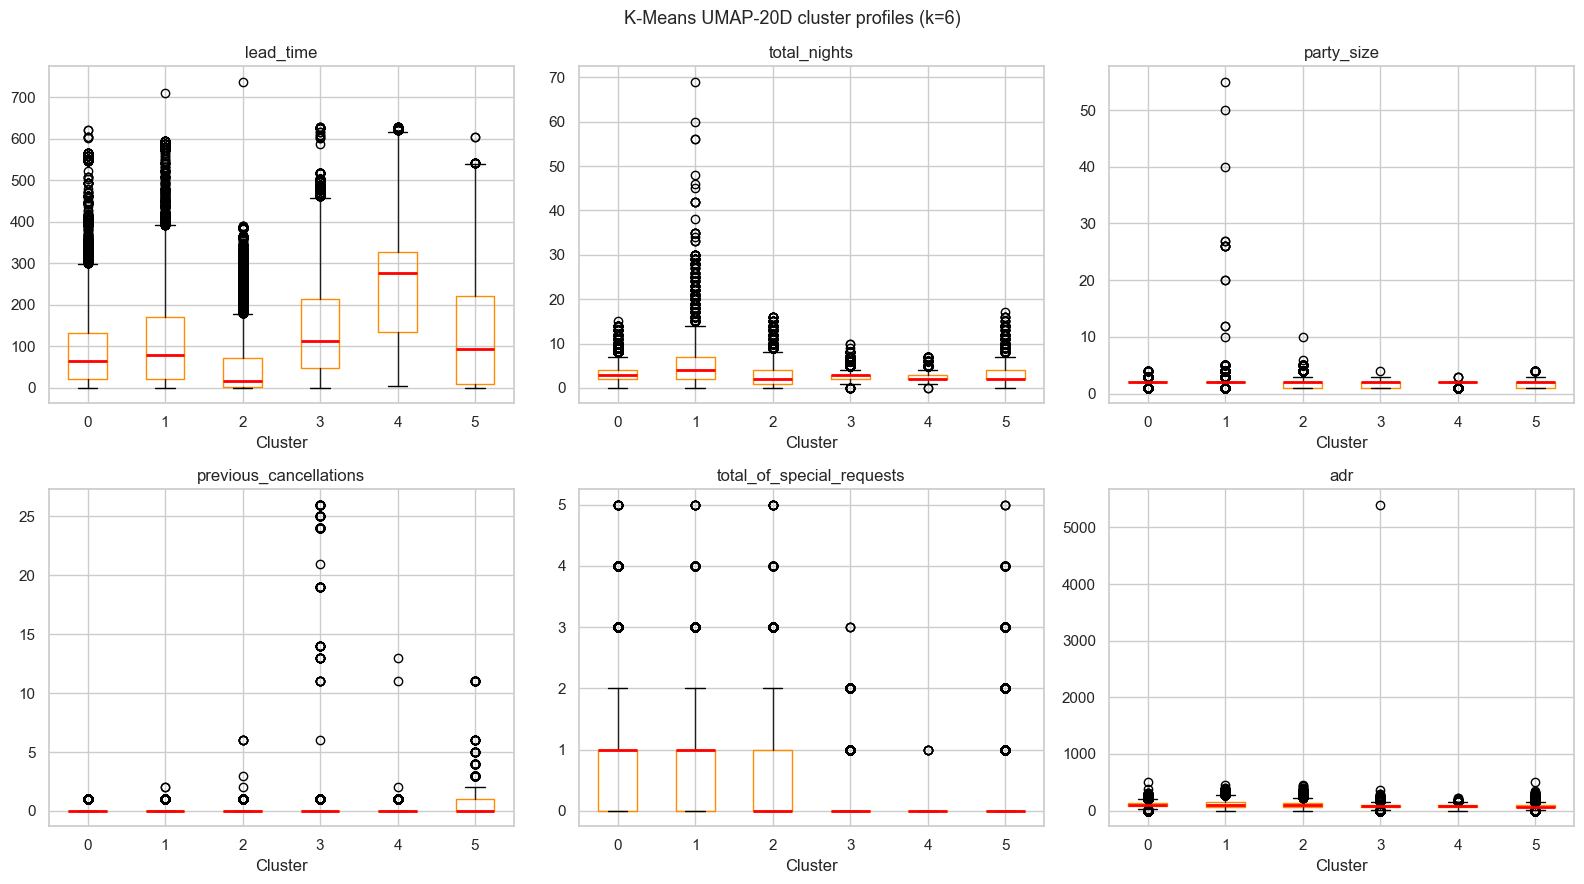


Comparison: K-Means 73D vs K-Means UMAP-20D — mean cancellation rate per cluster:


,cancel_73D,cancel_UMAP20D
0,0.328,0.374
1,0.131,0.371
2,0.056,0.187
3,0.990,0.349
4,0.512,0.997
5,0.411,0.440
6,0.241,NaN



Comparison: mean lead time per cluster:


,lead_time_73D,lead_time_UMAP20D
0,139.5,88.8
1,5.7,109.2
2,14.6,52.0
3,213.6,146.8
4,148.0,251.9
5,88.3,125.4
6,85.2,NaN



ARI(K-Means 73D vs K-Means UMAP-20D) = 0.1219


In [49]:
# K-Means UMAP-20D cluster profiling
# Labels: labels_km_umap | k: BEST_K_UMAP
# Post-hoc variables (adr, is_canceled) NOT used to form clusters

df_umap_prof = df2.copy()  # working copy of cleaned data for UMAP-20D profiling
df_umap_prof['cluster_umap'] = labels_km_umap  # attach UMAP-20D K-Means labels to profiling dataframe
CL_U ='cluster_umap'  # column name shorthand for UMAP-20D cluster labels

print(f'K-Means UMAP-20D (k={BEST_K_UMAP}) — cluster sizes:')  # print UMAP-20D cluster sizes
sizes_umap = df_umap_prof[CL_U].value_counts().sort_index().rename('n')  # count bookings per UMAP-20D cluster
display(sizes_umap)  # render table in notebook output
print(f'Ratio max/min: {sizes_umap.max()/sizes_umap.min():.2f}')  # print size imbalance ratio

# Numerical profile
num_cols_u = ['lead_time','total_nights','party_size','previous_cancellations',  # numerical columns to profile in UMAP-20D space
              'previous_bookings_not_canceled','total_of_special_requests',
              'required_car_parking_spaces']
prof_num_umap = df_umap_prof.groupby(CL_U)[num_cols_u].agg(['mean','median']).round(2)  # compute mean and median per UMAP-20D cluster for numerical features
print('\nNumerical profile:')  # section header for numerical feature profile table
display(prof_num_umap)  # render table in notebook output

# Categorical profile
print()  # blank line separator in output
for col in ['hotel','market_segment','deposit_type','customer_type','country_grouped']:  # loop over categorical variables for cross-tab profiling
    ct = pd.crosstab(df_umap_prof[CL_U], df_umap_prof[col], normalize='index') * 100  # cross-tab: % composition of each UMAP-20D cluster per category
    print(f' {col} (% within cluster)')  # section header for this categorical variable
    display(ct.round(1))  # render table in notebook output

# Post-hoc variables — leakage check
posthoc_u = ['is_canceled','adr','booking_changes']  # post-hoc variables: not used to form clusters — inspect as validation
print('\nPost-hoc variables (not used in clustering):')  # section header for post-hoc variable table
display(df_umap_prof.groupby(CL_U)[posthoc_u].agg(['mean','median']).round(3))  # render table in notebook output
print('\nCancellation rate per cluster:')  # section header for UMAP-20D cancellation rates
display(df_umap_prof.groupby(CL_U)['is_canceled'].mean().rename('cancel_rate').round(3))  # render table in notebook output

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))  # 2×3 grid of boxplots: one per numerical variable
for ax, col in zip(axes.flat, ['lead_time','total_nights','party_size',  # loop: one boxplot per variable across UMAP-20D clusters
                                'previous_cancellations',
                                'total_of_special_requests','adr']):
    df_umap_prof.boxplot(column=col, by=CL_U, ax=ax,  # draw boxplot for this variable grouped by UMAP-20D cluster
                         boxprops=dict(color='darkorange'),  # UMAP-20D cluster boxplot colour
                         medianprops=dict(color='red', linewidth=2))  # median line style for boxplots
    ax.set_title(col); ax.set_xlabel('Cluster')  # set subplot title and x-label
plt.suptitle(f'K-Means UMAP-20D cluster profiles (k={BEST_K_UMAP})', fontsize=13)  # overall figure title
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/profiles_kmeans_umap20d.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

# Comparison with K-Means 73D profiles — same variables side by side
print('\nComparison: K-Means 73D vs K-Means UMAP-20D — mean cancellation rate per cluster:')  # section header for cross-space cancellation rate comparison
cr_73d = df_prof.groupby('cluster_km')['is_canceled'].mean().rename('cancel_73D').round(3)  # cancellation rate per 73D K-Means cluster
cr_umap = df_umap_prof.groupby(CL_U)['is_canceled'].mean().rename('cancel_UMAP20D').round(3)  # cancellation rate per UMAP-20D cluster
display(pd.concat([cr_73d, cr_umap], axis=1))  # render table in notebook output

print('\nComparison: mean lead time per cluster:')  # section header for cross-space lead time comparison
lt_73d = df_prof.groupby('cluster_km')['lead_time'].mean().rename('lead_time_73D').round(1)  # mean lead time per 73D K-Means cluster
lt_umap = df_umap_prof.groupby(CL_U)['lead_time'].mean().rename('lead_time_UMAP20D').round(1)  # mean lead time per UMAP-20D cluster
display(pd.concat([lt_73d, lt_umap], axis=1))  # render table in notebook output

print(f'\nARI(K-Means 73D vs K-Means UMAP-20D) = {ari_73d_umap:.4f}')  # print partition agreement between 73D and UMAP-20D
#if ari_73d_umap < 0.5-Profiles differ substantially — UMAP-20D reveals different segmentation
#Interpret each solution independently
#ari_73d_umap < 0.8-Moderate overlap — similar broad segments, different fine-grained structure
#High overlap — UMAP-20D confirms 73D segmentation with cleaner geometry

prof_num_umap.to_csv('tables/profile_kmeans_umap20d.csv')  # save UMAP-20D numerical profile

Anomaly score UMAP-20D summary:
 Mean: 1.000
 Median: 0.688
 P95: 3.542
 P99: 5.664
 Max: 6.767


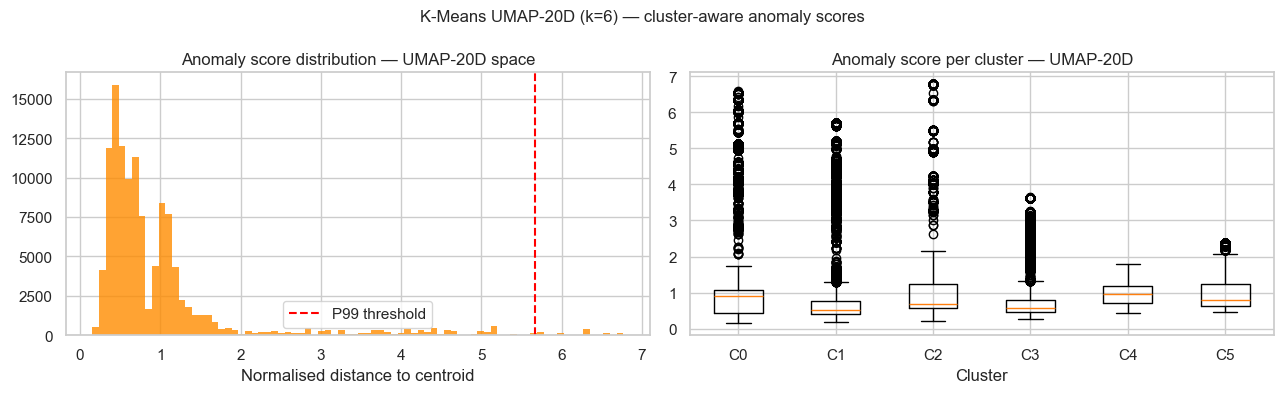


Mean anomaly score per cluster:


,mean,median,max
cluster_umap,,,
0,1.0,0.912,6.579
1,1.0,0.528,5.712
2,1.0,0.686,6.767
3,1.0,0.566,3.636
4,1.0,0.962,1.783
5,1.0,0.795,2.372


,anomaly_rank,anomaly_score_umap,cluster_umap,cluster_73d,anomaly_type,hotel,lead_time,adr,deposit_type,is_canceled
63878,1,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,1
63894,2,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,1
63873,3,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,1
106351,4,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,0
63869,5,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,1
106383,6,6.77,2,4,rare booking pattern,City Hotel,134,0.0,No Deposit,0
106330,7,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,0
63904,8,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,1
63874,9,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,1
106308,10,6.77,2,4,rare booking pattern,City Hotel,134,75.0,No Deposit,0



Top-20 anomaly overlap (73D vs UMAP-20D): 0/20
Jaccard: 0.000
Spearman rank correlation (73D vs UMAP-20D scores): corr73d=0.0261  corrumap20=1.97e-19


In [50]:
# Cluster-aware anomaly detection in UMAP-20D space
# Score: normalised distance to assigned K-Means UMAP-20D centroid
# score_i = dist(x_i, centroid_c) / mean_dist(cluster_c)
# More discriminative than 73D anomaly detection because UMAP-20D clusters
# are more compact (Sil=0.424) — anomalies stand out more clearly.

centroids_umap = km_umap_final.cluster_centers_  # UMAP-20D centroid matrix: shape (BEST_K_UMAP, 20)
dist_umap_centroid = np.linalg.norm(X_umap20 - centroids_umap[labels_km_umap], axis=1)  # Euclidean distance from each booking to its UMAP-20D centroid
cluster_mean_umap = np.array([dist_umap_centroid[labels_km_umap == c].mean()  # mean distance within each UMAP-20D cluster (normalisation factor)
                                for c in range(BEST_K_UMAP)])  # one mean per cluster
anomaly_score_umap = dist_umap_centroid / (cluster_mean_umap[labels_km_umap] + 1e-12)  # normalised score: >1 means farther than cluster average

df_umap_prof['anomaly_score_umap'] = anomaly_score_umap  # attach anomaly scores to profiling dataframe

print('Anomaly score UMAP-20D summary:')  # section header for anomaly score statistics
print(f' Mean: {anomaly_score_umap.mean():.3f}')  # expected ~1.0 by construction
print(f' Median: {np.median(anomaly_score_umap):.3f}')  # median < mean indicates right-skewed distribution
print(f' P95: {np.percentile(anomaly_score_umap, 95):.3f}')  # 95th percentile anomaly score
print(f' P99: {np.percentile(anomaly_score_umap, 99):.3f}')  # P99 threshold used to flag anomalies
print(f' Max: {anomaly_score_umap.max():.3f}')  # most extreme booking in UMAP-20D space

# Distribution and score per cluster
fig, axes = plt.subplots(1, 2, figsize=(13, 4))  # two-panel: score histogram + boxplot per cluster
axes[0].hist(anomaly_score_umap, bins=80, color='darkorange', edgecolor='none', alpha=0.8)  # histogram of all UMAP-20D anomaly scores
axes[0].axvline(np.percentile(anomaly_score_umap, 99), color='red',  # vertical line at P99 detection threshold
                ls='--', label='P99 threshold')  # dashed red line at P99 anomaly threshold
axes[0].set_title('Anomaly score distribution — UMAP-20D space')  # title for score histogram panel
axes[0].set_xlabel('Normalised distance to centroid'); axes[0].legend()  # label x-axis and show legend for score histogram
axes[1].boxplot([anomaly_score_umap[labels_km_umap == c] for c in range(BEST_K_UMAP)],  # one box per UMAP-20D cluster
                labels=[f'C{c}' for c in range(BEST_K_UMAP)])  # one mean per cluster
axes[1].set_title('Anomaly score per cluster — UMAP-20D')  # title for cluster boxplot panel
axes[1].set_xlabel('Cluster')  # label x-axis for cluster boxplot
plt.suptitle(f'K-Means UMAP-20D (k={BEST_K_UMAP}) — cluster-aware anomaly scores',  # overall figure title
             fontsize=12)  # figure suptitle font size
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/anomaly_score_umap20d.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

print('\nMean anomaly score per cluster:')  # section header for per-cluster anomaly score summary
display(df_umap_prof.groupby(CL_U)['anomaly_score_umap'].agg(  # render table in notebook output
    ['mean','median','max']).round(3))  # show mean, median and max anomaly score per cluster

# Top-20 anomalies in UMAP-20D space
TOP_K_ANOM_UMAP = 20  # number of top anomalies to inspect in UMAP-20D space
top20_umap_idx = np.argsort(anomaly_score_umap)[::-1][:TOP_K_ANOM_UMAP]  # indices of 20 most anomalous bookings in UMAP-20D space
key_cols = ['hotel','lead_time','total_nights','party_size',  # columns to display for each anomaly
            'previous_cancellations','previous_bookings_not_canceled',
            'adr','market_segment','deposit_type',
            'customer_type','is_canceled','reservation_status']
df_anom_umap = df_umap_prof.iloc[top20_umap_idx][key_cols].copy()  # subset top-20 rows from profiling dataframe
df_anom_umap.insert(0, 'anomaly_rank', range(1, TOP_K_ANOM_UMAP+1))  # add rank column (1=most anomalous)
df_anom_umap.insert(1, 'anomaly_score_umap', np.round(anomaly_score_umap[top20_umap_idx], 3))  # add UMAP-20D anomaly score
df_anom_umap.insert(2, 'cluster_umap', labels_km_umap[top20_umap_idx])  # add UMAP-20D cluster assignment
df_anom_umap.insert(3, 'cluster_73d', labels_km[top20_umap_idx])  # add 73D cluster assignment for cross-space comparison

#function to classify anomalies
def classify_anomaly_umap(row):
    if row['previous_cancellations'] > 15: return 'rare: serial canceller'
    if row['lead_time'] > 600: return 'rare: extreme lead time'
    if row['adr'] > 1000: return 'rare: extreme price'
    if row['total_nights'] > 30: return 'rare: very long stay'
    if row['deposit_type'] == 'Non Refund' and row['is_canceled'] == 0:
        return 'interesting: non-refund showed up'
    return 'rare booking pattern'

df_anom_umap['anomaly_type'] = df_anom_umap.apply(classify_anomaly_umap, axis=1)  # apply rule-based classifier to each anomaly
display(df_anom_umap[['anomaly_rank','anomaly_score_umap','cluster_umap','cluster_73d',  # render table in notebook output
                       'anomaly_type','hotel','lead_time','adr',
                       'deposit_type','is_canceled']].round(2))
df_anom_umap.to_csv('tables/top20_anomalies_umap20d.csv', index=False)  # save top-20 UMAP-20D anomaly table

# Cross-space comparison: are the same bookings anomalous in both spaces?
top20_73d_set  = set(np.argsort(anomaly_score)[::-1][:TOP_K_ANOM_UMAP])  # top-20 anomaly set from 73D detection
top20_umap_set = set(top20_umap_idx)  # top-20 anomaly set from UMAP-20D detection
overlap = len(top20_73d_set & top20_umap_set)  # number of bookings flagged by BOTH spaces
print(f'\nTop-{TOP_K_ANOM_UMAP} anomaly overlap (73D vs UMAP-20D): {overlap}/{TOP_K_ANOM_UMAP}')  # print overlap count
print(f'Jaccard: {overlap / len(top20_73d_set | top20_umap_set):.3f}')  # print Jaccard similarity: |intersection| / |union|
#if overlap >= 14-Both spaces agree on most anomalies — robust anomaly detection
#overlap >= 8-Partial agreement — each space reveals different anomalies
#UMAP-20D anomalies reflect cluster-specific atypicality in nonlinear space
#higher than8 Low agreement — the two spaces find very different anomalies
#73D anomalies: global outliers in Euclidean OHE space
#UMAP-20D anomalies: local outliers within nonlinear cluster structure

rho_umap, pval_umap = spearmanr(  # rank-correlation of anomaly rankings between 73D and UMAP-20D
    pd.Series(anomaly_score).rank(ascending=False),  # rank 73D anomaly scores descending
    pd.Series(anomaly_score_umap).rank(ascending=False))  # rank UMAP-20D anomaly scores descending
print(f'Spearman rank correlation (73D vs UMAP-20D scores): corr73d={rho_umap:.4f}  corrumap20={pval_umap:.2e}')  # print ρ and p-value for rank correlation

#73D anomaly score = atypical in global Euclidean OHE space
#UMAP-20D anomaly score = atypical within nonlinear cluster structure
#Low overlap = complementary anomaly detection, not contradictory

PCA 2D trustworthiness (linear baseline) = 0.9482
t-SNE done in 20.4s  |  trustworthiness=0.9981
Improvement over PCA 2D: +0.0499
UMAP 2D trustworthiness = 0.9866

Trustworthiness — PCA: 0.9482  |  t-SNE: 0.9981  |  UMAP-2D: 0.9865634303169913


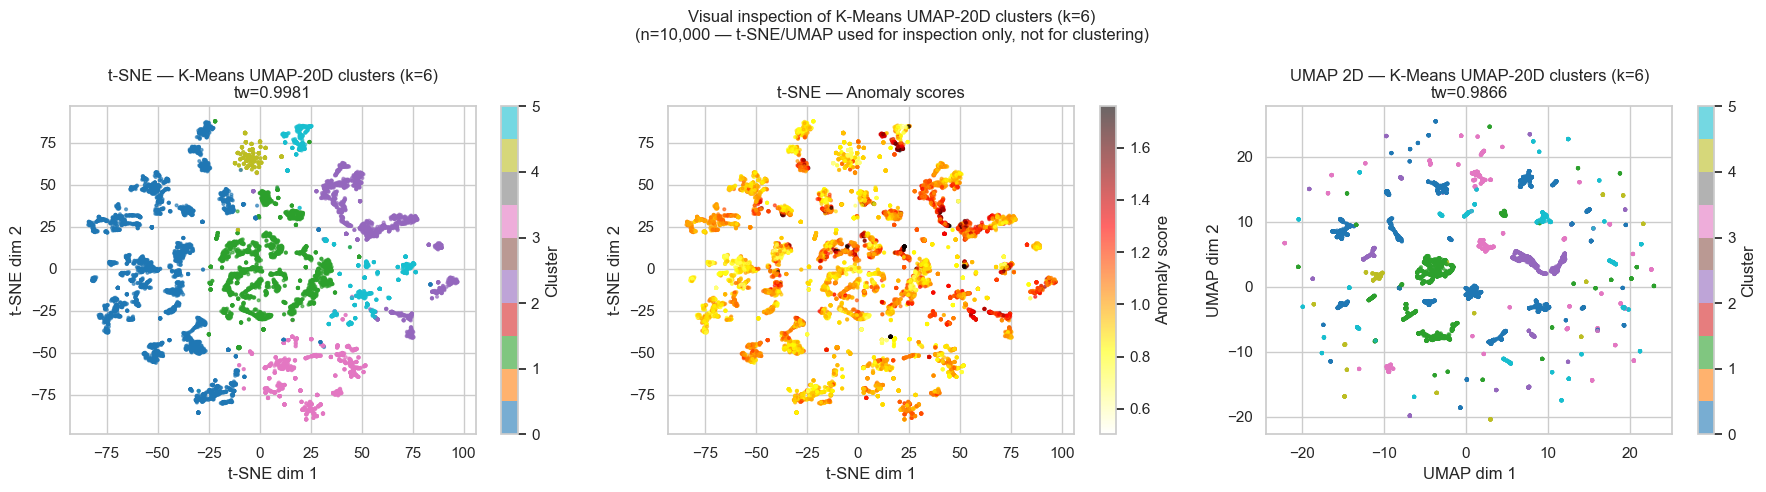

In [51]:
# t-SNE and UMAP-2D — visualisation only (T11 slide 26)
# Input: X_umap20 (the representation used for clustering)
# Clusters shown are formed in UMAP-20D, inspected via 2D projections
SUBSAMPLE_TSNE = 10_000  # 10k subsample: t-SNE is O(n²) — 10k is feasible in reasonable time
np.random.seed(GLOBAL_SEED)  # fix random seed for reproducibility
tsne_idx = np.random.choice(len(X_umap20), size=SUBSAMPLE_TSNE, replace=False)  # 10k random row indices from UMAP-20D matrix
X_tsne_in = X_umap20[tsne_idx].astype(np.float64)  # t-SNE input: 10k × 20 subsample of UMAP-20D representation
lbl_km_tsne = labels_km_umap[tsne_idx]  # UMAP-20D cluster labels for the subsample
anom_tsne = anomaly_score[tsne_idx]  # 73D anomaly scores for the subsample (for colour overlay)

# PCA 2D baseline trustworthiness (linear reference)
pca2 = PCA(n_components=2, random_state=GLOBAL_SEED)  # PCA to 2D — linear baseline for trustworthiness comparison
X_pca2 = pca2.fit_transform(X_tsne_in)  # 2D PCA projection of the subsample
tw_pca = trustworthiness(X_tsne_in, X_pca2, n_neighbors=10)  # trustworthiness of PCA-2D (linear baseline)
print(f'PCA 2D trustworthiness (linear baseline) = {tw_pca:.4f}')  # print PCA-2D baseline trustworthiness

# t-SNE
t0 = time.time()  # start timer
tsne = TSNE(n_components=2, perplexity=40, init='pca', learning_rate='auto',  # t-SNE: 2D nonlinear projection; perplexity=40 (T11 default)
               max_iter=1000, random_state=GLOBAL_SEED, n_jobs=1)  # 1000 iterations for convergence; n_jobs=1 for reproducibility
X_2d = tsne.fit_transform(X_tsne_in)  # fit and project t-SNE
tsne_rt = time.time() - t0  # elapsed time for t-SNE fit in seconds
tw = trustworthiness(X_tsne_in, X_2d, n_neighbors=10)  # trustworthiness of t-SNE-2D: fraction of 10-NN preserved
print(f't-SNE done in {tsne_rt:.1f}s  |  trustworthiness={tw:.4f}')  # print t-SNE runtime and trustworthiness
print(f'Improvement over PCA 2D: {tw - tw_pca:+.4f}')  # positive = t-SNE better than linear PCA at preserving neighbourhoods

# UMAP 2D
try:  # attempt UMAP-2D projection — may fail on memory-constrained machines
    r2d = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2,  # UMAP to 2D for visual comparison with t-SNE
                            metric='euclidean', random_state=GLOBAL_SEED, verbose=False)  # UMAP-2D settings: same params as UMAP-20D
    X_umap2d = r2d.fit_transform(X_tsne_in)  # fit and project UMAP-2D
    tw_umap_2d = trustworthiness(X_tsne_in, X_umap2d, n_neighbors=10)  # trustworthiness of UMAP-2D
    print(f'UMAP 2D trustworthiness = {tw_umap_2d:.4f}')  # print UMAP-2D trustworthiness
except Exception as e:  # catch any UMAP-2D error and continue gracefully
    X_umap2d = None; tw_umap_2d = None  # fallback if UMAP-2D fails (e.g. memory error)
    print(f'UMAP 2D skipped: {e}')  # report why UMAP-2D was skipped

print(f'\nTrustworthiness — PCA: {tw_pca:.4f}  |  t-SNE: {tw:.4f}  |  UMAP-2D: {tw_umap_2d}')  # print all three trustworthiness values side by side

# 3-panel figure: K-Means clusters, anomaly scores, UMAP-2D
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # three-panel: cluster colours, anomaly scores, UMAP-2D

sc0 = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=lbl_km_tsne,cmap='tab10', s=4, alpha=0.6)  # t-SNE coloured by UMAP-20D cluster assignment
axes[0].set_title(f't-SNE — K-Means UMAP-20D clusters (k={BEST_K_UMAP})\ntw={tw:.4f}')  # title for t-SNE cluster panel
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')  # label axes for t-SNE panel
plt.colorbar(sc0, ax=axes[0], label='Cluster')  # colour bar showing cluster index

sc1 = axes[1].scatter(X_2d[:,0], X_2d[:,1], c=anom_tsne, cmap='hot_r',  # t-SNE coloured by 73D anomaly score
                       s=4, alpha=0.6, vmax=np.percentile(anom_tsne, 99))  # clip colour scale at P99 to avoid extreme values washing out structure
axes[1].set_title('t-SNE — Anomaly scores')  # title for anomaly overlay panel
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')  # label axes for anomaly panel
plt.colorbar(sc1, ax=axes[1], label='Anomaly score')  # colour bar showing anomaly score magnitude

if X_umap2d is not None:  # only draw UMAP-2D panel if projection succeeded
    sc2 = axes[2].scatter(X_umap2d[:,0], X_umap2d[:,1], c=lbl_km_tsne,  # UMAP-2D coloured by cluster assignment
                           cmap='tab10', s=4, alpha=0.6)  # UMAP-2D scatter: coloured by cluster, small points
    axes[2].set_title(f'UMAP 2D — K-Means UMAP-20D clusters (k={BEST_K_UMAP})\n'  # title for UMAP-2D panel
                      f'tw={tw_umap_2d:.4f}')  # continuation: add trustworthiness to UMAP-2D panel title
    axes[2].set_xlabel('UMAP dim 1'); axes[2].set_ylabel('UMAP dim 2')  # label axes for UMAP-2D panel
    plt.colorbar(sc2, ax=axes[2], label='Cluster')  # colour bar for UMAP-2D panel
else:  # UMAP-2D failed — hide the third panel
    axes[2].set_visible(False)  # hide UMAP-2D panel if UMAP-2D failed

plt.suptitle(f'Visual inspection of K-Means UMAP-20D clusters (k={BEST_K_UMAP})\n'  # overall figure title
             f'(n={SUBSAMPLE_TSNE:,} — t-SNE/UMAP used for inspection only, '  # suptitle continuation: clarify these are inspection tools
             f'not for clustering)', fontsize=12)  # suptitle continuation: clusters were formed in 20D not 2D
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/tsne_umap_inspection.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

,method,space,k,silhouette,calinski_harabasz,davies_bouldin
0,K-Means 73D (k=7),73D,7,0.1333,12082.8667,1.7578
1,iK-Means 73D (k=3),73D,3,0.1021,12214.2172,2.4358
2,Ward 73D (k=2),73D,2,0.4496,11088.2645,1.1888
3,GMM 73D (k=2),73D,2,0.0257,2630.9217,6.2215
4,K-Means UMAP-20D (k=6),UMAP-20D,6,0.3930,25160.1570,1.4747



  ARI(K-Means 73D vs K-Means UMAP-20D) = 0.1219


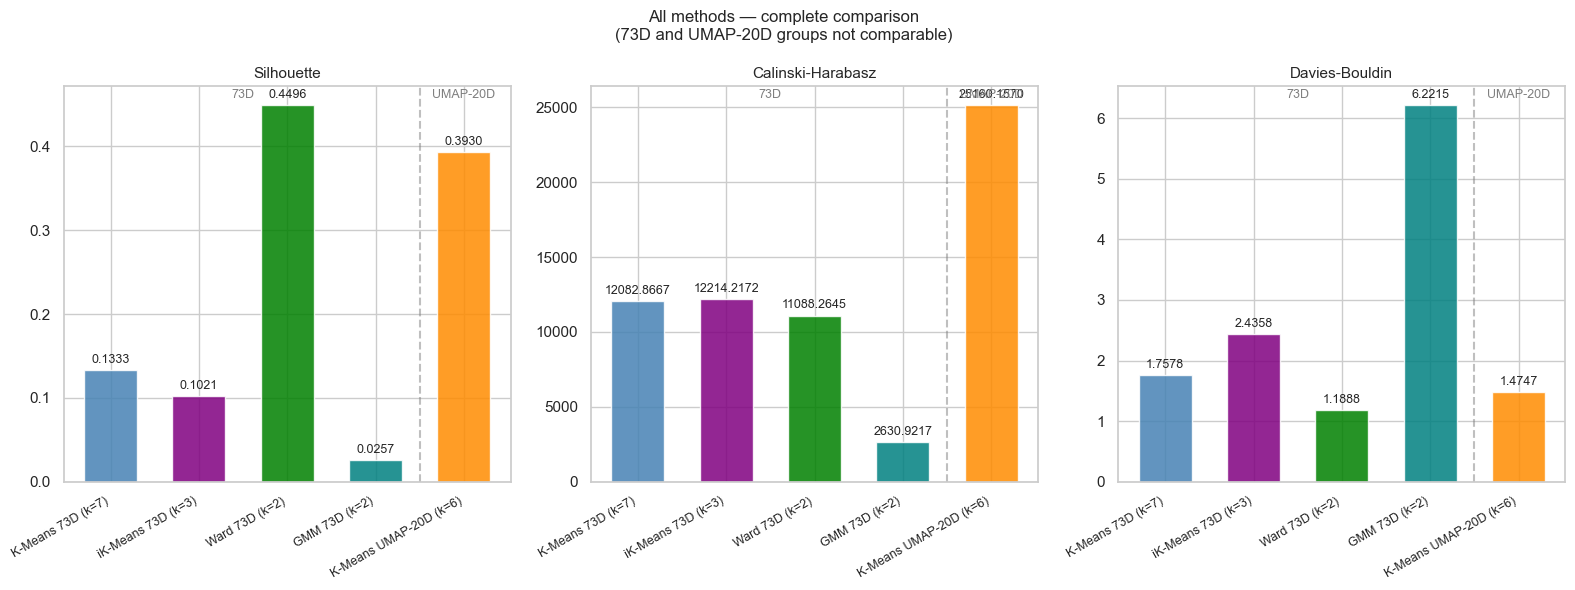

In [52]:
# Complete comparison — all methods and spaces
# NOTE: 73D and UMAP-20D metrics are NOT directly comparable (different geometry)
# Report them in separate groups
compare_full = pd.DataFrame([  # assemble all-method comparison: one row per method
    {'method': f'K-Means 73D (k={BEST_K})',  # K-Means 73D row
     'space': '73D', 'k': BEST_K,
     'silhouette': sil_km_val,
     'calinski_harabasz': ch_km_val,
     'davies_bouldin': db_km_val},
    {'method': f'iK-Means 73D (k={k_ikm})',  # iK-Means 73D row
     'space': '73D', 'k': k_ikm,
     'silhouette': sil_ikm,
     'calinski_harabasz': ch_ikm,
     'davies_bouldin': db_ikm},
    {'method': f'Ward 73D (k={BEST_K_HIER})',  # Ward 73D row
     'space': '73D', 'k': BEST_K_HIER,
     'silhouette': sil_hier,
     'calinski_harabasz': ch_hier,
     'davies_bouldin': db_hier},
    {'method': f'GMM 73D (k={BEST_K_GMM})',  # GMM 73D row
     'space': '73D', 'k': BEST_K_GMM,
     'silhouette': sil_gmm,
     'calinski_harabasz': ch_gmm,
     'davies_bouldin': db_gmm},
    {'method': f'K-Means UMAP-20D (k={BEST_K_UMAP})',  # K-Means UMAP-20D row — different geometric space
     'space': 'UMAP-20D', 'k': BEST_K_UMAP,
     'silhouette': sil_umap_final,
     'calinski_harabasz': ch_umap_final,
     'davies_bouldin': db_umap_final},
])  # close DataFrame constructor list
display(compare_full.round(4))  # render table in notebook output
compare_full.to_csv('tables/all_methods_full_comparison.csv', index=False)  # save full comparison table

#73D and UMAP-20D metrics are NOT comparable — different geometric spaces
#Compare within each group only
print(f'\n  ARI(K-Means 73D vs K-Means UMAP-20D) = {ari_73d_umap:.4f}')  # print ARI between 73D and UMAP-20D partitions
#if ari_73d_umap < 0.5-Partitions differ substantially: UMAP reveals different structure than 73D
# if ari_73d_umap < 0.8-Moderate overlap- UMAP captures similar but not identical structure to 73D
# if higher than 0.8 we have High overlap- UMAP-20D confirms the 73D partition with better geometry

colors_73d = ['steelblue', 'purple', 'green', 'teal']  # 73D method colours for bar chart
colors_umap = ['darkorange']  # UMAP-20D method colour
colors_all = colors_73d + colors_umap  # combined colour list matching row order in compare_full

fig, axes = plt.subplots(1, 3, figsize=(16, 6))  # three-panel bar chart: Silhouette, CH, DB
for ax, (col, title) in zip(axes, [  # loop: one panel per metric
    ('silhouette', 'Silhouette'),  # Silhouette panel
    ('calinski_harabasz', 'Calinski-Harabasz'),  # Calinski-Harabász panel
    ('davies_bouldin', 'Davies-Bouldin')]):  # close DataFrame constructor list
    bars = ax.bar(range(len(compare_full)), compare_full[col],  # draw bars coloured by method group
                  color=colors_all, alpha=0.85, width=0.6)  # bar colour list matches method group order
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)  # add numeric label above each bar
    ax.set_title(title, fontsize=11)  # set panel title
    ax.set_xticks(range(len(compare_full)))  # set tick positions
    ax.set_xticklabels(compare_full.method, rotation=30, ha='right', fontsize=9)  # set method name tick labels rotated for readability
    ax.axvline(3.5, ls='--', color='grey', alpha=0.5)  # vertical dashed line separating 73D and UMAP-20D groups
    # Labels after bars are drawn so ylim is set
    ymax = ax.get_ylim()[1]  # get current y-axis max for annotation positioning
    ax.text(1.5, ymax * 0.97, '73D',      ha='center', fontsize=9, color='grey')  # annotate '73D' group above bars
    ax.text(4.0, ymax * 0.97, 'UMAP-20D', ha='center', fontsize=9, color='grey')  # annotate 'UMAP-20D' group above bars

plt.suptitle('All methods — complete comparison\n'  # overall figure title
             '(73D and UMAP-20D groups not comparable)', fontsize=12) # dimension not comparable
plt.tight_layout()  # prevent subplot overlap
plt.savefig('figures/all_methods_full_comparison.png', dpi=120, bbox_inches='tight')  # save figure to disk
plt.show()  # render figure inline

In [53]:
# t-SNE perplexity sensitivity — T11 slide 12
# "Run several perplexities and trust only patterns that are stable"
print('t-SNE perplexity sensitivity:')  # section header for perplexity sensitivity sweep
tsne_sens_rows = []  # collect perplexity sensitivity results
for perp in [10, 20, 40, 80]:  # test 4 perplexity values; perplexity ~ number of effective nearest neighbours
    t_s = TSNE(n_components=2, perplexity=perp, init='pca',  # PCA init is more stable than random
                 learning_rate='auto', max_iter=500,  # 500 iterations is sufficient for sensitivity check
                 random_state=GLOBAL_SEED, n_jobs=1)  # fixed seed; n_jobs=1 for determinism
    X2d_p = t_s.fit_transform(X_tsne_in)  # 2D projection at this perplexity
    tw_p = trustworthiness(X_tsne_in, X2d_p, n_neighbors=10)  # trustworthiness: fraction of 10-NN preserved
    tsne_sens_rows.append({'perplexity': perp,  # store perplexity sensitivity result
                            'trustworthiness_k10': round(tw_p, 4)})
    print(f' perplexity={perp}  trustworthiness={tw_p:.4f}')  # print trustworthiness for this perplexity

df_tsne_sens = pd.DataFrame(tsne_sens_rows)  # assemble perplexity sensitivity table
display(df_tsne_sens)  # render table in notebook output
df_tsne_sens.to_csv('tables/tsne_sensitivity_perplexity.csv', index=False)  # save to tables/ for report

tw_max   = df_tsne_sens['trustworthiness_k10'].max()
tw_min   = df_tsne_sens['trustworthiness_k10'].min()
tw_range = tw_max - tw_min
print(f'\nTrustworthiness range: {tw_range:.4f}')

#if tw_range < 0.01Stable across perplexities — visual patterns are trustworthy
#if not we have Some sensitivity — trust only patterns consistent across all values
#t-SNE/UMAP axes have no quantitative meaning (T11 slide 16)
# important caveat for interpretation
#cluster distances and sizes in 2D are NOT meaningful.')
# 2D distances are distorted
#clusters are formed in UMAP-20D space, not in this 2D map
#clusters computed in 20D, visualised in 2D


t-SNE perplexity sensitivity:
 perplexity=10  trustworthiness=0.9966
 perplexity=20  trustworthiness=0.9975
 perplexity=40  trustworthiness=0.9965
 perplexity=80  trustworthiness=0.9947


,perplexity,trustworthiness_k10
0,10,0.9966
1,20,0.9975
2,40,0.9965
3,80,0.9947



Trustworthiness range: 0.0028


## 12. Experiment Log & Reproducibility Artefacts

In [54]:
RUN_TS   = datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S')  # ISO timestamp for this run
exp_rows = []  # list to collect one dict per experiment run

# K-Means k-sweep
for r in results_km:  # one row per k in K-Means sweep
    exp_rows.append({'run_id': f'km-sweep-k{r["k"]}', 'date': RUN_TS, 'method': 'KMeans',  # K-Means sweep row: all metrics and metadata
        'representation_id': 'R0-standard', 'parameters': f'k={r["k"]}, init=k-means++, n_init=10',
        'sample_rule': 'full dataset', 'k': r['k'], 'seed': GLOBAL_SEED,
        'silhouette': round(r['silhouette'],4), 'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4), 'inertia': round(r['inertia'],1),
        'runtime_s': round(r['runtime_s'],2), 'diagnostics': 'converged', 'notes': 'KMeans k-sweep'})

# iK-Means — k_ikm is the authoritative value from seed=42
exp_rows.append({'run_id': 'ikmeans-auto', 'date': RUN_TS, 'method': 'iKMeans',  # iK-Means canonical run row
    'representation_id': 'R0-standard', 'parameters': f'min_cluster_size={MIN_CLUSTER_SIZE}',
    'sample_rule': f'subsample={SUBSAMPLE_IKM}', 'k': k_ikm, 'seed': GLOBAL_SEED,
    'silhouette': round(sil_ikm,4), 'calinski_harabasz': round(ch_ikm,2),
    'davies_bouldin': round(db_ikm,4), 'inertia': None, 'runtime_s': round(ikm_rt,2),
    'diagnostics': f'{k_ikm} anomalous clusters extracted (seed={GLOBAL_SEED})',
    'notes': f'iKMeans auto-k={k_ikm}. Stability: k varies across seeds (see ikm_stab table).'})

# iK-Means stability per seed
for r in ikm_stab_rows:  # one row per seed in iK-Means stability sweep
    exp_rows.append({'run_id': f'ikmeans-stab-seed{r["seed"]}', 'date': RUN_TS,  # iK-Means stability row for this seed
        'method': 'iKMeans-stability', 'representation_id': 'R0-standard',
        'parameters': f'min_cluster_size={MIN_CLUSTER_SIZE}',
        'sample_rule': f'subsample={SUBSAMPLE_IKM}', 'k': r['k'], 'seed': r['seed'],
        'silhouette': round(r['silhouette'],4), 'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4), 'inertia': None, 'runtime_s': None,
        'diagnostics': f'k={r["k"]} extracted', 'notes': 'iKMeans seed stability'})

# KMeans stability
for r in km_stab_rows:  # one row per seed in K-Means stability sweep
    exp_rows.append({'run_id': f'km-stab-seed{r["seed"]}', 'date': RUN_TS,  # K-Means stability row for this seed
        'method': 'KMeans-stability', 'representation_id': 'R0-standard',
        'parameters': f'k={BEST_K}, n_init=10', 'sample_rule': 'full dataset',
        'k': BEST_K, 'seed': r['seed'], 'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2), 'davies_bouldin': round(r['davies_bouldin'],4),
        'inertia': None, 'runtime_s': None, 'diagnostics': 'seed stability', 'notes': 'KMeans stability'})

# Scaler sensitivity
for r in sens_rows:  # one row per representation in scaler sensitivity sweep
    exp_rows.append({'run_id': f'km-sens-{r["representation_id"]}', 'date': RUN_TS,  # Scaler sensitivity row
        'method': 'KMeans-sensitivity', 'representation_id': r['representation_id'],
        'parameters': f'k={BEST_K}, scaler={r["scaler"]}', 'sample_rule': 'full dataset',
        'k': BEST_K, 'seed': GLOBAL_SEED, 'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2), 'davies_bouldin': round(r['davies_bouldin'],4),
        'inertia': None, 'runtime_s': None, 'diagnostics': f'ARI_R0_R1={ari_scale:.4f}',
        'notes': f'Scaler sensitivity. ARI={ari_scale:.4f} — LIMITATION if < 0.5'})

# Ward
exp_rows.append({'run_id': f'ward-k{BEST_K_HIER}', 'date': RUN_TS, 'method': 'Ward',  # Ward final model row
    'representation_id': 'R0-standard', 'parameters': f'k={BEST_K_HIER}, linkage=ward',
    'sample_rule': f'subsample={SUBSAMPLE_HIER}', 'k': BEST_K_HIER, 'seed': GLOBAL_SEED,
    'silhouette': round(sil_hier,4), 'calinski_harabasz': round(ch_hier,2),
    'davies_bouldin': round(db_hier,4), 'inertia': None, 'runtime_s': None,
    'diagnostics': f'ARI_vs_KMeans={ari_km_hier:.4f}, dendrogram_k={k_dend}',
    'notes': 'Ward hierarchical Task 2. Dendrogram and Silhouette may disagree.'})

# GMM
for r in gmm_sweep_rows:  # one row per k in GMM sweep
    exp_rows.append({'run_id': f'gmm-sweep-k{int(r["k"])}', 'date': RUN_TS,  # GMM sweep row for this k
        'method': 'GMM-sweep', 'representation_id': 'R0-standard',
        'parameters': f'k={int(r["k"])}, covariance_type=full, n_init=5',
        'sample_rule': f'subsample={GMM_SWEEP_N}', 'k': int(r['k']), 'seed': GLOBAL_SEED,
        'silhouette': round(r['silhouette'],4), 'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4), 'inertia': None,
        'runtime_s': round(r['runtime_s'],2),
        'diagnostics': f'converged={r["converged"]}, bic={r["bic"]:.1f}',
        'notes': f'GMM k-sweep. Best BIC k={BEST_K_GMM_BIC}, best Sil k={BEST_K_GMM}'})

for r in gmm_stab_rows:  # one row per seed in GMM stability sweep
    exp_rows.append({'run_id': f'gmm-stab-seed{r["seed"]}', 'date': RUN_TS,  # GMM stability row for this seed
        'method': 'GMM-stability', 'representation_id': 'R0-standard',
        'parameters': f'k={BEST_K_GMM}, covariance_type=full, n_init=5',
        'sample_rule': 'full dataset', 'k': BEST_K_GMM, 'seed': r['seed'],
        'silhouette': round(r['silhouette'],4), 'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4), 'inertia': None,
        'runtime_s': None, 'diagnostics': 'seed stability', 'notes': 'GMM stability'})

# Spectral
exp_rows.append({'run_id': f'spectral-knn{N_KNN}', 'date': RUN_TS, 'method': 'SpectralClustering',  # Spectral clustering row
    'representation_id': 'R0-standard',
    'parameters': f'k={K_SPEC}, n_neighbors={N_KNN}, laplacian=normalised',
    'sample_rule': f'subsample={SUBSAMPLE_SPEC}', 'k': K_SPEC, 'seed': GLOBAL_SEED,
    'silhouette': round(sil_spec,4), 'calinski_harabasz': round(ch_spec,2),
    'davies_bouldin': round(db_spec,4), 'inertia': None, 'runtime_s': round(spec_rt,2),
    'diagnostics': f'eigengap_k={k_eigengap}, used_k={K_SPEC}, sigma={sigma_spec:.4f}',
    'notes': f'ARI_vs_KMeans={ari_km_spec:.4f}. Eigengap suggests k={k_eigengap}.'})

# UMAP K-Means
exp_rows.append({'run_id': f'km-umap20d-k{BEST_K_UMAP}', 'date': RUN_TS,
    'method': 'KMeans-UMAP20D', 'representation_id': 'R0-UMAP20D',
    'parameters': f'k={BEST_K_UMAP}, umap_n_neighbors=30, n_components=20',
    'sample_rule': 'full dataset', 'k': BEST_K_UMAP, 'seed': GLOBAL_SEED,
    'silhouette': round(sil_umap_final,4), 'calinski_harabasz': round(ch_umap_final,2),
    'davies_bouldin': round(db_umap_final,4), 'inertia': None, 'runtime_s': round(umap20_rt,2),
    'diagnostics': f'ARI_vs_73D={ari_73d_umap:.4f}, tw_umap20={tw_umap20:.4f}',
    'notes': 'UMAP-20D preprocessing. Silhouette NOT comparable to 73D.'})

df_exp = pd.DataFrame(exp_rows)
df_exp.to_csv('experiments.csv', index=False)
print(f'Saved {len(df_exp)} rows to experiments.csv')
display(df_exp[['run_id','method','representation_id','k','seed','silhouette','notes']].tail(15))


Saved 53 rows to experiments.csv


,run_id,method,representation_id,k,seed,silhouette,notes
38,gmm-sweep-k7,GMM-sweep,R0-standard,7,42,-0.0203,"GMM k-sweep. Best BIC k=8, best Sil k=2"
39,gmm-sweep-k8,GMM-sweep,R0-standard,8,42,0.0165,"GMM k-sweep. Best BIC k=8, best Sil k=2"
40,gmm-stab-seed42,GMM-stability,R0-standard,2,42,0.0257,GMM stability
41,gmm-stab-seed7,GMM-stability,R0-standard,2,7,0.1949,GMM stability
42,gmm-stab-seed13,GMM-stability,R0-standard,2,13,0.2031,GMM stability
43,gmm-stab-seed99,GMM-stability,R0-standard,2,99,0.0267,GMM stability
44,gmm-stab-seed2025,GMM-stability,R0-standard,2,2025,0.0217,GMM stability
45,gmm-stab-seed2024,GMM-stability,R0-standard,2,2024,0.2275,GMM stability
46,gmm-stab-seed2004,GMM-stability,R0-standard,2,2004,0.0276,GMM stability
47,gmm-stab-seed2005,GMM-stability,R0-standard,2,2005,0.0281,GMM stability


In [55]:
env_yml = """name: hotel-clustering
channels:
  - defaults
  - conda-forge
dependencies:
  - python=3.10
  - numpy>=1.24
  - pandas>=1.5
  - scikit-learn>=1.3
  - scipy>=1.10
  - matplotlib>=3.7
  - seaborn>=0.12
  - umap-learn>=0.5
  - jupyter
"""

run_all_py = "\n".join([
    "#!/usr/bin/env python",
    "import subprocess, os, sys",
    "data_path = os.environ.get('HOTEL_DATA_PATH',",
    "            '/content/hotel_bookings_course_release_v1.csv')",
    "if not os.path.exists(data_path):",
    "    print(f'ERROR: Dataset not found at {data_path}')",
    "    sys.exit(1)",
    "cmd = [",
    "    'jupyter', 'nbconvert', '--to', 'notebook', '--execute',",
    "    '--ExecutePreprocessor.timeout=10800',",
    "    'hotel_clustering_final.ipynb',",
    "    '--output', 'hotel_clustering_final_executed.ipynb'",
    "]",
    "subprocess.run(cmd, check=True)",
    "print('Done — see hotel_clustering_final_executed.ipynb')",
]) + "\n"

with open('environment.yml', 'w') as f:
    f.write(env_yml)
with open('run_all.py', 'w') as f:
    f.write(run_all_py)
print('environment.yml and run_all.py written ✓')

environment.yml and run_all.py written ✓


In [56]:
n_figs   = len(list(Path('figures').glob('*.png')))
n_tables = len(list(Path('tables').glob('*.csv')))

print("PROJECT SUMMARY")
print(f"Task 1 — K-Means:k={BEST_K}  Sil={sil_km_val:.4f}  ARI_stab={np.mean(ari_km):.4f}")
print(f"Task 1 — iK-Means: k={k_ikm}  Sil={sil_ikm:.4f}  ARI_stab={np.mean(ari_ikm):.4f} (LIMITATION: k varies)")
print(f"Task 2 — Ward: k={BEST_K_HIER}  Sil={sil_hier:.4f}  ARI_vs_KM={ari_km_hier:.4f} (dend suggests k={k_dend})")
print(f"Task 2 — GMM 73D: k={BEST_K_GMM}  Sil={sil_gmm:.4f}  ARI_stab={np.mean(ari_gmm):.4f}")
print(f"Sensitivity — ARI(R0 vs R1): {ari_scale:.4f}  {'LIMITATION' if ari_scale < 0.5 else 'moderate' if ari_scale < 0.8 else 'robust'}")
print(f"Ext. A — Anomaly: top-{TOP_K_ANOM} identified, overlap R0/R1={overlap}/{TOP_K_ANOM}")
print(f"Ext. B — Spectral: k={K_SPEC} (eigengap)  Sil={sil_spec:.4f}  ARI_vs_KM={ari_km_spec:.4f}")
print(f"Ext. C — KMeans UMAP-20D: k={BEST_K_UMAP}  Sil(UMAP)={sil_umap_final:.4f}  ARI_vs_73D={ari_73d_umap:.4f}")
print(f"Ext. C — UMAP-20D tw: {tw_umap20:.4f}  t-SNE tw={tw:.4f}  PCA baseline={tw_pca:.4f}")
print(f"Experiment log: {len(df_exp)} rows in experiments.csv")



PROJECT SUMMARY
Task 1 — K-Means:k=7  Sil=0.1333  ARI_stab=0.8229
Task 1 — iK-Means: k=3  Sil=0.1021  ARI_stab=0.5733 (LIMITATION: k varies)
Task 2 — Ward: k=2  Sil=0.4496  ARI_vs_KM=0.0222 (dend suggests k=6)
Task 2 — GMM 73D: k=2  Sil=0.0257  ARI_stab=0.4210
Sensitivity — ARI(R0 vs R1): 0.2835  LIMITATION
Ext. A — Anomaly: top-20 identified, overlap R0/R1=0/20
Ext. B — Spectral: k=4 (eigengap)  Sil=0.0495  ARI_vs_KM=0.0604
Ext. C — KMeans UMAP-20D: k=6  Sil(UMAP)=0.3930  ARI_vs_73D=0.1219
Ext. C — UMAP-20D tw: 0.9482  t-SNE tw=0.9981  PCA baseline=0.9482
Experiment log: 53 rows in experiments.csv
